<div style="text-align:center;">
  <span style="color:Green; font-size:30px; font-weight:bold;">
    Bad Debt Prediction
  </span>
</div>

**This notebook includes Exploratory Data Analysis (EDA), model training, and model evaluation to assess model performance.**

**Importing all libraries**

In [2]:
#----------------------------------------------------
# Importing Libraries
#----------------------------------------------------

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.under_sampling import RandomUnderSampler 
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
warnings.filterwarnings('ignore')
warnings.filterwarnings('default')

#----------------------------------------------------
# MLflow setup
#----------------------------------------------------

# import mlflow
# import mlflow.sklearn
# import mlflow.xgboost
# import mlflow.catboost

#mlflow.set_tracking_uri("http://127.0.0.1:5000")
#mlflow.set_experiment("Bad Debt Prediction")

#----------------------------------------------------
# MLflow setup on AWS EC2
#----------------------------------------------------


 #mlflow.set_tracking_uri("http://34.228.200.20:5000")   # EC2 IP
 #mlflow.set_experiment("Bad Debt Prediction EC2")

#----------------------------------------------------
# Pandas and Numpy display options
#----------------------------------------------------

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))
np.set_printoptions(suppress=True)

### **Data Loading After Dataset Cleaning and Merging**

In [3]:
df = pd.read_csv("credit_risk_master_table_2.csv")
df.tail()

,OUTCOME,Customer,LICENCE_AVAILABLE,RESIDENTIAL,CD_OCCUPATION,CD_STS_RESIDENTIAL,HAD_SERVICES,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,...,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,DEFAULT_CNT_CR21,DEFAULT_OPEN_CNT_CR21,DEFAULT_UNPAID_AMT_CR21,DEFAULT_CNT_3M_CR21,DEFAULT_CNT_6M_CR21,DEFAULT_CNT_12M_CR21
91844,Good,2999821794,yes,Owned,retired,O,1.00,AU Driver Licence,Resident,retired,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
91845,Good,2811821694,yes,Rented,employed,R,1.00,AU Driver Licence,Resident,employed,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
91846,Good,2971478930,Missing,Owned,self_employed,O,1.00,AU Passport,Resident,self_employed,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
91847,Bad,2974937898,yes,Rented,unemployed,R,1.00,AU Driver Licence,Resident,unemployed,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
91848,Good,2977362690,yes,Owned,self_employed,O,1.00,AU Driver Licence,Resident,self_employed,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [5]:
df[["SCORE_CR22", "RISK_SCORE"]].describe()

,SCORE_CR22,RISK_SCORE
count,83851.00,91849.00
mean,591.28,721.31
std,189.68,180.84
min,-204.00,-125.00
25%,457.00,614.00
50%,558.00,660.00
75%,733.00,848.00
max,1203.00,1157.00


In [ ]:
df.shape

(91849, 89)

In [ ]:
df = df[df['OUTCOME'] != 'Rejected - Policy Decline'].copy()


In [ ]:
df['OUTCOME'].isna().sum()

0

In [ ]:
df['OUTCOME'].unique()

array(['Good', 'Bad'], dtype=object)

In [ ]:
df.columns

Index(['OUTCOME', 'Customer', 'LICENCE_AVAILABLE', 'RESIDENTIAL',
       'CD_OCCUPATION', 'CD_STS_RESIDENTIAL', 'HAD_SERVICES', 'DOC_TYPE',
       'VISA_TYPE', 'EMPLOYED_STATUS', 'EMPLOYED_TYPE', 'EMPLOYED_NO_MTHS',
       'NO_ADDRESS_AT_MONTHS', 'APPLICANT_AGE', 'APPLICANT_AGE_AVG',
       'RISK_SCORE', 'BUREAU_DEFAULT', 'DEFAULT_AMT', 'DEFAULTS_12M',
       'DEROGATORIES', 'NO_SCORE', 'SCORECARD', 'SCORE_CR22',
       'SCORE_BAND_CR22', 'SCORECARD_CR21', 'RISK_RELATIVE_CR21',
       'RISK_RELATIVE_ODDS_CR21', 'Late_Payment_30DPD_Last_12M',
       'Credit_Card_Payment_Failure_Count',
       'Personal_Loan_Payment_Failure_Count',
       'Recent_Payment_Irregularity_Flag', 'Late_Payment_30DPD_Last_24M',
       'Cumulative_Delinquency_Exposure',
       'Long_Term_Payment_Delinquency_Count', 'BUREAU_ENQUIRIES_12_MONTHS',
       'ENQUIRIES_6M', 'ENQUIRIES_12M', 'ENQUIRY_CNT_CR22',
       'ENQUIRY_CNT_1M_CR22', 'ENQUIRY_CNT_3M_CR22', 'ENQUIRY_CNT_6M_CR22',
       'ENQUIRY_CNT_12M_CR22', 'EN

In [ ]:
Outcome_mapping = {
    'Good': 0,
    'Bad': 1
    
}

df['OUTCOME'] = df['OUTCOME'].map(Outcome_mapping)
df['OUTCOME'].value_counts()

OUTCOME
0    84341
1     7481
Name: count, dtype: int64

In [ ]:
df = df.drop(columns=['APPLICANT_AGE_AVG'])

In [ ]:
df.isna().sum()

OUTCOME                                   0
Customer                                  0
LICENCE_AVAILABLE                         0
RESIDENTIAL                               0
CD_OCCUPATION                             0
CD_STS_RESIDENTIAL                        0
HAD_SERVICES                           7425
DOC_TYPE                                  0
VISA_TYPE                                 0
EMPLOYED_STATUS                           0
EMPLOYED_TYPE                             0
EMPLOYED_NO_MTHS                          0
NO_ADDRESS_AT_MONTHS                   7425
APPLICANT_AGE                             0
RISK_SCORE                                0
BUREAU_DEFAULT                            0
DEFAULT_AMT                               0
DEFAULTS_12M                              0
DEROGATORIES                              0
NO_SCORE                                  0
SCORECARD                                 0
SCORE_CR22                             7998
SCORE_BAND_CR22                 

In [ ]:
df.columns

Index(['OUTCOME', 'Customer', 'LICENCE_AVAILABLE', 'RESIDENTIAL',
       'CD_OCCUPATION', 'CD_STS_RESIDENTIAL', 'HAD_SERVICES', 'DOC_TYPE',
       'VISA_TYPE', 'EMPLOYED_STATUS', 'EMPLOYED_TYPE', 'EMPLOYED_NO_MTHS',
       'NO_ADDRESS_AT_MONTHS', 'APPLICANT_AGE', 'RISK_SCORE', 'BUREAU_DEFAULT',
       'DEFAULT_AMT', 'DEFAULTS_12M', 'DEROGATORIES', 'NO_SCORE', 'SCORECARD',
       'SCORE_CR22', 'SCORE_BAND_CR22', 'SCORECARD_CR21', 'RISK_RELATIVE_CR21',
       'RISK_RELATIVE_ODDS_CR21', 'Late_Payment_30DPD_Last_12M',
       'Credit_Card_Payment_Failure_Count',
       'Personal_Loan_Payment_Failure_Count',
       'Recent_Payment_Irregularity_Flag', 'Late_Payment_30DPD_Last_24M',
       'Cumulative_Delinquency_Exposure',
       'Long_Term_Payment_Delinquency_Count', 'BUREAU_ENQUIRIES_12_MONTHS',
       'ENQUIRIES_6M', 'ENQUIRIES_12M', 'ENQUIRY_CNT_CR22',
       'ENQUIRY_CNT_1M_CR22', 'ENQUIRY_CNT_3M_CR22', 'ENQUIRY_CNT_6M_CR22',
       'ENQUIRY_CNT_12M_CR22', 'ENQUIRY_CNT_CR21', 'ENQUIRY_CN

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
df['SCORE_CR22'].isna().sum()


7998

In [ ]:
df.isna().sum().sort_values(ascending=False)

SCORE_CR22                             7998
CREDIT_CARD_CR21                       7425
MORTGAGE_CR21                          7425
CLOSED_ACCT_CR21                       7425
OPEN_ACCT_CR21                         7425
AUTO_LOAN_AMT_CR22                     7425
PERSONAL_LOAN_AMT_CR22                 7425
OVERDRAFT_AMT_CR22                     7425
CREDIT_CARD_AMT_CR22                   7425
AUTO_LOAN_CR22                         7425
PERSONAL_LOAN_CR22                     7425
ENQUIRY_CNT_6M_CR21                    7425
UTILITIES_CR22                         7425
TELCO_CR22                             7425
CREDIT_CARD_CR22                       7425
MORTGAGE_CR22                          7425
CLOSED_ACCT_CR22                       7425
OPEN_ACCT_CR22                         7425
ENQUIRY_MAX_AMT_12M                    7425
ENQUIRY_MAX_AMT_6M                     7425
ENQUIRY_MAX_AMT_3M                     7425
OVERDRAFT_CR22                         7425
TELCO_CR21                      

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91822 entries, 0 to 91848
Data columns (total 88 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   OUTCOME                              91822 non-null  int64  
 1   Customer                             91822 non-null  int64  
 2   LICENCE_AVAILABLE                    91822 non-null  object 
 3   RESIDENTIAL                          91822 non-null  object 
 4   CD_OCCUPATION                        91822 non-null  object 
 5   CD_STS_RESIDENTIAL                   91822 non-null  object 
 6   HAD_SERVICES                         84397 non-null  float64
 7   DOC_TYPE                             91822 non-null  object 
 8   VISA_TYPE                            91822 non-null  object 
 9   EMPLOYED_STATUS                      91822 non-null  object 
 10  EMPLOYED_TYPE                        91822 non-null  object 
 11  EMPLOYED_NO_MTHS                 

In [ ]:
df.isna().sum().sort_values(ascending=False)

SCORE_CR22                             7998
CREDIT_CARD_CR21                       7425
MORTGAGE_CR21                          7425
CLOSED_ACCT_CR21                       7425
OPEN_ACCT_CR21                         7425
AUTO_LOAN_AMT_CR22                     7425
PERSONAL_LOAN_AMT_CR22                 7425
OVERDRAFT_AMT_CR22                     7425
CREDIT_CARD_AMT_CR22                   7425
AUTO_LOAN_CR22                         7425
PERSONAL_LOAN_CR22                     7425
ENQUIRY_CNT_6M_CR21                    7425
UTILITIES_CR22                         7425
TELCO_CR22                             7425
CREDIT_CARD_CR22                       7425
MORTGAGE_CR22                          7425
CLOSED_ACCT_CR22                       7425
OPEN_ACCT_CR22                         7425
ENQUIRY_MAX_AMT_12M                    7425
ENQUIRY_MAX_AMT_6M                     7425
ENQUIRY_MAX_AMT_3M                     7425
OVERDRAFT_CR22                         7425
TELCO_CR21                      

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(col, "-->", df[col].unique())

LICENCE_AVAILABLE --> ['Missing' 'yes' 'no']
RESIDENTIAL --> ['Rented' 'Owned' 'Living_With_Family' 'Missing']
CD_OCCUPATION --> ['employed' 'unemployed' 'student' 'retired' 'self_employed' 'Missing'
 'benefits' 'unwilling to supply' 'superannuation' 'home_excecutive']
CD_STS_RESIDENTIAL --> ['R' 'O' 'B' 'Missing' 'L' 'W' 'Z']
DOC_TYPE --> ['Intl Passport and Visa' 'AU Driver Licence' 'AU Passport' 'Missing'
 'HAAU 18+ Card' 'Australian Passport' 'Fire Arms Licence'
 'Defence Force ID(picture card)' 'AU Birth Certificate']
VISA_TYPE --> ['Work Visa' 'Resident' 'Student' 'Missing']
EMPLOYED_STATUS --> ['employed' 'unemployed' 'student' 'Missing' 'retired' 'benefits'
 'unwilling to supply' 'self_employed' 'superannuation' 'home_excecutive']
EMPLOYED_TYPE --> ['Missing' 'unemployed' 'student' 'self_employed' 'home_excecutive']
APPLICANT_AGE --> ['30-34' '35-44' '25 - 29' '18-24' '54+' '45-54']
BUREAU_DEFAULT --> ['Missing' '1-1000' '1000+']
SCORECARD --> ['TAR1A' 'SFJR1A' 'HSHSOL' 'CTSDP'

In [ ]:
for col in df.select_dtypes(include=['int64', 'float64',"Int16"]).columns:
    print(col, "-->", df[col].unique())

OUTCOME --> [0 1]
Customer --> [2975536526 2999806086 2800835182 ... 2971478930 2974937898 2977362690]
HAD_SERVICES --> [ 1. nan  0.]
EMPLOYED_NO_MTHS --> [  1.  86.  61.  15.   0.   6.  12.   7.   5.  28. 120.  24.  49.  65.
  13.  14.  38.  20.  36.   4.   3.  48.   8.  30.  18.  17.   2.  33.
 250.  77.  32. 125. 108.  60.  37.  96.  25.   9.  11.  84. 111.  90.
  51.  23.  88. 130. 106.  63.  41.  40.  52.  45.  27. 131.  72.  39.
  31.  53.  10.  42.  16.  46.  34.  50.  76.  62.  21.  29. 170. 136.
  92.  67.  54. 195.  97. 137.  22.  26. 219. 194. 121.  47.  56.  44.
 101.  91.  98.  35.  74. 103.  66. 135.  64.  78. 206.  99.  19. 122.
 156. 266. 192. 305.  73. 127. 119.  82. 232.  69. 240.  81.  95.  89.
 104. 129.  80. 238.  68. 124.  75. 244. 187. 126.  94. 225.  85. 102.
 123.  43. 233.  57. 114. 193.  59. 216. 245. 155. 142.  55. 202. 110.
 133. 100. 107. 118. 117. 442.  83. 105. 191. 109. 228. 183. 361. 161.
 160. 145. 222. 220. 113.  87. 140.  79. 149. 146. 168. 132. 274

In [ ]:
len(df.columns)

88

In [ ]:
# Numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: ['OUTCOME', 'Customer', 'HAD_SERVICES', 'EMPLOYED_NO_MTHS', 'NO_ADDRESS_AT_MONTHS', 'RISK_SCORE', 'DEFAULT_AMT', 'DEFAULTS_12M', 'DEROGATORIES', 'NO_SCORE', 'SCORE_CR22', 'RISK_RELATIVE_CR21', 'RISK_RELATIVE_ODDS_CR21', 'Late_Payment_30DPD_Last_12M', 'Credit_Card_Payment_Failure_Count', 'Personal_Loan_Payment_Failure_Count', 'Recent_Payment_Irregularity_Flag', 'Late_Payment_30DPD_Last_24M', 'Cumulative_Delinquency_Exposure', 'Long_Term_Payment_Delinquency_Count', 'ENQUIRIES_6M', 'ENQUIRIES_12M', 'ENQUIRY_CNT_CR22', 'ENQUIRY_CNT_1M_CR22', 'ENQUIRY_CNT_3M_CR22', 'ENQUIRY_CNT_6M_CR22', 'ENQUIRY_CNT_12M_CR22', 'ENQUIRY_CNT_CR21', 'ENQUIRY_CNT_1M_CR21', 'ENQUIRY_CNT_3M_CR21', 'ENQUIRY_CNT_6M_CR21', 'ENQUIRY_CNT_12M_CR21', 'ENQUIRY_MAX_AMT_1M', 'ENQUIRY_MAX_AMT_3M', 'ENQUIRY_MAX_AMT_6M', 'ENQUIRY_MAX_AMT_12M', 'OPEN_ACCT_CR22', 'CLOSED_ACCT_CR22', 'MORTGAGE_CR22', 'CREDIT_CARD_CR22', 'TELCO_CR22', 'UTILITIES_CR22', 'OVERDRAFT_CR22', 'PERSONAL_LOAN_CR22', 'AUTO_LOAN_CR22', 

In [ ]:
len(num_cols)

74

In [ ]:
len(cat_cols)

14

In [ ]:
df.value_counts( "OUTCOME")

OUTCOME
0    84341
1     7481
Name: count, dtype: int64

**Data Leakage:**
The target variable is highly imbalanced, with ~92% non-default (Good) accounts and only ~8% default (Bad) accounts. Such imbalance can bias the model toward the majority class, so techniques like class weighting and SMOTE-based resampling are applied to ensure the model learns meaningful patterns for both classes


**Train Test** : Performing train test split before doing EDA to prevent data leakage. I don't want test set (which is part of the entire dataset) to influence EDA or any decisions on feature engineering.

In [ ]:
X = df.drop("OUTCOME", axis="columns")
y = df['OUTCOME']

X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.25,random_state=42)

df_train = pd.concat([X_train, y_train], axis="columns")
df_test = pd.concat([X_test, y_test], axis="columns")

df_train.head(2)

,Customer,LICENCE_AVAILABLE,RESIDENTIAL,CD_OCCUPATION,CD_STS_RESIDENTIAL,HAD_SERVICES,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,APPLICANT_AGE,RISK_SCORE,BUREAU_DEFAULT,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,NO_SCORE,SCORECARD,SCORE_CR22,SCORE_BAND_CR22,SCORECARD_CR21,RISK_RELATIVE_CR21,RISK_RELATIVE_ODDS_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,BUREAU_ENQUIRIES_12_MONTHS,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_CNT_CR21,ENQUIRY_CNT_1M_CR21,ENQUIRY_CNT_3M_CR21,ENQUIRY_CNT_6M_CR21,ENQUIRY_CNT_12M_CR21,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,OPEN_ACCT_CR21,CLOSED_ACCT_CR21,MORTGAGE_CR21,CREDIT_CARD_CR21,TELCO_CR21,UTILITIES_CR21,OVERDRAFT_CR21,PERSONAL_LOAN_CR21,AUTO_LOAN_CR21,CREDIT_CARD_AMT_CR21,OVERDRAFT_AMT_CR21,PERSONAL_LOAN_AMT_CR21,AUTO_LOAN_AMT_CR21,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,DEFAULT_CNT_CR21,DEFAULT_OPEN_CNT_CR21,DEFAULT_UNPAID_AMT_CR21,DEFAULT_CNT_3M_CR21,DEFAULT_CNT_6M_CR21,DEFAULT_CNT_12M_CR21,OUTCOME
60323,2987665766,yes,Rented,employed,R,1.00,AU Driver Licence,Resident,employed,Missing,54.00,135.00,35-44,899,Missing,0,0,0,907,TAR1A,827.00,Low,CTS1A,32.49,134.36,0,0,-1,24,0,6500,24,1-2,2,2,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,2.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,6500.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0
66140,2976887250,Missing,Rented,student,R,1.00,Intl Passport and Visa,Student,student,student,0.00,1.00,25 - 29,611,Missing,0,0,0,783,TAR1A,650.00,Medium,CTS1A,13.75,56.89,0,-1,-1,0,0,0,0,1-2,2,2,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0


In [ ]:
print(df_train.shape)
print(df_test.shape)

(68866, 88)
(22956, 88)


In [ ]:
df_train.describe()

<div style="text-align:center;">
  <span style="color:Green; font-size:30px; font-weight:bold;">
    Exploratory Data Analysis
  </span>
</div>

**RISK_SCORE Distribution by Outcome**

C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\2194724312.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([good, bad], labels=["Good (0)", "Bad (1)"])


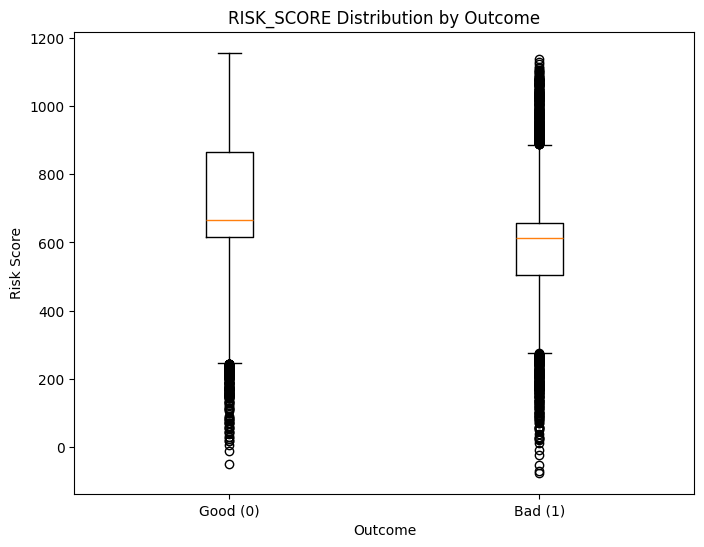

In [ ]:

# Separate by target
good = df_train[df_train["OUTCOME"] == 0]["RISK_SCORE"]
bad  = df_train[df_train["OUTCOME"] == 1]["RISK_SCORE"]

plt.figure(figsize=(8, 6))
plt.boxplot([good, bad], labels=["Good (0)", "Bad (1)"])
plt.title("RISK_SCORE Distribution by Outcome")
plt.ylabel("Risk Score")
plt.xlabel("Outcome")
plt.show()

- Good accounts show a higher median risk score, while bad accounts cluster at lower risk score values.

- There is clear distributional separation, indicating strong predictive power for default risk.

- Despite its strong predictive power, this feature is retained initially and excluded at a later stage after deeper analysis, as it represents a derived risk metric. Feature importance results, together with domain and business knowledge, indicate that it may introduce data leakage, leading to its eventual removal.

**NO_SCORE_CR21 Distribution by Outcome**

C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\2134246773.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([good, bad], labels=["Good (0)", "Bad (1)"])


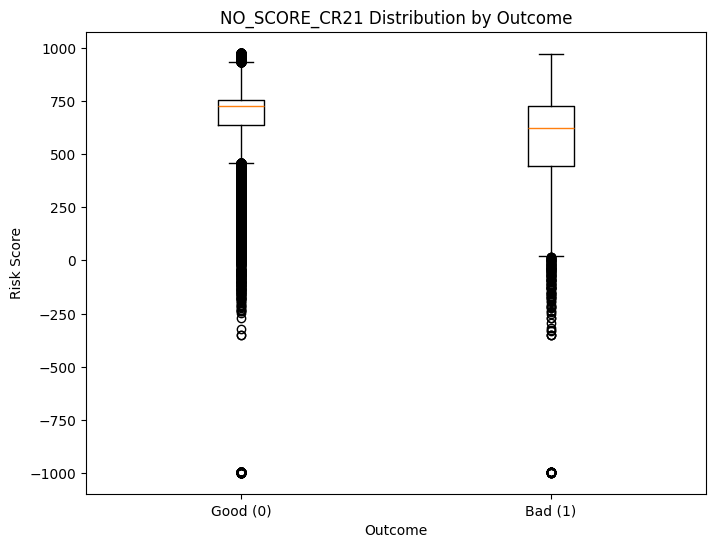

In [ ]:
# Separate by target
good = df_train[df_train["OUTCOME"] == 0]["NO_SCORE"]
bad  = df_train[df_train["OUTCOME"] == 1]["NO_SCORE"]

plt.figure(figsize=(8, 6))
plt.boxplot([good, bad], labels=["Good (0)", "Bad (1)"])
plt.title("NO_SCORE_CR21 Distribution by Outcome")
plt.ylabel("Risk Score")
plt.xlabel("Outcome")
plt.show()

* Exhibits **extreme negative and sentinel values**, indicating data quality issues rather than true credit behavior.
* Shows **high overlap between good and bad outcomes**, resulting in weak discriminatory power.
* **Excluded from modeling** due to noise, instability, and limited business relevance.

**SCORE_CR22 Distribution by Outcome**

57828 5046


C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\4139820385.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([good, bad], labels=["Good (0)", "Bad (1)"])


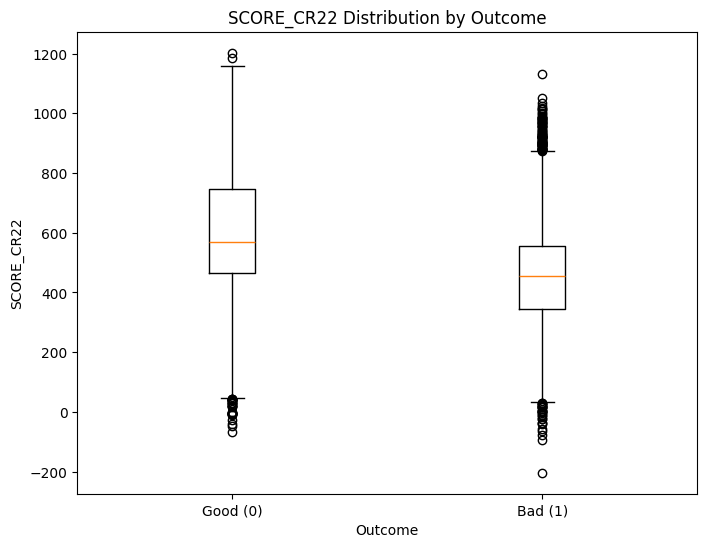

In [355]:
good = df_train.loc[df_train["OUTCOME"] == 0, "SCORE_CR22"].dropna()
bad  = df_train.loc[df_train["OUTCOME"] == 1, "SCORE_CR22"].dropna()

print(len(good), len(bad))  # sanity check

plt.figure(figsize=(8, 6))
plt.boxplot([good, bad], labels=["Good (0)", "Bad (1)"])
plt.title("SCORE_CR22 Distribution by Outcome")
plt.ylabel("SCORE_CR22")
plt.xlabel("Outcome")
plt.show()

* Good accounts have a **significantly higher median credit score**, while bad accounts concentrate at lower score ranges.
* The distribution shows **clear downward shift for bad outcomes**, indicating strong discriminatory power.
* **Retained as a key predictive feature** due to strong business relevance and alignment with credit risk theory.

In [356]:
amt_cols_cr22 = [
    'OPEN_ACCT_CR22', 'CLOSED_ACCT_CR22',
    'CREDIT_CARD_AMT_CR22'
    
   
]

amt_cols_cr21 = [
    'OPEN_ACCT_CR21', 'CLOSED_ACCT_CR21',
    'CREDIT_CARD_AMT_CR21'
    
   
]

C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\641384868.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([good, bad], labels=["Good (0)", "Bad (1)"])
C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\641384868.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([good, bad], labels=["Good (0)", "Bad (1)"])
C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\641384868.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([good, bad], labels=["Good (0)", "Bad (1)"])


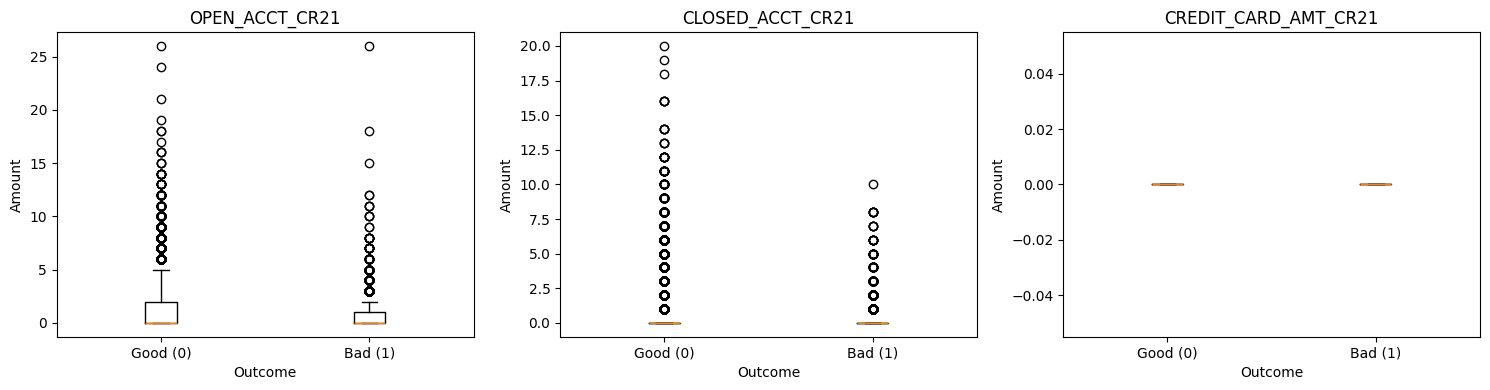

In [357]:
import math
for col in amt_cols_cr21:
    df_train[col] = pd.to_numeric(df_train[col], errors="coerce")


 # Number of columns per row
n_cols = 3
n_plots = len(amt_cols_cr21)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()



for i, col in enumerate(amt_cols_cr21):
    good = df_train.loc[df_train["OUTCOME"] == 0, col].dropna()
    bad  = df_train.loc[df_train["OUTCOME"] == 1, col].dropna()

    if len(good) == 0 or len(bad) == 0:
        axes[i].set_visible(False)
        continue

    axes[i].boxplot([good, bad], labels=["Good (0)", "Bad (1)"])
    axes[i].set_title(col)
    axes[i].set_ylabel("Amount")
    axes[i].set_xlabel("Outcome")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\1432866363.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([good, bad], labels=["Good (0)", "Bad (1)"])
C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\1432866363.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([good, bad], labels=["Good (0)", "Bad (1)"])
C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\1432866363.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([good, bad], labels=["Good (0)", "Bad (1)"])


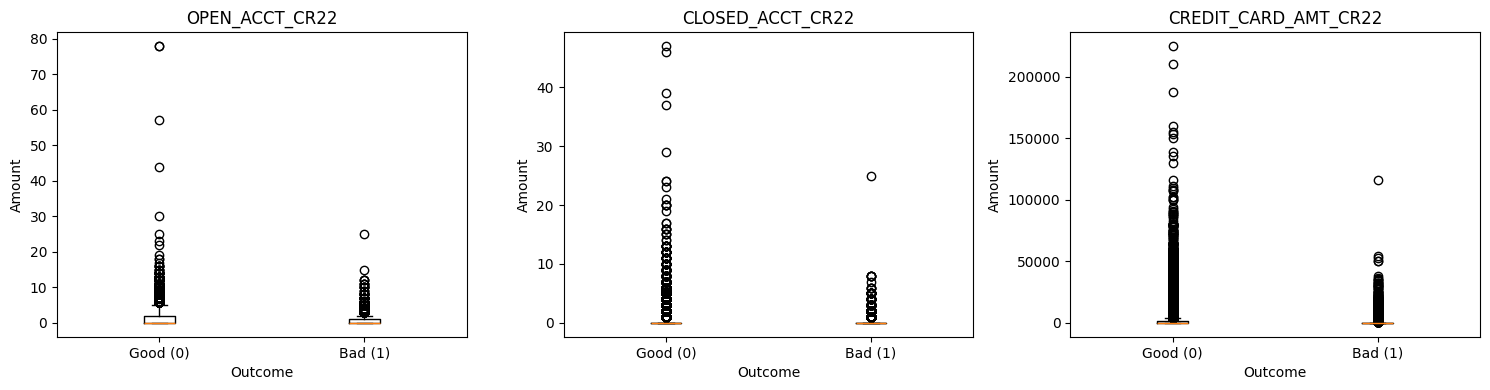

In [358]:
for col in amt_cols_cr22:
    df_train[col] = pd.to_numeric(df_train[col], errors="coerce")



# Number of columns per row
n_cols = 3
n_plots = len(amt_cols_cr22)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(amt_cols_cr22):
    good = df_train.loc[df_train["OUTCOME"] == 0, col].dropna()
    bad  = df_train.loc[df_train["OUTCOME"] == 1, col].dropna()

    if len(good) == 0 or len(bad) == 0:
        axes[i].set_visible(False)
        continue

    axes[i].boxplot([good, bad], labels=["Good (0)", "Bad (1)"])
    axes[i].set_title(col)
    axes[i].set_ylabel("Amount")
    axes[i].set_xlabel("Outcome")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- CR22 open account counts show wider variation, capturing more recent and informative credit behavior than CR21.

- CR22 closed account counts vary more, indicating better reflection of recent account closures.

- CR22 credit card amounts show higher dispersion, reflecting updated credit exposure compared to CR21.

**Overall Insight:**

CR22 features provide stronger signals and better outcome separation, making them more predictive than CR21 for bad debt modeling.

In [359]:
cols_to_keep = ['RISK_RELATIVE_CR21']

cr21_cols_to_drop = [
    col for col in df_train.columns
    if 'CR21' in col and col not in cols_to_keep
]

df_train = df_train.drop(columns=cr21_cols_to_drop)

In [360]:
cr21_cols_to_drop

['SCORECARD_CR21',
 'RISK_RELATIVE_ODDS_CR21',
 'ENQUIRY_CNT_CR21',
 'ENQUIRY_CNT_1M_CR21',
 'ENQUIRY_CNT_3M_CR21',
 'ENQUIRY_CNT_6M_CR21',
 'ENQUIRY_CNT_12M_CR21',
 'OPEN_ACCT_CR21',
 'CLOSED_ACCT_CR21',
 'MORTGAGE_CR21',
 'CREDIT_CARD_CR21',
 'TELCO_CR21',
 'UTILITIES_CR21',
 'OVERDRAFT_CR21',
 'PERSONAL_LOAN_CR21',
 'AUTO_LOAN_CR21',
 'CREDIT_CARD_AMT_CR21',
 'OVERDRAFT_AMT_CR21',
 'PERSONAL_LOAN_AMT_CR21',
 'AUTO_LOAN_AMT_CR21',
 'DEFAULT_CNT_CR21',
 'DEFAULT_OPEN_CNT_CR21',
 'DEFAULT_UNPAID_AMT_CR21',
 'DEFAULT_CNT_3M_CR21',
 'DEFAULT_CNT_6M_CR21',
 'DEFAULT_CNT_12M_CR21']

In [361]:
[col for col in df_train.columns if 'CR21' in col]

['RISK_RELATIVE_CR21']

**Droping CR22 for Train sets**

In [362]:
df_train = df_train.drop(columns=["NO_SCORE", "Customer"])

In [363]:
len(df_train.columns)

60

In [364]:
num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns.tolist() # Numerical columns


cat_cols = df_train.select_dtypes(include=["object", "category"]).columns.tolist() # Categorical columns

print("Numerical Columns count:", len(num_cols))
print("Categorical Columns count:", len(cat_cols))

Numerical Columns count: 47
Categorical Columns count: 13


**Drop CR21 for X_test as well**

In [365]:
cols_to_keep = ['RISK_RELATIVE_CR21']

cr21_cols_to_drop = [
    col for col in df_test.columns
    if 'CR21' in col and col not in cols_to_keep
]

df_test = df_test.drop(columns=cr21_cols_to_drop)

In [366]:
[col for col in df_test.columns if 'CR21' in col]

['RISK_RELATIVE_CR21']

In [367]:
df_test = df_test.drop(columns=["NO_SCORE", "Customer"])

In [368]:
len(df_test.columns)

60

In [369]:
num_cols = df_test.select_dtypes(include=["int64", "float64"]).columns.tolist() # Numerical columns


cat_cols = df_test.select_dtypes(include=["object", "category"]).columns.tolist() # Categorical columns

print("Numerical Columns count:", len(num_cols))
print("Categorical Columns count:", len(cat_cols))

Numerical Columns count: 47
Categorical Columns count: 13


### **Box Plot**

c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future vers

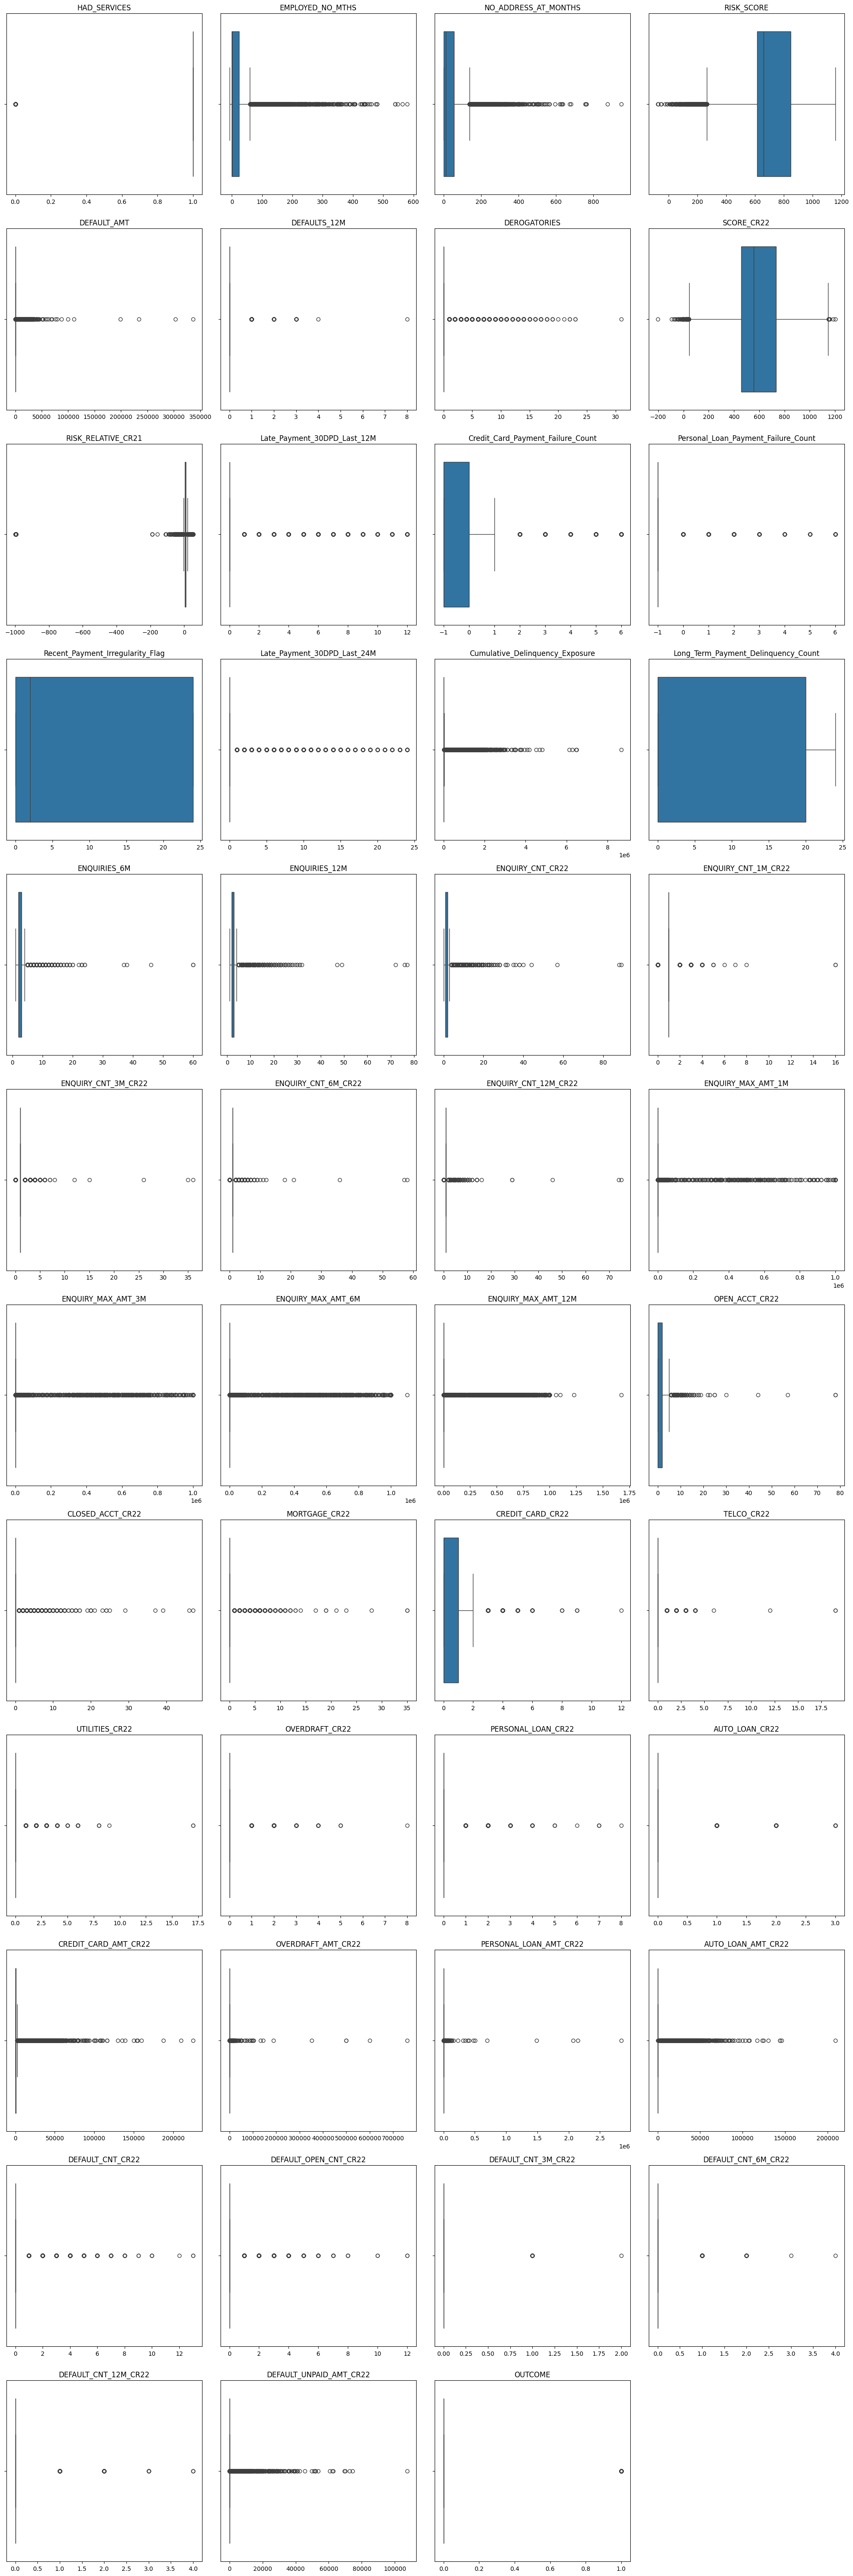

In [370]:
# List of numerical columns
num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

plots_per_row = 4
num_plots = len(num_cols)
num_rows = math.ceil(num_plots / plots_per_row)

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(5 * plots_per_row, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df_train[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("Outliers_Detection.png")
plt.show()

### **Distribution Plot**

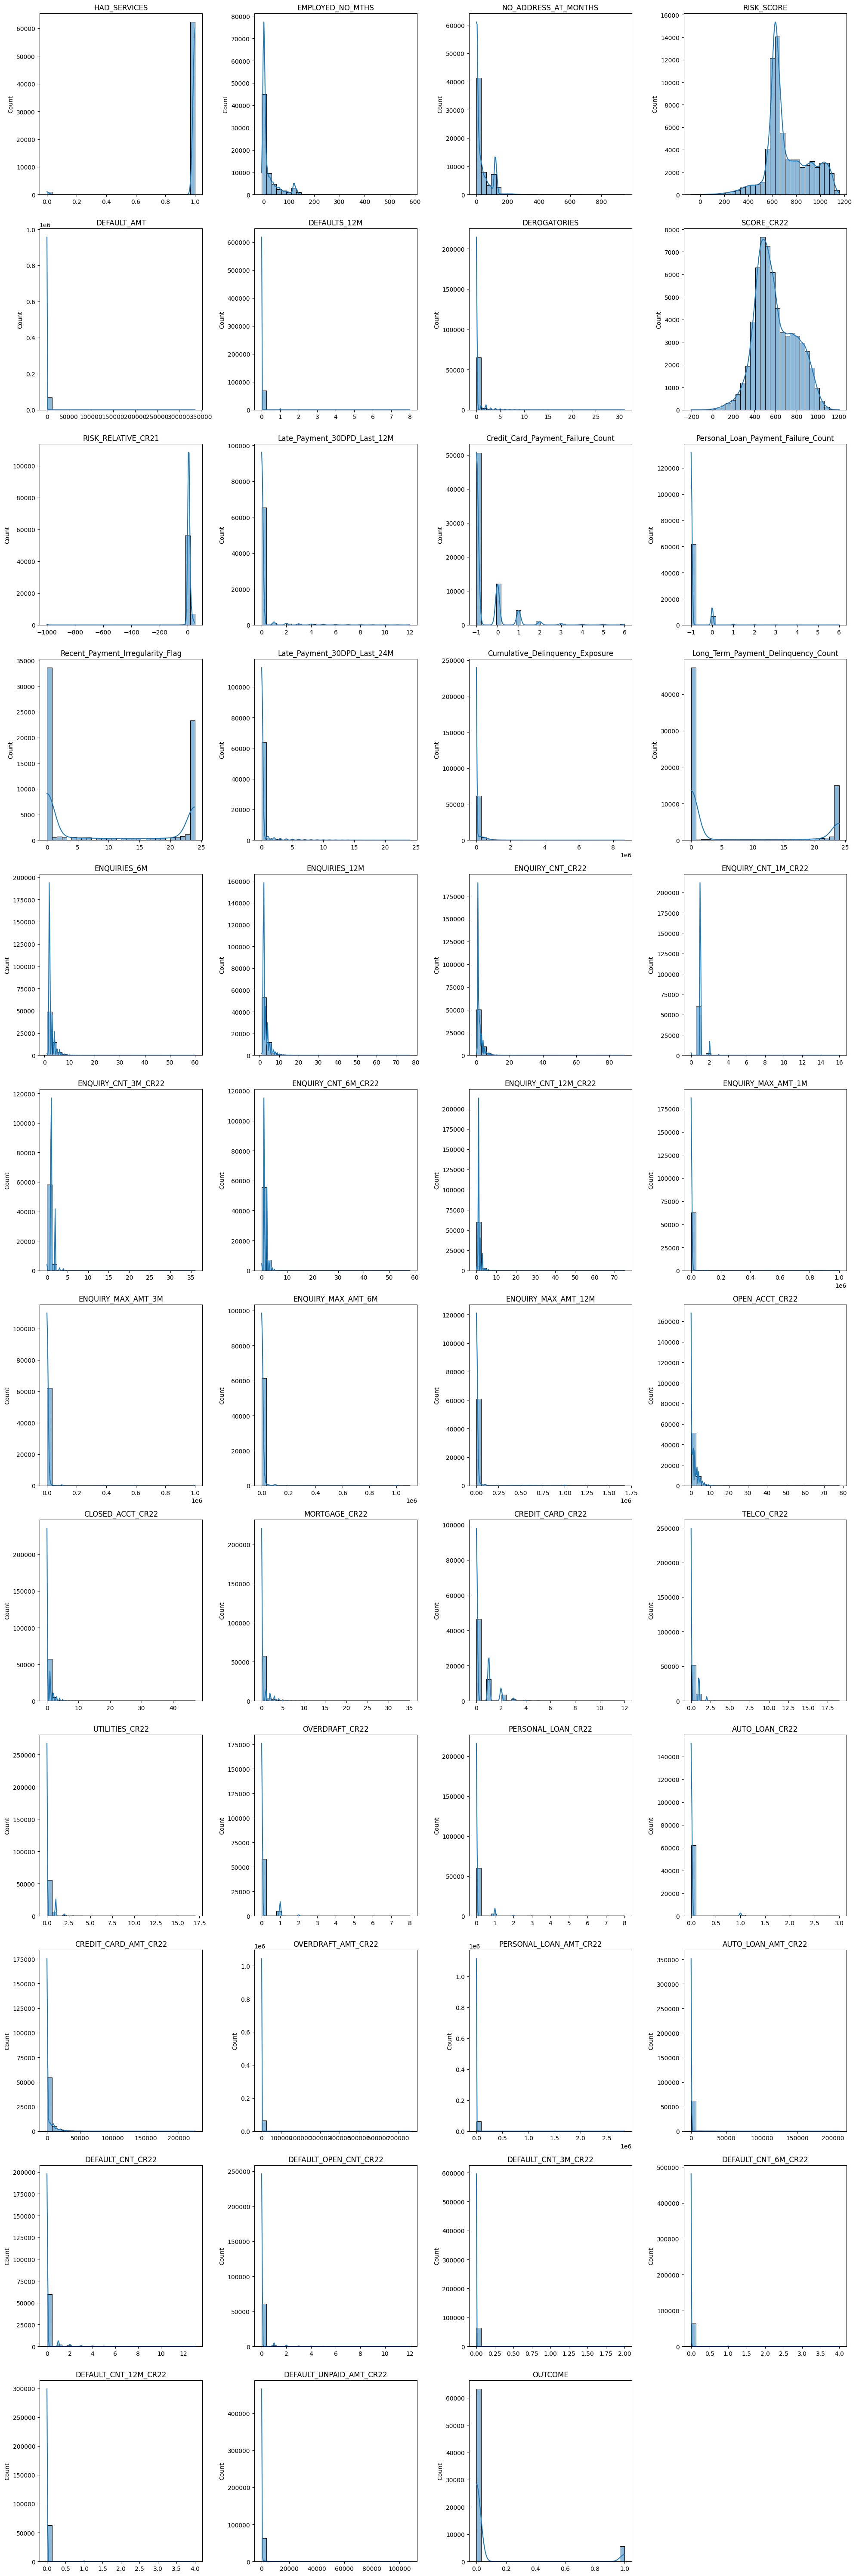

In [371]:
num_plots = len(num_cols)
plots_per_row = 4
num_rows = math.ceil(num_plots / plots_per_row)

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(5 * plots_per_row, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df_train[col].dropna(),   # IMPORTANT: avoid NaN issues
        ax=axes[i],
        bins=30,
        kde=True
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("Distribution_plot_continuous.png")
plt.show()

In [372]:
df_train.describe()

,HAD_SERVICES,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,RISK_SCORE,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,SCORE_CR22,RISK_RELATIVE_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,OUTCOME
count,63289.00,68866.00,63289.00,68866.00,68866.00,68866.00,68866.00,62874.00,63289.00,68866.00,68866.00,68866.00,68866.00,68866.00,68866.00,68866.00,68866.00,68866.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,63289.00,68866.00
mean,0.98,20.56,36.35,720.92,236.82,0.01,0.25,590.90,7.27,0.18,-0.59,-0.88,10.27,0.34,80967.66,6.64,2.61,2.99,1.93,1.04,1.09,1.15,1.27,2854.57,7594.34,11117.89,16300.22,1.21,0.45,0.34,0.36,0.20,0.14,0.09,0.06,0.02,2777.22,202.28,966.71,502.24,0.09,0.06,0.00,0.00,0.01,173.68,0.08
std,0.13,38.33,51.10,180.57,2868.30,0.11,1.13,189.33,47.85,1.01,0.86,0.40,11.20,1.67,243950.23,10.35,1.38,1.99,1.96,0.27,0.44,0.62,0.89,40372.14,67411.30,81087.99,97967.81,1.92,1.16,1.03,0.69,0.48,0.43,0.32,0.27,0.15,7420.94,5293.65,18696.39,4484.52,0.48,0.36,0.03,0.06,0.10,1683.94,0.27
min,0.00,-8.00,0.00,-76.00,0.00,0.00,0.00,-204.00,-999.00,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,1.00,614.00,0.00,0.00,0.00,457.00,4.93,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,1.00,12.00,660.00,0.00,0.00,0.00,558.00,9.14,0.00,-1.00,-1.00,2.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.00,24.00,56.00,847.00,0.00,0.00,0.00,732.00,10.87,0.00,0.00,-1.00,24.00,0.00,15000.00,20.00,3.00,3.00,2.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,579.00,948.00,1157.00,336220.00,8.00,31.00,1203.00,52.77,12.00,6.00,6.00,24.00,24.00,8662123.00,24.00,60.00,77.00,89.00,16.00,36.00,58.00,75.00,999999.00,999999.00,1100000.00,1674284.00,78.00,47.00,35.00,12.00,19.00,17.00,8.00,8.00,3.00,225000.00,760000.00,2839800.00,209165.00,13.00,12.00,2.00,4.00,4.00,107388.00,1.00


**Detecting Risk Realtive_CR21 Outliers Detection**

In [373]:



# Calculate quartiles
Q1 = df_train["RISK_RELATIVE_CR21"].quantile(0.25)
Q3 = df_train["RISK_RELATIVE_CR21"].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 4.93
Q3: 10.87
IQR: 5.9399999999999995
Lower Bound: -12.89
Upper Bound: 28.689999999999998


In [374]:
df_train.shape

(68866, 60)

In [375]:
df_train = df_train[(df_train["RISK_RELATIVE_CR21"] > lower_bound)]
df_train.shape

(62912, 60)

In [376]:
df_train.describe()

,HAD_SERVICES,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,RISK_SCORE,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,SCORE_CR22,RISK_RELATIVE_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,OUTCOME
count,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62499.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00
mean,0.98,22.35,36.32,725.99,185.79,0.01,0.21,592.75,9.64,0.14,-0.61,-0.89,9.95,0.27,80509.43,6.51,2.50,2.84,1.91,1.04,1.09,1.15,1.27,2867.85,7631.85,11161.66,16320.73,1.21,0.45,0.34,0.36,0.20,0.14,0.09,0.06,0.02,2786.58,202.21,952.90,489.71,0.09,0.05,0.00,0.00,0.01,153.00,0.08
std,0.13,39.46,51.10,175.17,2607.46,0.08,0.97,187.94,8.08,0.85,0.82,0.36,11.21,1.45,243813.18,10.31,1.22,1.79,1.91,0.26,0.43,0.61,0.87,40489.90,67608.84,81321.25,98121.01,1.92,1.16,1.03,0.69,0.48,0.43,0.32,0.27,0.15,7435.00,5309.30,18738.70,4422.71,0.45,0.33,0.02,0.06,0.09,1523.38,0.27
min,0.00,-8.00,0.00,44.00,0.00,0.00,0.00,-94.00,-12.81,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,1.00,616.00,0.00,0.00,0.00,458.00,4.97,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,2.00,12.00,660.00,0.00,0.00,0.00,559.00,9.14,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.00,26.00,55.25,847.00,0.00,0.00,0.00,733.00,10.87,0.00,0.00,-1.00,24.00,0.00,14562.50,20.00,3.00,3.00,2.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,579.00,948.00,1157.00,336220.00,3.00,31.00,1203.00,52.77,12.00,6.00,6.00,24.00,24.00,8662123.00,24.00,60.00,77.00,89.00,16.00,36.00,58.00,75.00,999999.00,999999.00,1100000.00,1674284.00,78.00,47.00,35.00,12.00,19.00,17.00,8.00,8.00,3.00,225000.00,760000.00,2839800.00,209165.00,13.00,12.00,1.00,3.00,4.00,74380.00,1.00


In [377]:

# Calculate quartiles
Q1 = df_test["RISK_RELATIVE_CR21"].quantile(0.25)
Q3 = df_test["RISK_RELATIVE_CR21"].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 4.97
Q3: 10.87
IQR: 5.8999999999999995
Lower Bound: -12.73
Upper Bound: 28.57


In [378]:
df_test = df_test[(df_test["RISK_RELATIVE_CR21"] > lower_bound)]
df_test.shape

(20960, 60)

In [379]:
df_test.describe()

,HAD_SERVICES,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,RISK_SCORE,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,SCORE_CR22,RISK_RELATIVE_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,OUTCOME
count,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20803.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00
mean,0.98,22.82,37.10,727.80,219.79,0.01,0.22,594.99,9.65,0.13,-0.61,-0.90,10.01,0.26,85050.31,6.54,2.51,2.85,1.95,1.04,1.09,1.16,1.28,2425.30,7222.51,11115.67,16440.65,1.26,0.43,0.37,0.37,0.20,0.14,0.09,0.05,0.03,2807.93,207.43,1038.49,2340.53,0.10,0.07,0.00,0.00,0.00,177.50,0.08
std,0.13,39.12,52.58,176.21,7243.11,0.09,2.00,188.86,8.11,0.82,0.82,0.35,11.23,1.44,258328.70,10.33,1.55,2.48,3.93,0.33,0.66,1.13,1.92,35411.25,64767.61,81486.75,99316.72,2.87,1.14,1.08,0.71,0.49,0.46,0.32,0.26,2.02,7408.26,7286.94,22410.50,263651.94,1.81,1.78,0.02,0.06,0.08,3739.27,0.27
min,0.00,-5.00,0.00,19.00,0.00,0.00,0.00,-64.00,-12.38,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,1.00,617.00,0.00,0.00,0.00,459.00,5.07,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,3.00,12.00,662.00,0.00,0.00,0.00,560.00,9.14,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.00,27.00,60.00,855.00,0.00,0.00,0.00,736.00,10.87,0.00,0.00,-1.00,24.00,0.00,15000.00,20.00,3.00,3.00,2.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,720.00,819.00,1157.00,1017272.00,3.00,253.00,1178.00,52.77,12.00,6.00,6.00,24.00,24.00,6227500.00,24.00,125.00,239.00,490.00,24.00,62.00,123.00,237.00,1000000.00,1000000.00,1574000.00,1574000.00,296.00,56.00,36.00,9.00,22.00,19.00,4.00,6.00,292.00,150000.00,1000000.00,2551000.00,38164805.00,253.00,253.00,1.00,4.00,4.00,468973.00,1.00


In [380]:
df_train.shape

(62912, 60)

In [381]:
df_test.shape

(20960, 60)

### **KDE Plot Distribution**

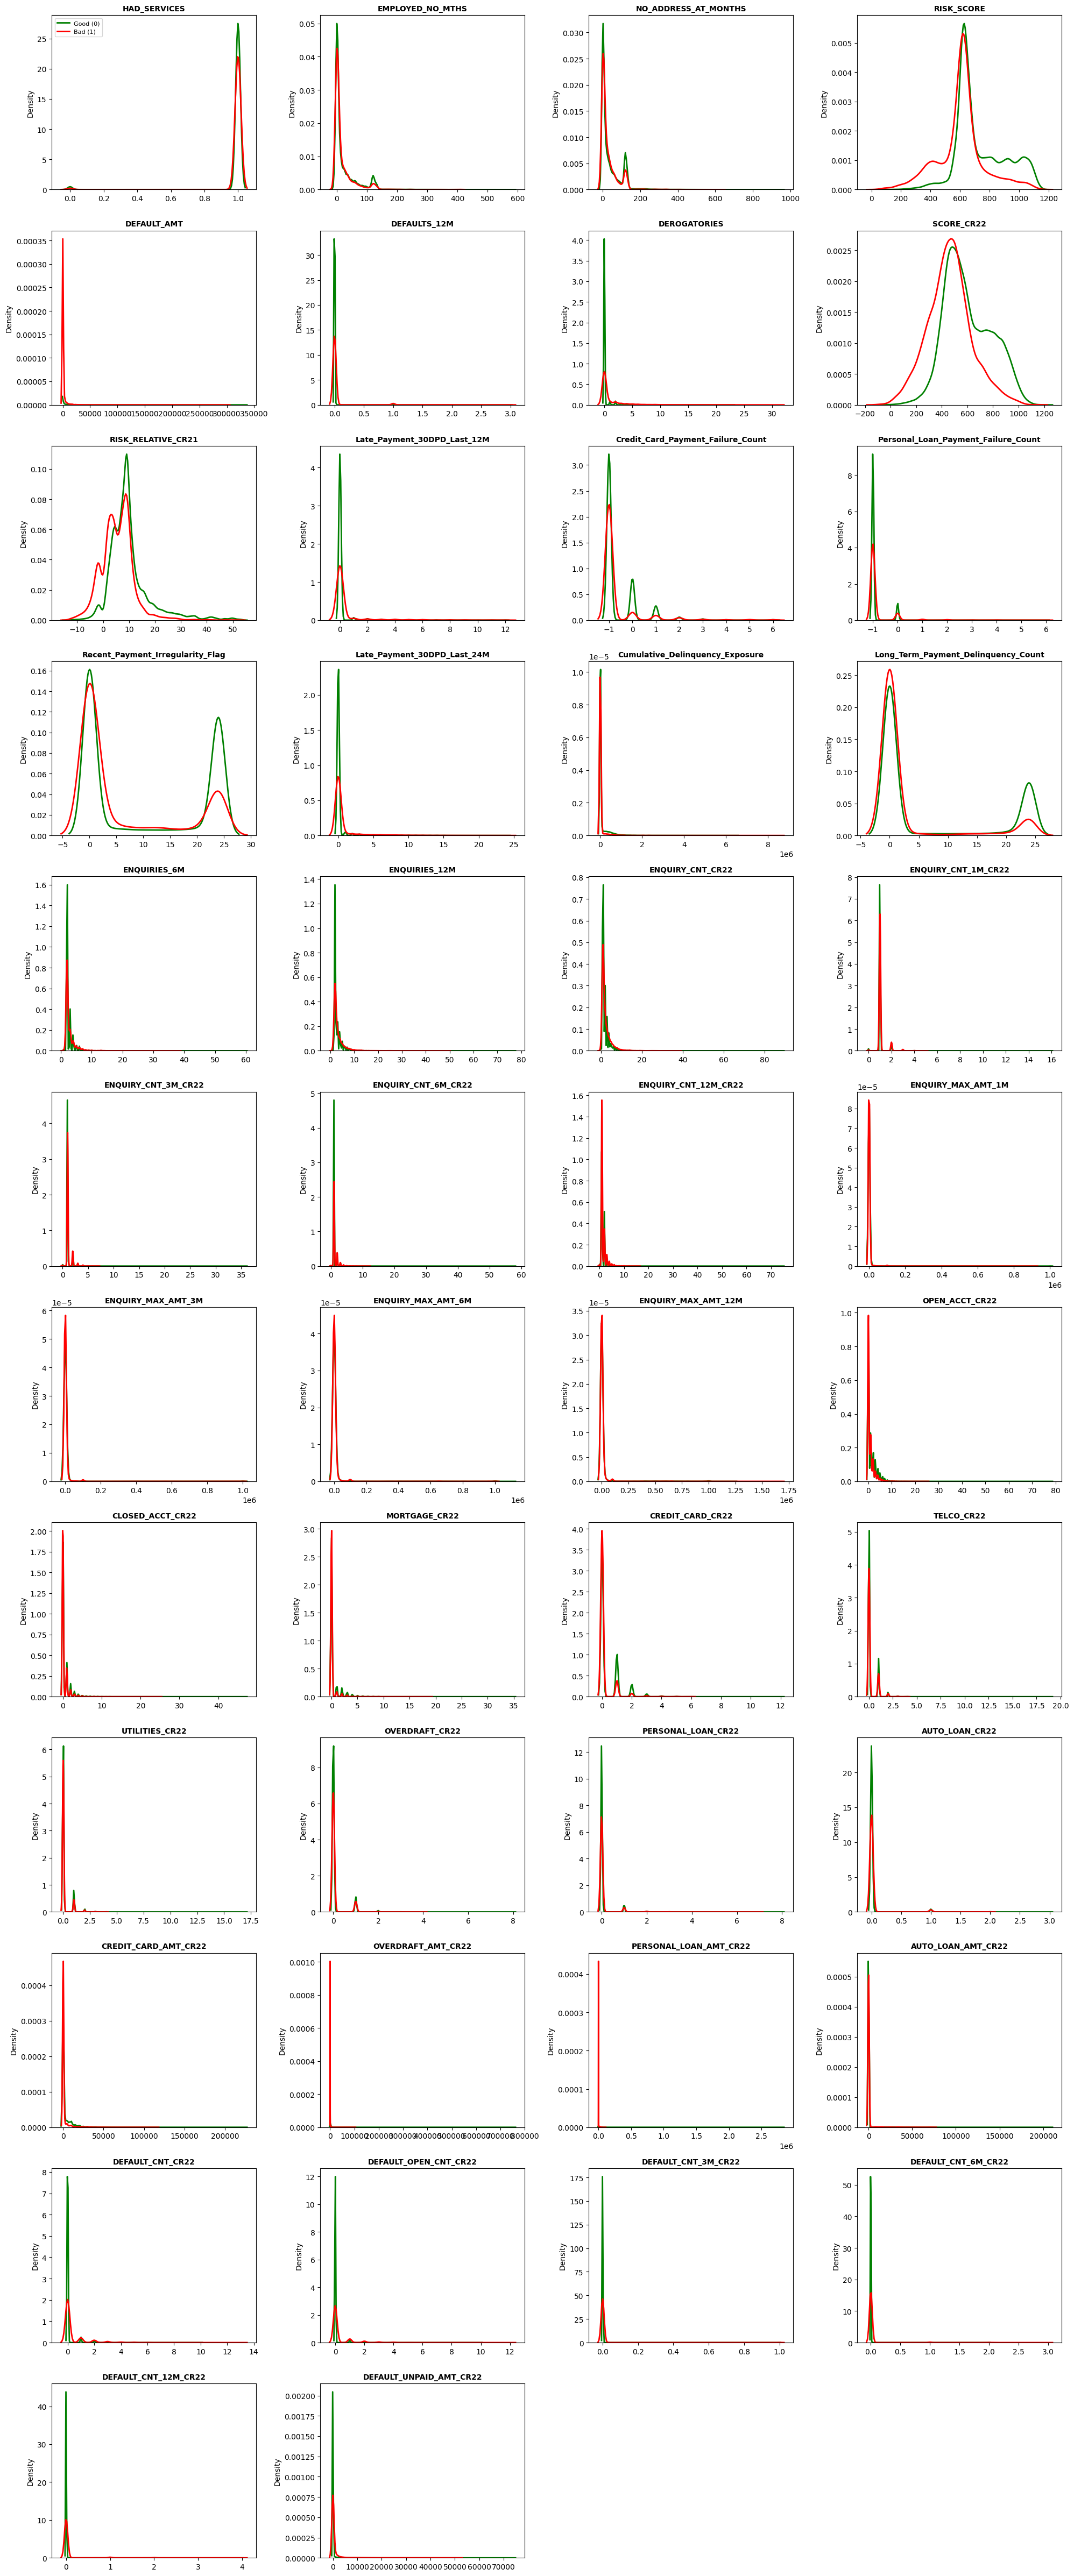

In [382]:
# Select numerical columns (exclude target)
num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [col for col in num_cols if col != "OUTCOME"]

plots_per_row = 4
num_plots = len(num_cols)
num_rows = math.ceil(num_plots / plots_per_row)

fig, axes = plt.subplots(
    num_rows,
    plots_per_row,
    figsize=(5 * plots_per_row, 4 * num_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Good (0)
    sns.kdeplot(
        df_train.loc[df["OUTCOME"] == 0, col].dropna(),
        ax=axes[i],
        color="green",
        linewidth=2,
        label="Good (0)",
        common_norm=False
    )

    # Bad (1)
    sns.kdeplot(
        df_train.loc[df["OUTCOME"] == 1, col].dropna(),
        ax=axes[i],
        color="red",
        linewidth=2,
        label="Bad (1)",
        common_norm=False
    )

    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

    # Show legend only once
    if i == 0:
        axes[i].legend(fontsize=8)
    else:
        axes[i].legend().remove()


        # Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("Outcome_Wise_KDE_Distribution.png")
plt.show()

In [383]:
df_train.columns

Index(['LICENCE_AVAILABLE', 'RESIDENTIAL', 'CD_OCCUPATION',
       'CD_STS_RESIDENTIAL', 'HAD_SERVICES', 'DOC_TYPE', 'VISA_TYPE',
       'EMPLOYED_STATUS', 'EMPLOYED_TYPE', 'EMPLOYED_NO_MTHS',
       'NO_ADDRESS_AT_MONTHS', 'APPLICANT_AGE', 'RISK_SCORE', 'BUREAU_DEFAULT',
       'DEFAULT_AMT', 'DEFAULTS_12M', 'DEROGATORIES', 'SCORECARD',
       'SCORE_CR22', 'SCORE_BAND_CR22', 'RISK_RELATIVE_CR21',
       'Late_Payment_30DPD_Last_12M', 'Credit_Card_Payment_Failure_Count',
       'Personal_Loan_Payment_Failure_Count',
       'Recent_Payment_Irregularity_Flag', 'Late_Payment_30DPD_Last_24M',
       'Cumulative_Delinquency_Exposure',
       'Long_Term_Payment_Delinquency_Count', 'BUREAU_ENQUIRIES_12_MONTHS',
       'ENQUIRIES_6M', 'ENQUIRIES_12M', 'ENQUIRY_CNT_CR22',
       'ENQUIRY_CNT_1M_CR22', 'ENQUIRY_CNT_3M_CR22', 'ENQUIRY_CNT_6M_CR22',
       'ENQUIRY_CNT_12M_CR22', 'ENQUIRY_MAX_AMT_1M', 'ENQUIRY_MAX_AMT_3M',
       'ENQUIRY_MAX_AMT_6M', 'ENQUIRY_MAX_AMT_12M', 'OPEN_ACCT_CR22',
    

In [384]:
df_train.isna().sum().sort_values(ascending=False)

SCORE_CR22                             413
LICENCE_AVAILABLE                        0
ENQUIRY_CNT_CR22                         0
ENQUIRY_CNT_3M_CR22                      0
ENQUIRY_CNT_6M_CR22                      0
ENQUIRY_CNT_12M_CR22                     0
ENQUIRY_MAX_AMT_1M                       0
ENQUIRY_MAX_AMT_3M                       0
ENQUIRY_MAX_AMT_6M                       0
ENQUIRY_MAX_AMT_12M                      0
OPEN_ACCT_CR22                           0
CLOSED_ACCT_CR22                         0
MORTGAGE_CR22                            0
CREDIT_CARD_CR22                         0
TELCO_CR22                               0
UTILITIES_CR22                           0
OVERDRAFT_CR22                           0
PERSONAL_LOAN_CR22                       0
AUTO_LOAN_CR22                           0
CREDIT_CARD_AMT_CR22                     0
OVERDRAFT_AMT_CR22                       0
PERSONAL_LOAN_AMT_CR22                   0
AUTO_LOAN_AMT_CR22                       0
DEFAULT_CNT

In [385]:
df_test.isna().sum().sort_values(ascending=False)

SCORE_CR22                             157
LICENCE_AVAILABLE                        0
ENQUIRY_CNT_CR22                         0
ENQUIRY_CNT_3M_CR22                      0
ENQUIRY_CNT_6M_CR22                      0
ENQUIRY_CNT_12M_CR22                     0
ENQUIRY_MAX_AMT_1M                       0
ENQUIRY_MAX_AMT_3M                       0
ENQUIRY_MAX_AMT_6M                       0
ENQUIRY_MAX_AMT_12M                      0
OPEN_ACCT_CR22                           0
CLOSED_ACCT_CR22                         0
MORTGAGE_CR22                            0
CREDIT_CARD_CR22                         0
TELCO_CR22                               0
UTILITIES_CR22                           0
OVERDRAFT_CR22                           0
PERSONAL_LOAN_CR22                       0
AUTO_LOAN_CR22                           0
CREDIT_CARD_AMT_CR22                     0
OVERDRAFT_AMT_CR22                       0
PERSONAL_LOAN_AMT_CR22                   0
AUTO_LOAN_AMT_CR22                       0
DEFAULT_CNT

- **Duration & demographic variables** are imputed using the **median** to preserve central tendency.
- **Bureau exposure, counts, and amount features** are filled with **zero**, indicating no activity.
- Zero imputation avoids introducing artificial credit behavior.
- **Derived risk metrics** retain **NaN values** to preserve missing-risk information.



In [386]:
#  Duration / demographic → MEDIAN
median_cols = [
    "SCORE_CR22",
    "NO_ADDRESS_AT_MONTHS",
    "EMPLOYED_NO_MTHS"
]

#  Bureau exposure / counts / amounts → ZERO 
zero_fill_cols = [
    "CREDIT_CARD_AMT_CR22",
    "AUTO_LOAN_AMT_CR22",
    "PERSONAL_LOAN_AMT_CR22",
    "OPEN_ACCT_CR22",
    "CLOSED_ACCT_CR22",
    "DEFAULT_CNT_CR22",
    "DEFAULT_OPEN_CNT_CR22",
    "ENQUIRY_CNT_CR22",
    "ENQUIRY_CNT_1M_CR22",
    "ENQUIRY_CNT_3M_CR22",
    "ENQUIRY_CNT_6M_CR22",
    "ENQUIRY_CNT_12M_CR22",
    "ENQUIRY_MAX_AMT_1M",
    "ENQUIRY_MAX_AMT_3M",
    "ENQUIRY_MAX_AMT_6M",
    "ENQUIRY_MAX_AMT_12M",
    "HAD_SERVICES",
    "UTILITIES_CR22",
    "DEFAULT_UNPAID_AMT_CR22",
    "DEFAULT_CNT_6M_CR22",
    "DEFAULT_CNT_12M_CR22",
    "DEFAULT_CNT_3M_CR22",
    "OVERDRAFT_CR22",
    "PERSONAL_LOAN_CR22",
    "AUTO_LOAN_CR22",
    "OVERDRAFT_AMT_CR22",
    "MORTGAGE_CR22",
    "CREDIT_CARD_CR22",
    "TELCO_CR22",
]

#  Derived risk metrics → KEEP NaN + FLAG 
risk_cols = [
    "RISK_SCORE",
    "RISK_RELATIVE_CR21",
    "RISK_RELATIVE_ODDS_CR21"
]


In [387]:
for col in median_cols:
    median_val = df_train[col].median()
    df_train[col] = df_train[col].fillna(median_val)
    df_test[col]  = df_test[col].fillna(median_val)

for col in zero_fill_cols:
    df_train[col] = df_train[col].fillna(0)
    df_test[col]  = df_test[col].fillna(0)

In [388]:
df_train.isna().sum().sort_values(ascending=False)


LICENCE_AVAILABLE                      0
RESIDENTIAL                            0
ENQUIRY_CNT_1M_CR22                    0
ENQUIRY_CNT_3M_CR22                    0
ENQUIRY_CNT_6M_CR22                    0
ENQUIRY_CNT_12M_CR22                   0
ENQUIRY_MAX_AMT_1M                     0
ENQUIRY_MAX_AMT_3M                     0
ENQUIRY_MAX_AMT_6M                     0
ENQUIRY_MAX_AMT_12M                    0
OPEN_ACCT_CR22                         0
CLOSED_ACCT_CR22                       0
MORTGAGE_CR22                          0
CREDIT_CARD_CR22                       0
TELCO_CR22                             0
UTILITIES_CR22                         0
OVERDRAFT_CR22                         0
PERSONAL_LOAN_CR22                     0
AUTO_LOAN_CR22                         0
CREDIT_CARD_AMT_CR22                   0
OVERDRAFT_AMT_CR22                     0
PERSONAL_LOAN_AMT_CR22                 0
AUTO_LOAN_AMT_CR22                     0
DEFAULT_CNT_CR22                       0
DEFAULT_OPEN_CNT

In [389]:
df_test.isna().sum().sort_values(ascending=False)

LICENCE_AVAILABLE                      0
RESIDENTIAL                            0
ENQUIRY_CNT_1M_CR22                    0
ENQUIRY_CNT_3M_CR22                    0
ENQUIRY_CNT_6M_CR22                    0
ENQUIRY_CNT_12M_CR22                   0
ENQUIRY_MAX_AMT_1M                     0
ENQUIRY_MAX_AMT_3M                     0
ENQUIRY_MAX_AMT_6M                     0
ENQUIRY_MAX_AMT_12M                    0
OPEN_ACCT_CR22                         0
CLOSED_ACCT_CR22                       0
MORTGAGE_CR22                          0
CREDIT_CARD_CR22                       0
TELCO_CR22                             0
UTILITIES_CR22                         0
OVERDRAFT_CR22                         0
PERSONAL_LOAN_CR22                     0
AUTO_LOAN_CR22                         0
CREDIT_CARD_AMT_CR22                   0
OVERDRAFT_AMT_CR22                     0
PERSONAL_LOAN_AMT_CR22                 0
AUTO_LOAN_AMT_CR22                     0
DEFAULT_CNT_CR22                       0
DEFAULT_OPEN_CNT

### **Analysisng the Patten of Risk score**

 **Correlation Analysis Shows SCORE_CR22 Alone Is Sufficient to Represent Credit Risk**

In [390]:
df[['SCORE_CR22', 'RISK_SCORE', 'RISK_RELATIVE_CR21']].corr()

,SCORE_CR22,RISK_SCORE,RISK_RELATIVE_CR21
SCORE_CR22,1.00,0.81,0.15
RISK_SCORE,0.81,1.00,0.17
RISK_RELATIVE_CR21,0.15,0.17,1.00


In [391]:
df[['RISK_SCORE', 'OUTCOME']].corr()

,RISK_SCORE,OUTCOME
RISK_SCORE,1.00,-0.22
OUTCOME,-0.22,1.00


In [392]:
df[['SCORE_CR22', 'OUTCOME']].corr()

,SCORE_CR22,OUTCOME
SCORE_CR22,1.00,-0.21
OUTCOME,-0.21,1.00


In [393]:
df[['RISK_RELATIVE_CR21', 'OUTCOME']].corr()

,RISK_RELATIVE_CR21,OUTCOME
RISK_RELATIVE_CR21,1.00,-0.04
OUTCOME,-0.04,1.00


In [394]:
df[['SCORE_CR22', 'RISK_SCORE']].describe()

,SCORE_CR22,RISK_SCORE
count,83824.00,91822.00
mean,591.38,721.41
std,189.60,180.73
min,-204.00,-125.00
25%,457.00,614.00
50%,558.00,660.00
75%,733.00,848.75
max,1203.00,1157.00


**Correlation analysis showed high redundancy between SCORE_CR22 and RISK_SCORE (ρ = 0.81). To avoid multicollinearity, SCORE_CR22 was retained while RISK_SCORE was excluded. RISK_RELATIVE_CR21 was removed due to weak correlation and data instability.**

In [395]:
df_train[df_train['DEROGATORIES']==253]


,LICENCE_AVAILABLE,RESIDENTIAL,CD_OCCUPATION,CD_STS_RESIDENTIAL,HAD_SERVICES,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,APPLICANT_AGE,RISK_SCORE,BUREAU_DEFAULT,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,SCORECARD,SCORE_CR22,SCORE_BAND_CR22,RISK_RELATIVE_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,BUREAU_ENQUIRIES_12_MONTHS,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,OUTCOME


In [396]:
df_test[df_test['DEROGATORIES']==253]

,LICENCE_AVAILABLE,RESIDENTIAL,CD_OCCUPATION,CD_STS_RESIDENTIAL,HAD_SERVICES,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,APPLICANT_AGE,RISK_SCORE,BUREAU_DEFAULT,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,SCORECARD,SCORE_CR22,SCORE_BAND_CR22,RISK_RELATIVE_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,BUREAU_ENQUIRIES_12_MONTHS,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,OUTCOME
38976,yes,Living_With_Family,employed,B,1.00,AU Driver Licence,Resident,employed,Missing,1.00,1.00,45-54,215,Missing,0,0,253,TAR1A,-56.00,High,12.40,0,-1,-1,0,0,0,0,14+,125,239,490.00,24.00,62.00,123.00,237.00,300.00,2000.00,2000.00,2000.00,296.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,292.00,3000.00,300.00,25215.00,38164805.00,253.00,253.00,0.00,0.00,0.00,468973.00,0


-----------------------------------------------------------------------------

<p align="center" style="color:blue; font-size:35px; font-weight:bold;">
Feature Engineering
</p>


In [397]:
X_train = df_train.drop('OUTCOME', axis='columns')
y_train = df_train['OUTCOME']

X_test = df_test.drop('OUTCOME', axis='columns')
y_test = df_test['OUTCOME']

In [398]:
X_train.shape

(62912, 59)

In [399]:
X_test.shape

(20960, 59)

In [400]:
X_train.columns

Index(['LICENCE_AVAILABLE', 'RESIDENTIAL', 'CD_OCCUPATION',
       'CD_STS_RESIDENTIAL', 'HAD_SERVICES', 'DOC_TYPE', 'VISA_TYPE',
       'EMPLOYED_STATUS', 'EMPLOYED_TYPE', 'EMPLOYED_NO_MTHS',
       'NO_ADDRESS_AT_MONTHS', 'APPLICANT_AGE', 'RISK_SCORE', 'BUREAU_DEFAULT',
       'DEFAULT_AMT', 'DEFAULTS_12M', 'DEROGATORIES', 'SCORECARD',
       'SCORE_CR22', 'SCORE_BAND_CR22', 'RISK_RELATIVE_CR21',
       'Late_Payment_30DPD_Last_12M', 'Credit_Card_Payment_Failure_Count',
       'Personal_Loan_Payment_Failure_Count',
       'Recent_Payment_Irregularity_Flag', 'Late_Payment_30DPD_Last_24M',
       'Cumulative_Delinquency_Exposure',
       'Long_Term_Payment_Delinquency_Count', 'BUREAU_ENQUIRIES_12_MONTHS',
       'ENQUIRIES_6M', 'ENQUIRIES_12M', 'ENQUIRY_CNT_CR22',
       'ENQUIRY_CNT_1M_CR22', 'ENQUIRY_CNT_3M_CR22', 'ENQUIRY_CNT_6M_CR22',
       'ENQUIRY_CNT_12M_CR22', 'ENQUIRY_MAX_AMT_1M', 'ENQUIRY_MAX_AMT_3M',
       'ENQUIRY_MAX_AMT_6M', 'ENQUIRY_MAX_AMT_12M', 'OPEN_ACCT_CR22',
    

In [401]:
X_test.columns

Index(['LICENCE_AVAILABLE', 'RESIDENTIAL', 'CD_OCCUPATION',
       'CD_STS_RESIDENTIAL', 'HAD_SERVICES', 'DOC_TYPE', 'VISA_TYPE',
       'EMPLOYED_STATUS', 'EMPLOYED_TYPE', 'EMPLOYED_NO_MTHS',
       'NO_ADDRESS_AT_MONTHS', 'APPLICANT_AGE', 'RISK_SCORE', 'BUREAU_DEFAULT',
       'DEFAULT_AMT', 'DEFAULTS_12M', 'DEROGATORIES', 'SCORECARD',
       'SCORE_CR22', 'SCORE_BAND_CR22', 'RISK_RELATIVE_CR21',
       'Late_Payment_30DPD_Last_12M', 'Credit_Card_Payment_Failure_Count',
       'Personal_Loan_Payment_Failure_Count',
       'Recent_Payment_Irregularity_Flag', 'Late_Payment_30DPD_Last_24M',
       'Cumulative_Delinquency_Exposure',
       'Long_Term_Payment_Delinquency_Count', 'BUREAU_ENQUIRIES_12_MONTHS',
       'ENQUIRIES_6M', 'ENQUIRIES_12M', 'ENQUIRY_CNT_CR22',
       'ENQUIRY_CNT_1M_CR22', 'ENQUIRY_CNT_3M_CR22', 'ENQUIRY_CNT_6M_CR22',
       'ENQUIRY_CNT_12M_CR22', 'ENQUIRY_MAX_AMT_1M', 'ENQUIRY_MAX_AMT_3M',
       'ENQUIRY_MAX_AMT_6M', 'ENQUIRY_MAX_AMT_12M', 'OPEN_ACCT_CR22',
    

### **New Feature Creating**


- Address stability is discretized into tenure buckets (<6M, 6–12M, 12–36M, >36M) using `NO_ADDRESS_AT_MONTHS` for better interpretability.


In [402]:
X_train["ADDRESS_STABILITY_BUCKET"] = pd.cut(
    X_train["NO_ADDRESS_AT_MONTHS"],
    bins=[-1, 6, 12, 36, 999],
    labels=["<6M", "6-12M", "12-36M", ">36M"]
).astype("object")

X_test["ADDRESS_STABILITY_BUCKET"] = pd.cut(
    X_test["NO_ADDRESS_AT_MONTHS"],
    bins=[-1, 6, 12, 36, 999],
    labels=["<6M", "6-12M", "12-36M", ">36M"]
).astype("object")

- A **Life Instability Flag** is created to identify customers with both short address tenure and employment duration (<12 months).


In [403]:
X_train["LIFE_INSTABILITY_FLAG"] = (
    (X_train["NO_ADDRESS_AT_MONTHS"] < 12) &
    (X_train["EMPLOYED_NO_MTHS"] < 12)
).astype(int)

X_test["LIFE_INSTABILITY_FLAG"] = (
    (X_test["NO_ADDRESS_AT_MONTHS"] < 12) &
    (X_test["EMPLOYED_NO_MTHS"] < 12)
).astype(int)

In [404]:
X_train.shape

(62912, 61)

In [405]:
X_train.dtypes

LICENCE_AVAILABLE                       object
RESIDENTIAL                             object
CD_OCCUPATION                           object
CD_STS_RESIDENTIAL                      object
HAD_SERVICES                           float64
DOC_TYPE                                object
VISA_TYPE                               object
EMPLOYED_STATUS                         object
EMPLOYED_TYPE                           object
EMPLOYED_NO_MTHS                       float64
NO_ADDRESS_AT_MONTHS                   float64
APPLICANT_AGE                           object
RISK_SCORE                               int64
BUREAU_DEFAULT                          object
DEFAULT_AMT                              int64
DEFAULTS_12M                             int64
DEROGATORIES                             int64
SCORECARD                               object
SCORE_CR22                             float64
SCORE_BAND_CR22                         object
RISK_RELATIVE_CR21                     float64
Late_Payment_

In [406]:
X_train.columns

Index(['LICENCE_AVAILABLE', 'RESIDENTIAL', 'CD_OCCUPATION',
       'CD_STS_RESIDENTIAL', 'HAD_SERVICES', 'DOC_TYPE', 'VISA_TYPE',
       'EMPLOYED_STATUS', 'EMPLOYED_TYPE', 'EMPLOYED_NO_MTHS',
       'NO_ADDRESS_AT_MONTHS', 'APPLICANT_AGE', 'RISK_SCORE', 'BUREAU_DEFAULT',
       'DEFAULT_AMT', 'DEFAULTS_12M', 'DEROGATORIES', 'SCORECARD',
       'SCORE_CR22', 'SCORE_BAND_CR22', 'RISK_RELATIVE_CR21',
       'Late_Payment_30DPD_Last_12M', 'Credit_Card_Payment_Failure_Count',
       'Personal_Loan_Payment_Failure_Count',
       'Recent_Payment_Irregularity_Flag', 'Late_Payment_30DPD_Last_24M',
       'Cumulative_Delinquency_Exposure',
       'Long_Term_Payment_Delinquency_Count', 'BUREAU_ENQUIRIES_12_MONTHS',
       'ENQUIRIES_6M', 'ENQUIRIES_12M', 'ENQUIRY_CNT_CR22',
       'ENQUIRY_CNT_1M_CR22', 'ENQUIRY_CNT_3M_CR22', 'ENQUIRY_CNT_6M_CR22',
       'ENQUIRY_CNT_12M_CR22', 'ENQUIRY_MAX_AMT_1M', 'ENQUIRY_MAX_AMT_3M',
       'ENQUIRY_MAX_AMT_6M', 'ENQUIRY_MAX_AMT_12M', 'OPEN_ACCT_CR22',
    

In [407]:
X_train.shape

(62912, 61)

In [408]:
X_train.describe()

,HAD_SERVICES,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,RISK_SCORE,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,SCORE_CR22,RISK_RELATIVE_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,LIFE_INSTABILITY_FLAG
count,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00
mean,0.98,22.35,36.32,725.99,185.79,0.01,0.21,592.53,9.64,0.14,-0.61,-0.89,9.95,0.27,80509.43,6.51,2.50,2.84,1.91,1.04,1.09,1.15,1.27,2867.85,7631.85,11161.66,16320.73,1.21,0.45,0.34,0.36,0.20,0.14,0.09,0.06,0.02,2786.58,202.21,952.90,489.71,0.09,0.05,0.00,0.00,0.01,153.00,0.38
std,0.13,39.46,51.10,175.17,2607.46,0.08,0.97,187.34,8.08,0.85,0.82,0.36,11.21,1.45,243813.18,10.31,1.22,1.79,1.91,0.26,0.43,0.61,0.87,40489.90,67608.84,81321.25,98121.01,1.92,1.16,1.03,0.69,0.48,0.43,0.32,0.27,0.15,7435.00,5309.30,18738.70,4422.71,0.45,0.33,0.02,0.06,0.09,1523.38,0.49
min,0.00,-8.00,0.00,44.00,0.00,0.00,0.00,-94.00,-12.81,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,1.00,616.00,0.00,0.00,0.00,459.00,4.97,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,2.00,12.00,660.00,0.00,0.00,0.00,559.00,9.14,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.00,26.00,55.25,847.00,0.00,0.00,0.00,732.00,10.87,0.00,0.00,-1.00,24.00,0.00,14562.50,20.00,3.00,3.00,2.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
max,1.00,579.00,948.00,1157.00,336220.00,3.00,31.00,1203.00,52.77,12.00,6.00,6.00,24.00,24.00,8662123.00,24.00,60.00,77.00,89.00,16.00,36.00,58.00,75.00,999999.00,999999.00,1100000.00,1674284.00,78.00,47.00,35.00,12.00,19.00,17.00,8.00,8.00,3.00,225000.00,760000.00,2839800.00,209165.00,13.00,12.00,1.00,3.00,4.00,74380.00,1.00


In [409]:
X_train.shape

(62912, 61)

In [410]:
X_train.describe()

,HAD_SERVICES,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,RISK_SCORE,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,SCORE_CR22,RISK_RELATIVE_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,LIFE_INSTABILITY_FLAG
count,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00,62912.00
mean,0.98,22.35,36.32,725.99,185.79,0.01,0.21,592.53,9.64,0.14,-0.61,-0.89,9.95,0.27,80509.43,6.51,2.50,2.84,1.91,1.04,1.09,1.15,1.27,2867.85,7631.85,11161.66,16320.73,1.21,0.45,0.34,0.36,0.20,0.14,0.09,0.06,0.02,2786.58,202.21,952.90,489.71,0.09,0.05,0.00,0.00,0.01,153.00,0.38
std,0.13,39.46,51.10,175.17,2607.46,0.08,0.97,187.34,8.08,0.85,0.82,0.36,11.21,1.45,243813.18,10.31,1.22,1.79,1.91,0.26,0.43,0.61,0.87,40489.90,67608.84,81321.25,98121.01,1.92,1.16,1.03,0.69,0.48,0.43,0.32,0.27,0.15,7435.00,5309.30,18738.70,4422.71,0.45,0.33,0.02,0.06,0.09,1523.38,0.49
min,0.00,-8.00,0.00,44.00,0.00,0.00,0.00,-94.00,-12.81,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,1.00,616.00,0.00,0.00,0.00,459.00,4.97,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,2.00,12.00,660.00,0.00,0.00,0.00,559.00,9.14,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.00,26.00,55.25,847.00,0.00,0.00,0.00,732.00,10.87,0.00,0.00,-1.00,24.00,0.00,14562.50,20.00,3.00,3.00,2.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
max,1.00,579.00,948.00,1157.00,336220.00,3.00,31.00,1203.00,52.77,12.00,6.00,6.00,24.00,24.00,8662123.00,24.00,60.00,77.00,89.00,16.00,36.00,58.00,75.00,999999.00,999999.00,1100000.00,1674284.00,78.00,47.00,35.00,12.00,19.00,17.00,8.00,8.00,3.00,225000.00,760000.00,2839800.00,209165.00,13.00,12.00,1.00,3.00,4.00,74380.00,1.00


In [411]:
X_train.columns

Index(['LICENCE_AVAILABLE', 'RESIDENTIAL', 'CD_OCCUPATION',
       'CD_STS_RESIDENTIAL', 'HAD_SERVICES', 'DOC_TYPE', 'VISA_TYPE',
       'EMPLOYED_STATUS', 'EMPLOYED_TYPE', 'EMPLOYED_NO_MTHS',
       'NO_ADDRESS_AT_MONTHS', 'APPLICANT_AGE', 'RISK_SCORE', 'BUREAU_DEFAULT',
       'DEFAULT_AMT', 'DEFAULTS_12M', 'DEROGATORIES', 'SCORECARD',
       'SCORE_CR22', 'SCORE_BAND_CR22', 'RISK_RELATIVE_CR21',
       'Late_Payment_30DPD_Last_12M', 'Credit_Card_Payment_Failure_Count',
       'Personal_Loan_Payment_Failure_Count',
       'Recent_Payment_Irregularity_Flag', 'Late_Payment_30DPD_Last_24M',
       'Cumulative_Delinquency_Exposure',
       'Long_Term_Payment_Delinquency_Count', 'BUREAU_ENQUIRIES_12_MONTHS',
       'ENQUIRIES_6M', 'ENQUIRIES_12M', 'ENQUIRY_CNT_CR22',
       'ENQUIRY_CNT_1M_CR22', 'ENQUIRY_CNT_3M_CR22', 'ENQUIRY_CNT_6M_CR22',
       'ENQUIRY_CNT_12M_CR22', 'ENQUIRY_MAX_AMT_1M', 'ENQUIRY_MAX_AMT_3M',
       'ENQUIRY_MAX_AMT_6M', 'ENQUIRY_MAX_AMT_12M', 'OPEN_ACCT_CR22',
    

In [412]:
X_test.shape

(20960, 61)

In [413]:
X_test.describe()

,HAD_SERVICES,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,RISK_SCORE,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,SCORE_CR22,RISK_RELATIVE_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,LIFE_INSTABILITY_FLAG
count,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00,20960.00
mean,0.98,22.82,37.10,727.80,219.79,0.01,0.22,594.72,9.65,0.13,-0.61,-0.90,10.01,0.26,85050.31,6.54,2.51,2.85,1.95,1.04,1.09,1.16,1.28,2425.30,7222.51,11115.67,16440.65,1.26,0.43,0.37,0.37,0.20,0.14,0.09,0.05,0.03,2807.93,207.43,1038.49,2340.53,0.10,0.07,0.00,0.00,0.00,177.50,0.38
std,0.13,39.12,52.58,176.21,7243.11,0.09,2.00,188.17,8.11,0.82,0.82,0.35,11.23,1.44,258328.70,10.33,1.55,2.48,3.93,0.33,0.66,1.13,1.92,35411.25,64767.61,81486.75,99316.72,2.87,1.14,1.08,0.71,0.49,0.46,0.32,0.26,2.02,7408.26,7286.94,22410.50,263651.94,1.81,1.78,0.02,0.06,0.08,3739.27,0.48
min,0.00,-5.00,0.00,19.00,0.00,0.00,0.00,-64.00,-12.38,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,1.00,617.00,0.00,0.00,0.00,459.75,5.07,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,3.00,12.00,662.00,0.00,0.00,0.00,559.00,9.14,0.00,-1.00,-1.00,0.00,0.00,0.00,0.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.00,27.00,60.00,855.00,0.00,0.00,0.00,735.00,10.87,0.00,0.00,-1.00,24.00,0.00,15000.00,20.00,3.00,3.00,2.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,2.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
max,1.00,720.00,819.00,1157.00,1017272.00,3.00,253.00,1178.00,52.77,12.00,6.00,6.00,24.00,24.00,6227500.00,24.00,125.00,239.00,490.00,24.00,62.00,123.00,237.00,1000000.00,1000000.00,1574000.00,1574000.00,296.00,56.00,36.00,9.00,22.00,19.00,4.00,6.00,292.00,150000.00,1000000.00,2551000.00,38164805.00,253.00,253.00,1.00,4.00,4.00,468973.00,1.00


### **Weight of Evidence and Information Value**

I used WoE and IV to quantify how well each feature separates good and bad customers, enabling transparent, stable, and business-aligned feature selection.


- IV < 0.02 → Not predictive

- 0.02 – 0.1 → Weak predictor

- 0.1 – 0.3 → Medium predictor

- 0.3 – 0.5 → Strong predictor

- greater than 0.5 → Very strong (review for leakage)

In [414]:
def calculate_woe_iv(df_train, feature, target):
    grouped = df_train.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad']=grouped['total']-grouped['good']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad
    grouped['woe'] = np.log(grouped['good_pct']/ grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct'] -grouped['bad_pct'])*grouped['woe']
    
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([X_train, y_train],axis=1), 'RESIDENTIAL', 'OUTCOME')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
RESIDENTIAL,,,,,,,
Living_With_Family,10808,1117,9691,0.23,0.17,0.30,0.02
Missing,973,59,914,0.01,0.02,-0.28,0.00
Owned,17297,652,16645,0.13,0.29,-0.78,0.12
Rented,33834,3132,30702,0.63,0.53,0.18,0.02


In [415]:
iv_values = {}

for feature in X_train.columns:
    if X_train[feature].dtype == 'object':
        _, iv = calculate_woe_iv(pd.concat([X_train, y_train],axis=1), feature, 'OUTCOME' )
    else:
        X_binned = pd.cut(X_train[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, y_train],axis=1), feature, 'OUTCOME' )
    iv_values[feature] = iv
        
iv_values

c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encount

{'LICENCE_AVAILABLE': 0.04334145471646922,
 'RESIDENTIAL': 0.1579497337792278,
 'CD_OCCUPATION': 0.0984762210471986,
 'CD_STS_RESIDENTIAL': 0.15926279065689958,
 'HAD_SERVICES': 0.003783982657895516,
 'DOC_TYPE': 0.07484549080995365,
 'VISA_TYPE': 0.00650175792932841,
 'EMPLOYED_STATUS': 0.09848130102051264,
 'EMPLOYED_TYPE': 0.023979107707842853,
 'EMPLOYED_NO_MTHS': 0.024648434680313896,
 'NO_ADDRESS_AT_MONTHS': 0.03462372192898307,
 'APPLICANT_AGE': 0.06911603982259884,
 'RISK_SCORE': 0.6169077876387982,
 'BUREAU_DEFAULT': 0.26862332923157395,
 'DEFAULT_AMT': 0.003484046719098794,
 'DEFAULTS_12M': 0.030032516437399286,
 'DEROGATORIES': 0.14241929433494066,
 'SCORECARD': 0.25983509794916476,
 'SCORE_CR22': 0.6395701470900662,
 'SCORE_BAND_CR22': 0.39005547043382305,
 'RISK_RELATIVE_CR21': 0.4262041309409344,
 'Late_Payment_30DPD_Last_12M': 0.05438032979306076,
 'Credit_Card_Payment_Failure_Count': 0.18895176702962577,
 'Personal_Loan_Payment_Failure_Count': 0.017364631189186137,
 'Re

In [416]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df[iv_df['IV'] > 0.02]
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
18,SCORE_CR22,0.640
12,RISK_SCORE,0.617
20,RISK_RELATIVE_CR21,0.426
19,SCORE_BAND_CR22,0.390
13,BUREAU_DEFAULT,0.269
17,SCORECARD,0.260
27,Long_Term_Payment_Delinquency_Count,0.213
22,Credit_Card_Payment_Failure_Count,0.189
24,Recent_Payment_Irregularity_Flag,0.166
3,CD_STS_RESIDENTIAL,0.159


In [417]:
df.describe()

,OUTCOME,Customer,HAD_SERVICES,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,RISK_SCORE,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,NO_SCORE,SCORE_CR22,RISK_RELATIVE_CR21,RISK_RELATIVE_ODDS_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_CNT_CR21,ENQUIRY_CNT_1M_CR21,ENQUIRY_CNT_3M_CR21,ENQUIRY_CNT_6M_CR21,ENQUIRY_CNT_12M_CR21,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,OPEN_ACCT_CR21,CLOSED_ACCT_CR21,MORTGAGE_CR21,CREDIT_CARD_CR21,TELCO_CR21,UTILITIES_CR21,OVERDRAFT_CR21,PERSONAL_LOAN_CR21,AUTO_LOAN_CR21,CREDIT_CARD_AMT_CR21,OVERDRAFT_AMT_CR21,PERSONAL_LOAN_AMT_CR21,AUTO_LOAN_AMT_CR21,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,DEFAULT_CNT_CR21,DEFAULT_OPEN_CNT_CR21,DEFAULT_UNPAID_AMT_CR21,DEFAULT_CNT_3M_CR21,DEFAULT_CNT_6M_CR21,DEFAULT_CNT_12M_CR21
count,91822.000,91822.000,84397.000,91822.000,84397.000,91822.000,91822.000,91822.000,91822.000,91822.000,83824.000,84397.000,84397.000,91822.000,91822.000,91822.000,91822.000,91822.000,91822.000,91822.000,91822.000,91822.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000,84397.000
mean,0.081,2885598593.329,0.984,20.666,36.535,721.414,250.264,0.009,0.256,674.432,591.383,7.176,40.316,0.181,-0.591,-0.883,10.293,0.337,82148.386,6.648,2.613,2.994,1.944,1.041,1.093,1.156,1.277,2.966,1.102,1.212,1.342,1.572,2744.483,7492.972,11102.926,16314.367,1.226,0.446,0.350,0.360,0.204,0.140,0.093,0.056,0.024,2781.676,203.718,985.775,962.167,1.124,0.450,0.329,0.001,0.113,0.087,0.085,0.065,0.056,0.000,291.012,1087.799,1331.304,0.096,0.061,0.001,0.003,0.007,182.394,0.118,0.083,232.065,0.000,0.001,0.005
std,0.274,431380918.502,0.126,38.255,51.457,180.733,4392.643,0.109,1.404,168.319,189.598,48.796,32.475,1.007,0.864,0.400,11.206,1.683,248023.885,10.358,1.454,2.161,2.606,0.283,0.502,0.782,1.230,3.384,0.371,0.595,0.834,1.218,39164.146,66707.599,81118.608,98221.569,2.194,1.156,1.041,0.695,0.483,0.437,0.320,0.269,1.016,7412.869,5848.223,19670.000,131448.374,1.768,1.073,0.989,0.035,0.331,0.334,0.306,0.293,0.252,0.000,8669.651,19884.067,7336.881,0.994,0.945,0.026,0.065,0.101,2405.093,0.581,0.496,4498.476,0.006,0.040,0.082
min,0.000,400031354.000,0.000,-8.000,0.000,-125.000,0.000,0.000,0.000,-999.000,-204.000,-999.000,0.000,0.000,-1.000,-1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,2975014453.000,1.000,0.000,1.000,614.000,0.000,0.000,0.000,625.000,457.000,4.930,20.390,0.000,-1.000,-1.000,0.000,0.000,0.000,0.000,2.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0

In [418]:
# select features that has IV > 0.02
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['LICENCE_AVAILABLE',
 'RESIDENTIAL',
 'CD_OCCUPATION',
 'CD_STS_RESIDENTIAL',
 'DOC_TYPE',
 'EMPLOYED_STATUS',
 'EMPLOYED_TYPE',
 'EMPLOYED_NO_MTHS',
 'NO_ADDRESS_AT_MONTHS',
 'APPLICANT_AGE',
 'RISK_SCORE',
 'BUREAU_DEFAULT',
 'DEFAULTS_12M',
 'DEROGATORIES',
 'SCORECARD',
 'SCORE_CR22',
 'SCORE_BAND_CR22',
 'RISK_RELATIVE_CR21',
 'Late_Payment_30DPD_Last_12M',
 'Credit_Card_Payment_Failure_Count',
 'Recent_Payment_Irregularity_Flag',
 'Late_Payment_30DPD_Last_24M',
 'Long_Term_Payment_Delinquency_Count',
 'BUREAU_ENQUIRIES_12_MONTHS',
 'ENQUIRIES_6M',
 'ENQUIRY_MAX_AMT_6M',
 'ENQUIRY_MAX_AMT_12M',
 'MORTGAGE_CR22',
 'CREDIT_CARD_CR22',
 'CREDIT_CARD_AMT_CR22',
 'DEFAULT_CNT_CR22',
 'DEFAULT_OPEN_CNT_CR22',
 'DEFAULT_CNT_12M_CR22']

In [419]:
len(selected_features_iv)

33

**Droping  the Feature Which is not Important**

In [420]:
features_to_drop = [
    'RISK_SCORE',
    'RISK_RELATIVE_CR21',
    'CD_STS_RESIDENTIAL',
    'DEFAULT_CNT_12M_CR22',
    "SCORE_BAND_CR22",
    "ENQUIRY_MAX_AMT_12M",
    "DEFAULTS_12M",
    "ENQUIRIES_6M",
    "ENQUIRIES_12M",
    "NO_ADDRESS_AT_MONTHS",
    "LICENCE_AVAILABLE",
    "MORTGAGE_CR22",
    "EMPLOYED_NO_MTHS",
    "CREDIT_CARD_AMT_CR22",
    "Personal_Loan_Payment_Failure_Count",
    "ENQUIRY_MAX_AMT_6M",
    "EMPLOYED_TYPE"
]

In [421]:
X_train_1 = X_train.drop(columns=features_to_drop)
X_test_1 = X_test.drop(columns=features_to_drop)

In [422]:
iv_values = {}

for feature in X_train_1.columns:
    if X_train_1[feature].dtype == 'object':
        _, iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), feature, 'OUTCOME' )
    else:
        X_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, y_train],axis=1), feature, 'OUTCOME' )
    iv_values[feature] = iv
        
iv_values

c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encount

{'RESIDENTIAL': 0.1579497337792278,
 'CD_OCCUPATION': 0.0984762210471986,
 'HAD_SERVICES': 0.003783982657895516,
 'DOC_TYPE': 0.07484549080995365,
 'VISA_TYPE': 0.00650175792932841,
 'EMPLOYED_STATUS': 0.09848130102051264,
 'APPLICANT_AGE': 0.06911603982259884,
 'BUREAU_DEFAULT': 0.26862332923157395,
 'DEFAULT_AMT': 0.003484046719098794,
 'DEROGATORIES': 0.14241929433494066,
 'SCORECARD': 0.25983509794916476,
 'SCORE_CR22': 0.6395701470900662,
 'Late_Payment_30DPD_Last_12M': 0.05438032979306076,
 'Credit_Card_Payment_Failure_Count': 0.18895176702962577,
 'Recent_Payment_Irregularity_Flag': 0.16615526632437946,
 'Late_Payment_30DPD_Last_24M': 0.0601747193064272,
 'Cumulative_Delinquency_Exposure': 0.013966756818794996,
 'Long_Term_Payment_Delinquency_Count': 0.21328196129936713,
 'BUREAU_ENQUIRIES_12_MONTHS': 0.04410873112513437,
 'ENQUIRY_CNT_CR22': 0.012427710909894734,
 'ENQUIRY_CNT_1M_CR22': 0.014314232521407792,
 'ENQUIRY_CNT_3M_CR22': 0.008744221165647874,
 'ENQUIRY_CNT_6M_CR22': 

In [423]:
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.04]
selected_features_iv

['RESIDENTIAL',
 'CD_OCCUPATION',
 'DOC_TYPE',
 'EMPLOYED_STATUS',
 'APPLICANT_AGE',
 'BUREAU_DEFAULT',
 'DEROGATORIES',
 'SCORECARD',
 'SCORE_CR22',
 'Late_Payment_30DPD_Last_12M',
 'Credit_Card_Payment_Failure_Count',
 'Recent_Payment_Irregularity_Flag',
 'Late_Payment_30DPD_Last_24M',
 'Long_Term_Payment_Delinquency_Count',
 'BUREAU_ENQUIRIES_12_MONTHS',
 'CREDIT_CARD_CR22',
 'DEFAULT_CNT_CR22',
 'DEFAULT_OPEN_CNT_CR22']

In [424]:
X_train.columns

Index(['LICENCE_AVAILABLE', 'RESIDENTIAL', 'CD_OCCUPATION',
       'CD_STS_RESIDENTIAL', 'HAD_SERVICES', 'DOC_TYPE', 'VISA_TYPE',
       'EMPLOYED_STATUS', 'EMPLOYED_TYPE', 'EMPLOYED_NO_MTHS',
       'NO_ADDRESS_AT_MONTHS', 'APPLICANT_AGE', 'RISK_SCORE', 'BUREAU_DEFAULT',
       'DEFAULT_AMT', 'DEFAULTS_12M', 'DEROGATORIES', 'SCORECARD',
       'SCORE_CR22', 'SCORE_BAND_CR22', 'RISK_RELATIVE_CR21',
       'Late_Payment_30DPD_Last_12M', 'Credit_Card_Payment_Failure_Count',
       'Personal_Loan_Payment_Failure_Count',
       'Recent_Payment_Irregularity_Flag', 'Late_Payment_30DPD_Last_24M',
       'Cumulative_Delinquency_Exposure',
       'Long_Term_Payment_Delinquency_Count', 'BUREAU_ENQUIRIES_12_MONTHS',
       'ENQUIRIES_6M', 'ENQUIRIES_12M', 'ENQUIRY_CNT_CR22',
       'ENQUIRY_CNT_1M_CR22', 'ENQUIRY_CNT_3M_CR22', 'ENQUIRY_CNT_6M_CR22',
       'ENQUIRY_CNT_12M_CR22', 'ENQUIRY_MAX_AMT_1M', 'ENQUIRY_MAX_AMT_3M',
       'ENQUIRY_MAX_AMT_6M', 'ENQUIRY_MAX_AMT_12M', 'OPEN_ACCT_CR22',
    

In [425]:
len(selected_features_iv)

18

In [426]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df[iv_df['IV'] > 0.02]
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
11,SCORE_CR22,0.640
7,BUREAU_DEFAULT,0.269
10,SCORECARD,0.260
17,Long_Term_Payment_Delinquency_Count,0.213
13,Credit_Card_Payment_Failure_Count,0.189
14,Recent_Payment_Irregularity_Flag,0.166
0,RESIDENTIAL,0.158
9,DEROGATORIES,0.142
37,DEFAULT_CNT_CR22,0.121
5,EMPLOYED_STATUS,0.098


In [427]:
X_train_reduced = X_train_1[selected_features_iv]
X_test_reduced = X_test_1[selected_features_iv]

In [428]:
X_train_reduced.shape

(62912, 18)

In [429]:
X_test_reduced.shape

(20960, 18)

In [430]:
X_train_reduced.head(50)

,RESIDENTIAL,CD_OCCUPATION,DOC_TYPE,EMPLOYED_STATUS,APPLICANT_AGE,BUREAU_DEFAULT,DEROGATORIES,SCORECARD,SCORE_CR22,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Long_Term_Payment_Delinquency_Count,BUREAU_ENQUIRIES_12_MONTHS,CREDIT_CARD_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22
60323,Rented,employed,AU Driver Licence,employed,35-44,Missing,0,TAR1A,827.000,0,0,24,0,24,1-2,1.000,0.000,0.000
66140,Rented,student,Intl Passport and Visa,student,25 - 29,Missing,0,TAR1A,650.000,0,-1,0,0,0,1-2,0.000,0.000,0.000
42305,Rented,self_employed,AU Driver Licence,self_employed,18-24,Missing,0,CTSDP,728.000,0,0,24,0,24,6-7,1.000,0.000,0.000
60903,Owned,employed,AU Driver Licence,employed,54+,Missing,0,SFJR1A,920.000,0,0,24,0,24,1-2,1.000,0.000,0.000
69243,Rented,student,Intl Passport and Visa,student,35-44,Missing,0,TAR1A,608.000,0,-1,0,0,0,1-2,0.000,0.000,0.000
37608,Owned,superannuation,AU Driver Licence,superannuation,54+,Missing,0,TAR1A,567.000,0,-1,0,0,0,1-2,0.000,0.000,0.000
30904,Living_With_Family,employed,AU Driver Licence,employed,54+,Missing,0,TAR1A,738.000,0,-1,24,0,24,1-2,1.000,0.000,0.000
74889,Living_With_Family,employed,AU Passport,employed,35-44,Missing,0,TAR1A,505.000,0,-1,0,0,0,1-2,0.000,0.000,0.000
89758,Rented,employed,AU Driver Licence,employed,25 - 29,Missing,0,TAR1A,576.000,0,0,24,0,24,1-2,1.000,0.000,0.000
33221,Rented,employed,AU Driver Licence,employed,35-44,Missing,0,CTSDP,608.000,0,0,24,0,24,8-11,4.000,0.000,0.000


## **Feature Scaling**

- **StandardScaler** is applied to scale features to zero mean and unit variance, ensuring fair contribution across variables.

In [431]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = X_train_reduced.select_dtypes(
    include=["int64", "float64", "Int64"]
).columns

scaler = StandardScaler()

# Scale ONLY numeric columns
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_reduced[cols_to_scale]),
    columns=cols_to_scale,
    index=X_train_reduced.index
)

# Replace numeric columns back into X_train_reduced
X_train_reduced[cols_to_scale] = X_train_scaled


X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_reduced[cols_to_scale]),
    columns=cols_to_scale,
    index=X_test_reduced.index
)

X_test_reduced[cols_to_scale] = X_test_scaled

C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\3795073389.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_reduced[cols_to_scale] = X_train_scaled
C:\Users\sree varshan\AppData\Local\Temp\ipykernel_2388\3795073389.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_reduced[cols_to_scale] = X_test_scaled


In [432]:
X_train_reduced.head()

,RESIDENTIAL,CD_OCCUPATION,DOC_TYPE,EMPLOYED_STATUS,APPLICANT_AGE,BUREAU_DEFAULT,DEROGATORIES,SCORECARD,SCORE_CR22,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Long_Term_Payment_Delinquency_Count,BUREAU_ENQUIRIES_12_MONTHS,CREDIT_CARD_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22
60323,Rented,employed,AU Driver Licence,employed,35-44,Missing,-0.212,TAR1A,1.252,-0.164,0.750,1.253,-0.187,1.697,1-2,0.926,-0.191,-0.155
66140,Rented,student,Intl Passport and Visa,student,25 - 29,Missing,-0.212,TAR1A,0.307,-0.164,-0.474,-0.888,-0.187,-0.632,1-2,-0.518,-0.191,-0.155
42305,Rented,self_employed,AU Driver Licence,self_employed,18-24,Missing,-0.212,CTSDP,0.723,-0.164,0.750,1.253,-0.187,1.697,6-7,0.926,-0.191,-0.155
60903,Owned,employed,AU Driver Licence,employed,54+,Missing,-0.212,SFJR1A,1.748,-0.164,0.750,1.253,-0.187,1.697,1-2,0.926,-0.191,-0.155
69243,Rented,student,Intl Passport and Visa,student,35-44,Missing,-0.212,TAR1A,0.083,-0.164,-0.474,-0.888,-0.187,-0.632,1-2,-0.518,-0.191,-0.155


In [433]:
X_train_reduced.columns

Index(['RESIDENTIAL', 'CD_OCCUPATION', 'DOC_TYPE', 'EMPLOYED_STATUS',
       'APPLICANT_AGE', 'BUREAU_DEFAULT', 'DEROGATORIES', 'SCORECARD',
       'SCORE_CR22', 'Late_Payment_30DPD_Last_12M',
       'Credit_Card_Payment_Failure_Count', 'Recent_Payment_Irregularity_Flag',
       'Late_Payment_30DPD_Last_24M', 'Long_Term_Payment_Delinquency_Count',
       'BUREAU_ENQUIRIES_12_MONTHS', 'CREDIT_CARD_CR22', 'DEFAULT_CNT_CR22',
       'DEFAULT_OPEN_CNT_CR22'],
      dtype='object')

**Analysing the feature and its  Values to Deployment***

In [434]:
# Numerical columns
numerical_cols = X_train_reduced.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns
categorical_cols =  X_train_reduced.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

len(numerical_cols), len(categorical_cols)


(10, 8)

In [435]:
numerical_cols

['DEROGATORIES',
 'SCORE_CR22',
 'Late_Payment_30DPD_Last_12M',
 'Credit_Card_Payment_Failure_Count',
 'Recent_Payment_Irregularity_Flag',
 'Late_Payment_30DPD_Last_24M',
 'Long_Term_Payment_Delinquency_Count',
 'CREDIT_CARD_CR22',
 'DEFAULT_CNT_CR22',
 'DEFAULT_OPEN_CNT_CR22']

In [436]:
categorical_cols

['RESIDENTIAL',
 'CD_OCCUPATION',
 'DOC_TYPE',
 'EMPLOYED_STATUS',
 'APPLICANT_AGE',
 'BUREAU_DEFAULT',
 'SCORECARD',
 'BUREAU_ENQUIRIES_12_MONTHS']

In [437]:
cols_uniques = [
"SCORE_CR22",
"SCORE_BAND_CR22",
"BUREAU_DEFAULT",
"SCORECARD",
"Long_Term_Payment_Delinquency_Count",
"Credit_Card_Payment_Failure_Count",
"DEROGATORIES",
"Recent_Payment_Irregularity_Flag",
"RESIDENTIAL",
"DEFAULT_CNT_CR22",
"CD_OCCUPATION",
"EMPLOYED_STATUS",
"DEFAULT_OPEN_CNT_CR22",
"Late_Payment_30DPD_Last_24M",
"Late_Payment_30DPD_Last_12M",
"BUREAU_ENQUIRIES_12_MONTHS",
"APPLICANT_AGE",
"DOC_TYPE",
"CREDIT_CARD_CR22",
"DEFAULTS_12M",
"ENQUIRIES_6M",
"DEFAULT_CNT_12M_CR22",
"ENQUIRIES_12M",
"NO_ADDRESS_AT_MONTHS",
"Personal_Loan_Payment_Failure_Count",
"LICENCE_AVAILABLE",
"CREDIT_CARD_AMT_CR22",
"ENQUIRY_MAX_AMT_12M",
"MORTGAGE_CR22",
"EMPLOYED_NO_MTHS",
"ENQUIRY_MAX_AMT_12M"
]

In [438]:
df_train.describe()

,HAD_SERVICES,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,RISK_SCORE,DEFAULT_AMT,DEFAULTS_12M,DEROGATORIES,SCORE_CR22,RISK_RELATIVE_CR21,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Personal_Loan_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Cumulative_Delinquency_Exposure,Long_Term_Payment_Delinquency_Count,ENQUIRIES_6M,ENQUIRIES_12M,ENQUIRY_CNT_CR22,ENQUIRY_CNT_1M_CR22,ENQUIRY_CNT_3M_CR22,ENQUIRY_CNT_6M_CR22,ENQUIRY_CNT_12M_CR22,ENQUIRY_MAX_AMT_1M,ENQUIRY_MAX_AMT_3M,ENQUIRY_MAX_AMT_6M,ENQUIRY_MAX_AMT_12M,OPEN_ACCT_CR22,CLOSED_ACCT_CR22,MORTGAGE_CR22,CREDIT_CARD_CR22,TELCO_CR22,UTILITIES_CR22,OVERDRAFT_CR22,PERSONAL_LOAN_CR22,AUTO_LOAN_CR22,CREDIT_CARD_AMT_CR22,OVERDRAFT_AMT_CR22,PERSONAL_LOAN_AMT_CR22,AUTO_LOAN_AMT_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,DEFAULT_CNT_3M_CR22,DEFAULT_CNT_6M_CR22,DEFAULT_CNT_12M_CR22,DEFAULT_UNPAID_AMT_CR22,OUTCOME
count,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000,62912.000
mean,0.984,22.349,36.323,725.992,185.794,0.005,0.206,592.529,9.638,0.139,-0.613,-0.893,9.949,0.272,80509.432,6.510,2.498,2.837,1.911,1.041,1.091,1.151,1.268,2867.853,7631.845,11161.660,16320.728,1.211,0.447,0.345,0.359,0.203,0.140,0.091,0.055,0.019,2786.579,202.207,952.895,489.709,0.085,0.052,0.000,0.002,0.006,153.002,0.079
std,0.126,39.461,51.105,175.165,2607.465,0.078,0.970,187.345,8.080,0.848,0.817,0.358,11.210,1.453,243813.182,10.306,1.221,1.787,1.910,0.264,0.431,0.614,0.867,40489.901,67608.841,81321.249,98121.007,1.924,1.161,1.030,0.692,0.479,0.431,0.319,0.268,0.147,7434.999,5309.299,18738.701,4422.705,0.447,0.334,0.022,0.056,0.091,1523.376,0.269
min,0.000,-8.000,0.000,44.000,0.000,0.000,0.000,-94.000,-12.810,0.000,-1.000,-1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1.000,0.000,1.000,616.000,0.000,0.000,0.000,459.000,4.970,0.000,-1.000,-1.000,0.000,0.000,0.000,0.000,2.000,2.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,1.000,2.000,12.000,660.000,0.000,0.000,0.000,559.000,9.140,0.000,-1.000,-1.000,0.000,0.000,0.000,0.000,2.000,2.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,1.000,26.000,55.250,847.000,0.000,0.000,0.000,732.000,10.870,0.000,0.000,-1.000,24.000,0.000,14562.500,20.000,3.000,3.000,2.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,2.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1000.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,1.000,579.000,948.000,1157.000,336220.000,3.000,31.000,1203.000,52.770,12.000,6.000,6.000,24.000,24.000,8662123.000,24.000,60.000,77.000,89.000,16.000,36.000,58.000,75.000,999999.000,999999.000,1100000.000,1674284.000,78.000,47.000,35.000,12.000,19.000,17.000,8.000,8.000,3.000,225000.000,760000.000,2839800.000,209165.000,13.000,12.000,1.000,3.000,4.000,74380.000,1.000


In [439]:
cols_uniques = {col: df_train[col].unique() for col in cols_uniques}


In [440]:
for col, values in cols_uniques.items():
    print(f"\n{col} ({len(values)} unique values):")
    print(values)



SCORE_CR22 (1111 unique values):
[ 827.  650.  728. ... 1104.  -26.   46.]

SCORE_BAND_CR22 (4 unique values):
['Low' 'Medium' 'High' 'No_Score']

BUREAU_DEFAULT (3 unique values):
['Missing' '1-1000' '1000+']

SCORECARD (4 unique values):
['TAR1A' 'CTSDP' 'SFJR1A' 'HSHSOL']

Long_Term_Payment_Delinquency_Count (25 unique values):
[24  0 20  5  4  6 23 14 13 10  2 18 11 22 17  9 21 19  8  7 16  1 15  3
 12]

Credit_Card_Payment_Failure_Count (8 unique values):
[ 0 -1  1  6  2  3  4  5]

DEROGATORIES (22 unique values):
[ 0  3  1  2  4 11  9  6 10  8  7  5 22 12 14 16 18 13 15 17 31 23]

Recent_Payment_Irregularity_Flag (25 unique values):
[24  0 20  5  3 14 19 15  4 11  6  1 23 22 21 12 16 13 10  2  7 18  8 17
  9]

RESIDENTIAL (4 unique values):
['Rented' 'Owned' 'Living_With_Family' 'Missing']

DEFAULT_CNT_CR22 (13 unique values):
[ 0.  1.  3.  2.  4.  5.  7.  6. 12.  8. 10. 13.  9.]

CD_OCCUPATION (10 unique values):
['employed' 'student' 'self_employed' 'superannuation' 'unemploye

In [441]:
cols_uniques = {col: df_test[col].unique() for col in cols_uniques}

In [442]:
for col, values in cols_uniques.items():
    print(f"\n{col} ({len(values)} unique values):")
    print(values)


SCORE_CR22 (1019 unique values):
[842. 965. 904. ... -14.  59.  69.]

SCORE_BAND_CR22 (4 unique values):
['Low' 'High' 'Medium' 'No_Score']

BUREAU_DEFAULT (3 unique values):
['Missing' '1-1000' '1000+']

SCORECARD (4 unique values):
['SFJR1A' 'CTSDP' 'TAR1A' 'HSHSOL']

Long_Term_Payment_Delinquency_Count (25 unique values):
[ 0 24 21 19 22 12 17 16  9  8 18 10 15  3  4 23  2 20  5 11  1 14  7 13
  6]

Credit_Card_Payment_Failure_Count (8 unique values):
[-1  0  1  2  3  4  6  5]

DEROGATORIES (19 unique values):
[  0   6   1   5   2   3   4  12   9   8   7  10  15  11  16  14  20 253
  13]

Recent_Payment_Irregularity_Flag (25 unique values):
[18 24  8  0 21 11 19  3  7  2 20 15 23  4 10 22  1 14  5 16  9 17  6 12
 13]

RESIDENTIAL (4 unique values):
['Owned' 'Rented' 'Living_With_Family' 'Missing']

DEFAULT_CNT_CR22 (12 unique values):
[  0.   2.   6.   1.   3.   7.   4.   5.   8.   9.  15. 253.]

CD_OCCUPATION (10 unique values):
['self_employed' 'Missing' 'employed' 'benefits' 'st

In [443]:
X_train_reduced.head()

,RESIDENTIAL,CD_OCCUPATION,DOC_TYPE,EMPLOYED_STATUS,APPLICANT_AGE,BUREAU_DEFAULT,DEROGATORIES,SCORECARD,SCORE_CR22,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Long_Term_Payment_Delinquency_Count,BUREAU_ENQUIRIES_12_MONTHS,CREDIT_CARD_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22
60323,Rented,employed,AU Driver Licence,employed,35-44,Missing,-0.212,TAR1A,1.252,-0.164,0.750,1.253,-0.187,1.697,1-2,0.926,-0.191,-0.155
66140,Rented,student,Intl Passport and Visa,student,25 - 29,Missing,-0.212,TAR1A,0.307,-0.164,-0.474,-0.888,-0.187,-0.632,1-2,-0.518,-0.191,-0.155
42305,Rented,self_employed,AU Driver Licence,self_employed,18-24,Missing,-0.212,CTSDP,0.723,-0.164,0.750,1.253,-0.187,1.697,6-7,0.926,-0.191,-0.155
60903,Owned,employed,AU Driver Licence,employed,54+,Missing,-0.212,SFJR1A,1.748,-0.164,0.750,1.253,-0.187,1.697,1-2,0.926,-0.191,-0.155
69243,Rented,student,Intl Passport and Visa,student,35-44,Missing,-0.212,TAR1A,0.083,-0.164,-0.474,-0.888,-0.187,-0.632,1-2,-0.518,-0.191,-0.155


In [444]:
X_test_reduced.head()

,RESIDENTIAL,CD_OCCUPATION,DOC_TYPE,EMPLOYED_STATUS,APPLICANT_AGE,BUREAU_DEFAULT,DEROGATORIES,SCORECARD,SCORE_CR22,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Long_Term_Payment_Delinquency_Count,BUREAU_ENQUIRIES_12_MONTHS,CREDIT_CARD_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22
90333,Owned,self_employed,AU Driver Licence,self_employed,45-54,Missing,-0.212,SFJR1A,1.332,-0.164,-0.474,0.718,-0.187,-0.632,1-2,-0.518,-0.191,-0.155
45438,Owned,self_employed,AU Driver Licence,self_employed,45-54,Missing,-0.212,CTSDP,1.988,-0.164,0.750,1.253,-0.187,1.697,3,0.926,-0.191,-0.155
55978,Owned,Missing,AU Driver Licence,Missing,45-54,Missing,-0.212,SFJR1A,1.663,-0.164,0.750,1.253,-0.187,1.697,6-7,0.926,-0.191,-0.155
13304,Rented,Missing,AU Driver Licence,Missing,25 - 29,Missing,-0.212,SFJR1A,0.013,-0.164,-0.474,-0.174,-0.187,-0.632,4-5,-0.518,-0.191,-0.155
61402,Living_With_Family,employed,Intl Passport and Visa,employed,18-24,Missing,-0.212,TAR1A,-0.515,-0.164,-0.474,-0.888,-0.187,-0.632,1-2,-0.518,-0.191,-0.155


## **Encoding**

In [445]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_train_encoded.head()

,DEROGATORIES,SCORE_CR22,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Long_Term_Payment_Delinquency_Count,CREDIT_CARD_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,RESIDENTIAL_Missing,RESIDENTIAL_Owned,RESIDENTIAL_Rented,CD_OCCUPATION_benefits,CD_OCCUPATION_employed,CD_OCCUPATION_home_excecutive,CD_OCCUPATION_retired,CD_OCCUPATION_self_employed,CD_OCCUPATION_student,CD_OCCUPATION_superannuation,CD_OCCUPATION_unemployed,CD_OCCUPATION_unwilling to supply,DOC_TYPE_AU Driver Licence,DOC_TYPE_AU Passport,DOC_TYPE_Australian Passport,DOC_TYPE_Defence Force ID(picture card),DOC_TYPE_Fire Arms Licence,DOC_TYPE_HAAU 18+ Card,DOC_TYPE_Intl Passport and Visa,DOC_TYPE_Missing,EMPLOYED_STATUS_benefits,EMPLOYED_STATUS_employed,EMPLOYED_STATUS_home_excecutive,EMPLOYED_STATUS_retired,EMPLOYED_STATUS_self_employed,EMPLOYED_STATUS_student,EMPLOYED_STATUS_superannuation,EMPLOYED_STATUS_unemployed,EMPLOYED_STATUS_unwilling to supply,APPLICANT_AGE_25 - 29,APPLICANT_AGE_30-34,APPLICANT_AGE_35-44,APPLICANT_AGE_45-54,APPLICANT_AGE_54+,BUREAU_DEFAULT_1000+,BUREAU_DEFAULT_Missing,SCORECARD_HSHSOL,SCORECARD_SFJR1A,SCORECARD_TAR1A,BUREAU_ENQUIRIES_12_MONTHS_12+,BUREAU_ENQUIRIES_12_MONTHS_14+,BUREAU_ENQUIRIES_12_MONTHS_3,BUREAU_ENQUIRIES_12_MONTHS_4-5,BUREAU_ENQUIRIES_12_MONTHS_6-7,BUREAU_ENQUIRIES_12_MONTHS_8-11
60323,-0.212,1.252,-0.164,0.750,1.253,-0.187,1.697,0.926,-0.191,-0.155,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False
66140,-0.212,0.307,-0.164,-0.474,-0.888,-0.187,-0.632,-0.518,-0.191,-0.155,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False
42305,-0.212,0.723,-0.164,0.750,1.253,-0.187,1.697,0.926,-0.191,-0.155,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
60903,-0.212,1.748,-0.164,0.750,1.253,-0.187,1.697,0.926,-0.191,-0.155,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False
69243,-0.212,0.083,-0.164,-0.474,-0.888,-0.187,-0.632,-0.518,-0.191,-0.155,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False


In [446]:
X_train_encoded.columns

Index(['DEROGATORIES', 'SCORE_CR22', 'Late_Payment_30DPD_Last_12M',
       'Credit_Card_Payment_Failure_Count', 'Recent_Payment_Irregularity_Flag',
       'Late_Payment_30DPD_Last_24M', 'Long_Term_Payment_Delinquency_Count',
       'CREDIT_CARD_CR22', 'DEFAULT_CNT_CR22', 'DEFAULT_OPEN_CNT_CR22',
       'RESIDENTIAL_Missing', 'RESIDENTIAL_Owned', 'RESIDENTIAL_Rented',
       'CD_OCCUPATION_benefits', 'CD_OCCUPATION_employed',
       'CD_OCCUPATION_home_excecutive', 'CD_OCCUPATION_retired',
       'CD_OCCUPATION_self_employed', 'CD_OCCUPATION_student',
       'CD_OCCUPATION_superannuation', 'CD_OCCUPATION_unemployed',
       'CD_OCCUPATION_unwilling to supply', 'DOC_TYPE_AU Driver Licence',
       'DOC_TYPE_AU Passport', 'DOC_TYPE_Australian Passport',
       'DOC_TYPE_Defence Force ID(picture card)', 'DOC_TYPE_Fire Arms Licence',
       'DOC_TYPE_HAAU 18+ Card', 'DOC_TYPE_Intl Passport and Visa',
       'DOC_TYPE_Missing', 'EMPLOYED_STATUS_benefits',
       'EMPLOYED_STATUS_employed', '

In [447]:
X_test_encoded = pd.get_dummies(
    X_test_reduced,
    drop_first=True
)

# Align columns
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)
X_test_encoded.shape

(20960, 55)

In [448]:

X_train_encoded.shape

(62912, 55)

<div style="text-align:center;">
  <span style="color:Green; font-size:30px; font-weight:bold;">
    Model Training
  </span>
</div>

In [449]:
#----------------------------------------------------
# Importing Libraries for Modeling
#----------------------------------------------------
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score
)

**Attempt 1 Class Imbalance with Undersampling**
 1. Random Forest
 2. Xg Boost
 3. CatBoost Classifier
 4. Logistic Regression

In [450]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42) # Initialize RandomUnderSampler

X_train_bal, y_train_bal = rus.fit_resample(X_train_encoded, y_train) # Apply undersampling

print(y_train.value_counts()) # sanity check
print(y_train_bal.value_counts()) # Check balanced target distribution


OUTCOME
0    57952
1     4960
Name: count, dtype: int64
OUTCOME
0    4960
1    4960
Name: count, dtype: int64


#### **Logistic Regression**

In [451]:


# -------------------------
# Train Model
# -------------------------
lr_model_under = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

lr_model_under.fit(X_train_bal, y_train_bal)

# -------------------------
# Predictions
# -------------------------
y_train_pred = lr_model_under.predict(X_train_bal)
y_test_pred  = lr_model_under.predict(X_test_encoded)

y_train_prob = lr_model_under.predict_proba(X_train_bal)[:, 1]
y_test_prob  = lr_model_under.predict_proba(X_test_encoded)[:, 1]
# -------------------------
# Train Metrics
# -------------------------
train_accuracy_1_1  = accuracy_score(y_train_bal, y_train_pred)
train_f1_1_1        = f1_score(y_train_bal, y_train_pred)
train_precision_1_1 = precision_score(y_train_bal, y_train_pred)
train_recall_1_1    = recall_score(y_train_bal, y_train_pred)
train_auc_1_1       = roc_auc_score(y_train_bal, y_train_prob)

# -------------------------
# Test Metrics
# -------------------------
test_accuracy_1_1  = accuracy_score(y_test, y_test_pred)
test_f1_1_1        = f1_score(y_test, y_test_pred)
test_precision_1_1 = precision_score(y_test, y_test_pred)
test_recall_1_1    = recall_score(y_test, y_test_pred)
test_auc_1_1       = roc_auc_score(y_test, y_test_prob)
# -------------------------
# Results
# -------------------------

print("\n================= Logistic Regression MODEL PERFORMANCE =================")

print("\n================= TRAIN PERFORMANCE =================")
print("Train Accuracy :", round(train_accuracy_1_1, 4))
print("Train F1 Score :", round(train_f1_1_1, 4))
print("Train Precision:", round(train_precision_1_1, 4))
print("Train Recall   :", round(train_recall_1_1, 4))
print("Train ROC-AUC  :", round(train_auc_1_1, 4))
print("=====================================================")

print("\n================= TEST PERFORMANCE ==================")
print("Test Accuracy :", round(test_accuracy_1_1, 4))
print("Test F1 Score :", round(test_f1_1_1, 4))
print("Test Precision:", round(test_precision_1_1, 4))
print("Test Recall   :", round(test_recall_1_1, 4))
print("Test ROC-AUC  :", round(test_auc_1_1, 4))
print("=====================================================")

# -------------------------
# Confusion Matrix
# -------------------------
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))

# -------------------------
# Classification Reports
# -------------------------
print("\nClassification Report (Train):\n")
print(classification_report(y_train_bal, y_train_pred))

print("\nClassification Report (Test):\n")
print(classification_report(y_test, y_test_pred))

# -------------------------
# Overfitting Check
# -------------------------
f1_gap = abs(train_f1_1_1 - test_f1_1_1)

if f1_gap < 0.05:
    print("\nNo significant overfitting detected.")
else:
    print("\nPossible overfitting detected.")

print("F1 Gap (Train - Test):", round(f1_gap, 4))




================= Logistic Regression MODEL PERFORMANCE =================

================= TRAIN PERFORMANCE =================
Train Accuracy : 0.6666
Train F1 Score : 0.662
Train Precision: 0.6713
Train Recall   : 0.653
Train ROC-AUC  : 0.7385

================= TEST PERFORMANCE ==================
Test Accuracy : 0.683
Test F1 Score : 0.2508
Test Precision: 0.1538
Test Recall   : 0.6797
Test ROC-AUC  : 0.753

Confusion Matrix (Test Set):
[[13204  6120]
 [  524  1112]]

Classification Report (Train):

              precision    recall  f1-score   support

           0       0.66      0.68      0.67      4960
           1       0.67      0.65      0.66      4960

    accuracy                           0.67      9920
   macro avg       0.67      0.67      0.67      9920
weighted avg       0.67      0.67      0.67      9920


Classification Report (Test):

              precision    recall  f1-score   support

           0       0.96      0.68      0.80     19324
           1       0.1

c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


**Logging Logistic Regression Experimental Tracking**

In [124]:
with mlflow.start_run(run_name="Logistic_Regression_Undersample"):


    lr_model_under.fit(X_train_bal, y_train_bal)

    y_test_pred = lr_model_under.predict(X_test_encoded)
    y_test_prob = lr_model_under.predict_proba(X_test_encoded)[:, 1]

    # -------------------------
    #  log params
    # -------------------------

    mlflow.log_param("model", "LR_Undersample")
    mlflow.log_param("sampling", "undersample")
    mlflow.log_param("solver", "liblinear")

    # -------------------------
    #  log metrics
    #-------------------------
    mlflow.log_metric("test_accuracy", test_accuracy_1_1)
    mlflow.log_metric("test_f1", test_f1_1_1)
    mlflow.log_metric("test_precision", test_precision_1_1)
    mlflow.log_metric("test_recall", test_recall_1_1)
    mlflow.log_metric("test_auc", test_auc_1_1)
     
    # ------------------------- 
    # log model
    # ------------------------
    mlflow.sklearn.log_model(lr_model_under, "model")

    print("LR run logged")


2026/02/05 14:08:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/05 14:08:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/05 14:08:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/05 14:08:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/05 14:08:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/05 14:08:26 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/05 14:08:26 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/05 14:08:26 INFO alembic.runtime.migration: Will assume non-transactional DDL.
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_r

LR run logged


**RandomforestClassifier**

In [452]:

# -------------------------
# Train Model
# -------------------------
rf_model_under = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight="balanced",
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model_under.fit(X_train_bal, y_train_bal)

# -------------------------
# Predictions
# -------------------------
y_train_pred = rf_model_under.predict(X_train_bal)
y_test_pred  = rf_model_under.predict(X_test_encoded)

# Probabilities (for ROC-AUC)
y_train_prob = rf_model_under.predict_proba(X_train_bal)[:, 1]
y_test_prob  = rf_model_under.predict_proba(X_test_encoded)[:, 1]

# -------------------------
# Metrics – TRAIN
# -------------------------
train_accuracy_1_2 = accuracy_score(y_train_bal, y_train_pred)
train_f1_1_2       = f1_score(y_train_bal, y_train_pred, average="weighted")
train_precision_1_2= precision_score(y_train_bal, y_train_pred)
train_recall_1_2   = recall_score(y_train_bal, y_train_pred)
train_auc_1_2      = roc_auc_score(y_train_bal, y_train_prob)
# -------------------------
# Metrics – TEST
# -------------------------
test_accuracy_1_2  = accuracy_score(y_test, y_test_pred)
test_f1_1_2        = f1_score(y_test, y_test_pred, average="weighted")
test_precision_1_2 = precision_score(y_test, y_test_pred)
test_recall_1_2    = recall_score(y_test, y_test_pred)
test_auc_1_2       = roc_auc_score(y_test, y_test_prob)
# -------------------------
# Summary
# -------------------------
print("\n================= Random Forest Classifier MODEL PERFORMANCE =================")

print("\n--- Training Metrics ---")
print("Accuracy :", round(train_accuracy_1_2, 4))
print("Precision:", round(train_precision_1_2, 4))
print("Recall   :", round(train_recall_1_2, 4))
print("F1 Score :", round(train_f1_1_2, 4))
print("ROC-AUC  :", round(train_auc_1_2, 4))
print("\n--- Test Metrics ---")
print("Accuracy :", round(test_accuracy_1_2, 4))
print("Precision:", round(test_precision_1_2, 4))
print("Recall   :", round(test_recall_1_2, 4))
print("F1 Score :", round(test_f1_1_2, 4))
print("ROC-AUC  :", round(test_auc_1_2, 4))
print("\n====================================================")

# -------------------------
# Confusion Matrix (TEST)
# -------------------------
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))

# -------------------------
# Classification Reports
# -------------------------
print("\nClassification Report (Train):\n")
print(classification_report(y_train_bal, y_train_pred))

print("\nClassification Report (Test):\n")
print(classification_report(y_test, y_test_pred))

# -------------------------
# Overfitting Check
# -------------------------
f1_gap = abs(train_f1_1_2 - test_f1_1_2)

if f1_gap < 0.05:
    print("\n No significant overfitting detected.")
else:
    print("\n Possible overfitting detected.")

print(f"F1 Gap (Train - Test): {round(f1_gap, 4)}")





================= Random Forest Classifier MODEL PERFORMANCE =================

--- Training Metrics ---
Accuracy : 0.6877
Precision: 0.7029
Recall   : 0.6502
F1 Score : 0.6873
ROC-AUC  : 0.7654

--- Test Metrics ---
Accuracy : 0.7028
Precision: 0.1596
Recall   : 0.6583
F1 Score : 0.7708
ROC-AUC  : 0.7537


Confusion Matrix (Test Set):
[[13654  5670]
 [  559  1077]]

Classification Report (Train):

              precision    recall  f1-score   support

           0       0.67      0.73      0.70      4960
           1       0.70      0.65      0.68      4960

    accuracy                           0.69      9920
   macro avg       0.69      0.69      0.69      9920
weighted avg       0.69      0.69      0.69      9920


Classification Report (Test):

              precision    recall  f1-score   support

           0       0.96      0.71      0.81     19324
           1       0.16      0.66      0.26      1636

    accuracy                           0.70     20960
   macro avg       0

**Logging Random Forest Experimental Tracking**

In [126]:
with mlflow.start_run(run_name="Random_Forest_Undersample"):

    rf_model_under.fit(X_train_bal, y_train_bal)

    y_test_pred = rf_model_under.predict(X_test_encoded)
    y_test_prob = rf_model_under.predict_proba(X_test_encoded)[:,1]

    mlflow.log_param("model", "RF_Undersample")
    mlflow.log_param("sampling", "undersample")
    mlflow.log_param("n_estimators", 300)

    mlflow.log_metric("test_accuracy", test_accuracy_1_2)
    mlflow.log_metric("test_f1", test_f1_1_2)
    mlflow.log_metric("test_precision", test_precision_1_2)
    mlflow.log_metric("test_recall", test_recall_1_2)
    mlflow.log_metric("test_auc", test_auc_1_2)
    mlflow.sklearn.log_model(rf_model_under, "model")


2026/02/05 14:08:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


**XGBClassifier**

In [453]:


# -------------------------
# Train Model
# -------------------------
xgb_model_under = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model_under.fit(X_train_bal, y_train_bal)

# -------------------------
# Predictions
# -------------------------
y_train_pred = xgb_model_under.predict(X_train_bal)
y_test_pred  = xgb_model_under.predict(X_test_encoded)

# Probabilities (for ROC-AUC)
y_train_prob = xgb_model_under.predict_proba(X_train_bal)[:, 1]
y_test_prob  = xgb_model_under.predict_proba(X_test_encoded)[:, 1]

# -------------------------
# Metrics – TRAIN
# -------------------------
train_accuracy_1_3 = accuracy_score(y_train_bal, y_train_pred)
train_f1_1_3       = f1_score(y_train_bal, y_train_pred, average="weighted")
train_precision_1_3= precision_score(y_train_bal, y_train_pred)
train_recall_1_3   = recall_score(y_train_bal, y_train_pred)
train_auc_1_3      = roc_auc_score(y_train_bal, y_train_prob)

# -------------------------
# Metrics – TEST
# -------------------------
test_accuracy_1_3  = accuracy_score(y_test, y_test_pred)
test_f1_1_3        = f1_score(y_test, y_test_pred, average="weighted")
test_precision_1_3 = precision_score(y_test, y_test_pred)
test_recall_1_3    = recall_score(y_test, y_test_pred)
test_auc_1_3       = roc_auc_score(y_test, y_test_prob)

# -------------------------
# Summary
# -------------------------
print("\n================= MODEL PERFORMANCE =================")

print("\n--- Training Metrics ---")
print("Accuracy :", round(train_accuracy_1_3, 4))
print("Precision:", round(train_precision_1_3, 4))
print("Recall   :", round(train_recall_1_3, 4))
print("F1 Score :", round(train_f1_1_3, 4))
print("ROC-AUC  :", round(train_auc_1_3, 4))
print("\n--- Test Metrics ---")
print("Accuracy :", round(test_accuracy_1_3, 4))
print("Precision:", round(test_precision_1_3, 4))
print("Recall   :", round(test_recall_1_3, 4))
print("F1 Score :", round(test_f1_1_3, 4))
print("ROC-AUC  :", round(test_auc_1_3, 4))
print("\n====================================================")

# -------------------------
# Confusion Matrix (TEST)
# -------------------------
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))

# -------------------------
# Classification Reports
# -------------------------
print("\nClassification Report (Training Set):\n")
print(classification_report(y_train_bal, y_train_pred))

print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred))

# -------------------------
# Overfitting Check
# -------------------------
f1_gap = abs(train_f1_1_3 - test_f1_1_3 )

if f1_gap < 0.05:
    print("\n  No significant overfitting detected.")
else:
    print("\n  Possible overfitting detected.")

print(f"F1 Gap (Train - Test): {round(f1_gap, 4)}")





================= MODEL PERFORMANCE =================

--- Training Metrics ---
Accuracy : 0.7597
Precision: 0.7806
Recall   : 0.7224
F1 Score : 0.7593
ROC-AUC  : 0.849

--- Test Metrics ---
Accuracy : 0.6881
Precision: 0.1506
Recall   : 0.6455
F1 Score : 0.7599
ROC-AUC  : 0.7437


Confusion Matrix (Test Set):
[[13367  5957]
 [  580  1056]]

Classification Report (Training Set):

              precision    recall  f1-score   support

           0       0.74      0.80      0.77      4960
           1       0.78      0.72      0.75      4960

    accuracy                           0.76      9920
   macro avg       0.76      0.76      0.76      9920
weighted avg       0.76      0.76      0.76      9920


Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     19324
           1       0.15      0.65      0.24      1636

    accuracy                           0.69     20960
   macro avg       0.55      0.67  

**Logging XG Boost Experimental Tracking**

In [128]:
with mlflow.start_run(run_name="XGBoost_Undersample"):

    xgb_model_under.fit(X_train_bal, y_train_bal)

    y_test_pred = xgb_model_under.predict(X_test_encoded)
    y_test_prob = xgb_model_under.predict_proba(X_test_encoded)[:,1]

    test_f1  = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob)

    mlflow.log_param("model", "XGB_Undersample")
    mlflow.log_param("sampling", "undersample")

    mlflow.log_metric("test_accuracy", test_accuracy_1_3)
    mlflow.log_metric("test_f1", test_f1_1_3)
    mlflow.log_metric("test_precision", test_precision_1_3)
    mlflow.log_metric("test_recall", test_recall_1_3)
    mlflow.log_metric("test_auc", test_auc_1_3)
    mlflow.xgboost.log_model(xgb_model_under, "model")

    print("XGB logged")

  

2026/02/05 14:08:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGB logged


**CatBoostClassifier**

In [454]:


# -------------------------
# Train Model
# -------------------------
cat_model_under = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    random_state=42,
    verbose=False
)

cat_model_under.fit(X_train_bal, y_train_bal)

# -------------------------
# Predictions
# -------------------------
y_train_pred = cat_model_under.predict(X_train_bal)
y_test_pred  = cat_model_under.predict(X_test_encoded)

# Probabilities (for ROC-AUC)
y_train_prob = cat_model_under.predict_proba(X_train_bal)[:, 1]
y_test_prob  = cat_model_under.predict_proba(X_test_encoded)[:, 1]

# -------------------------
# Metrics – TRAIN
# -------------------------
train_accuracy_1_4  = accuracy_score(y_train_bal, y_train_pred)
train_f1_1_4        = f1_score(y_train_bal, y_train_pred, average="weighted")
train_precision_1_4 = precision_score(y_train_bal, y_train_pred)
train_recall_1_4    = recall_score(y_train_bal, y_train_pred)
train_auc_1_4       = roc_auc_score(y_train_bal, y_train_prob)
# -------------------------
# Metrics – TEST
# -------------------------
test_accuracy_1_4   = accuracy_score(y_test, y_test_pred)
test_f1_1_4          = f1_score(y_test, y_test_pred, average="weighted")
test_precision_1_4 = precision_score(y_test, y_test_pred)
test_recall_1_4    = recall_score(y_test, y_test_pred)
test_auc_1_4       = roc_auc_score(y_test, y_test_prob)

# -------------------------
# Summary
# -------------------------
print("\n================= MODEL PERFORMANCE =================")

print("\n--- Training Metrics ---")
print("Accuracy :", round(train_accuracy_1_4, 4))
print("Precision:", round(train_precision_1_4, 4))
print("Recall   :", round(train_recall_1_4, 4))
print("F1 Score :", round(train_f1_1_4, 4))
print("ROC-AUC  :", round(train_auc_1_4, 4))
print("\n--- Test Metrics ---")
print("Accuracy :", round(test_accuracy_1_4, 4))
print("Precision:", round(test_precision_1_4, 4))
print("Recall   :", round(test_recall_1_4, 4))
print("F1 Score :", round(test_f1_1_4, 4))
print("ROC-AUC  :", round(test_auc_1_4, 4))

print("\n====================================================")

# -------------------------
# Confusion Matrix (TEST)
# -------------------------
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))

# -------------------------
# Classification Reports
# -------------------------
print("\nClassification Report (Training Set):\n")
print(classification_report(y_train_bal, y_train_pred))

print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred))

# -------------------------
# Overfitting Check
# -------------------------
f1_gap = abs(train_f1_1_4 - test_f1_1_4)

if f1_gap < 0.05:
    print("\n No significant overfitting detected.")
else:
    print("\n Possible overfitting detected.")

print(f"F1 Gap (Train - Test): {round(f1_gap, 4)}")



================= MODEL PERFORMANCE =================

--- Training Metrics ---
Accuracy : 0.7067
Precision: 0.7245
Recall   : 0.6669
F1 Score : 0.7062
ROC-AUC  : 0.7944

--- Test Metrics ---
Accuracy : 0.7035
Precision: 0.1593
Recall   : 0.654
F1 Score : 0.7713
ROC-AUC  : 0.755


Confusion Matrix (Test Set):
[[13676  5648]
 [  566  1070]]

Classification Report (Training Set):

              precision    recall  f1-score   support

           0       0.69      0.75      0.72      4960
           1       0.72      0.67      0.69      4960

    accuracy                           0.71      9920
   macro avg       0.71      0.71      0.71      9920
weighted avg       0.71      0.71      0.71      9920


Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.96      0.71      0.81     19324
           1       0.16      0.65      0.26      1636

    accuracy                           0.70     20960
   macro avg       0.56      0.68   

**Logging Cat Boost Experimental Tracking**

In [130]:
with mlflow.start_run(run_name="CAT_Boost_Undersample"):

    cat_model_under.fit(X_train_bal, y_train_bal)

    y_test_pred = cat_model_under.predict(X_test_encoded)
    y_test_prob = cat_model_under.predict_proba(X_test_encoded)[:,1]

    test_f1  = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_prob)

    mlflow.log_param("model", "CB_Undersample")
    mlflow.log_param("sampling", "undersample")
    mlflow.log_param("iterations", 300)
    mlflow.log_param("depth", 6)

    mlflow.log_metric("test_accuracy", test_accuracy_1_4)
    mlflow.log_metric("test_f1", test_f1_1_4)
    mlflow.log_metric("test_precision", test_precision_1_4)
    mlflow.log_metric("test_recall", test_recall_1_4)
    mlflow.log_metric("test_auc", test_auc_1_4)
    mlflow.catboost.log_model(cat_model_under, "model")

    print("CatBoost run logged")


2026/02/05 14:08:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


CatBoost run logged


**Attempt 2 Class Imbalance with Oversampling**
 1. Random Forest
 2. Xg Boost
 3. CatBoostClassifier
 4. Logistic Regression

In [455]:


smote_tomek = SMOTETomek(random_state=42) # Initialize SMOTE-Tomek
 

X_train_st, y_train_st = smote_tomek.fit_resample(
    X_train_encoded,
    y_train
)                                                                       # Apply SMOTE-Tomek


print(y_train.value_counts()) #sanity check
print(y_train_st.value_counts())# Check balanced target distribution

c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1024, in __init__
    self._execute_child(args, executabl

OUTCOME
0    57952
1     4960
Name: count, dtype: int64
OUTCOME
0    55750
1    55750
Name: count, dtype: int64


## **Logistic Regression** 

In [456]:


# -------------------------
# Train Model
# -------------------------
lr_model_over = LogisticRegression(
    penalty="l2",
    C=1.0,
    class_weight={0: 1, 1: 4},   # higher weight for Bad customers
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

lr_model_over.fit(X_train_st, y_train_st)

# -------------------------
# Predictions
# -------------------------
y_train_pred = lr_model_over.predict(X_train_st)
y_test_pred  = lr_model_over.predict(X_test_encoded)

# Probabilities (for ROC-AUC)
y_train_prob = lr_model_over.predict_proba(X_train_st)[:, 1]
y_test_prob  = lr_model_over.predict_proba(X_test_encoded)[:, 1]

# -------------------------
# Metrics – TRAIN
# -------------------------
train_accuracy_2_1  = accuracy_score(y_train_st, y_train_pred)
train_f1_2_1        = f1_score(y_train_st, y_train_pred, average="weighted")
train_precision_2_1 = precision_score(y_train_st, y_train_pred)
train_recall_2_1    = recall_score(y_train_st, y_train_pred)
train_auc_2_1       = roc_auc_score(y_train_st, y_train_prob)
# -------------------------
# Metrics – TEST
# -------------------------
test_accuracy_2_1   = accuracy_score(y_test, y_test_pred)
test_f1_2_1         = f1_score(y_test, y_test_pred, average="weighted")
test_precision_2_1  = precision_score(y_test, y_test_pred)
test_recall_2_1     = recall_score(y_test, y_test_pred)
test_auc_2_1        = roc_auc_score(y_test, y_test_prob)
# -------------------------
# Summary
# -------------------------
print("\n================= MODEL PERFORMANCE =================")

print("\n--- Training Metrics ---")
print("Accuracy :", round(train_accuracy_2_1, 4))
print("Precision:", round(train_precision_2_1, 4))
print("Recall   :", round(train_recall_2_1, 4))
print("F1 Score :", round(train_f1_2_1, 4))
print("ROC-AUC  :", round(train_auc_2_1, 4))
print("\n--- Test Metrics ---")
print("Accuracy :", round(test_accuracy_2_1, 4))
print("Precision:", round(test_precision_2_1, 4))
print("Recall   :", round(test_recall_2_1, 4))
print("F1 Score :", round(test_f1_2_1, 4))
print("ROC-AUC  :", round(test_auc_2_1, 4))

print("\n====================================================")

# -------------------------
# Confusion Matrix (TEST)
# -------------------------
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))

# -------------------------
# Classification Reports
# -------------------------
print("\nClassification Report (Training Set):\n")
print(classification_report(y_train_st, y_train_pred))

print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred))

# -------------------------
# Overfitting Check
# -------------------------
f1_gap = abs(train_f1_2_1 - test_f1_2_1)

if f1_gap < 0.05:
    print("\n No significant overfitting detected.")
else:
    print("\n Possible overfitting detected.")

print(f"F1 Gap (Train - Test): {round(f1_gap, 4)}")


c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



================= MODEL PERFORMANCE =================

--- Training Metrics ---
Accuracy : 0.6197
Precision: 0.5705
Recall   : 0.9692
F1 Score : 0.5668
ROC-AUC  : 0.7847

--- Test Metrics ---
Accuracy : 0.3186
Precision: 0.0959
Recall   : 0.9175
F1 Score : 0.401
ROC-AUC  : 0.6983


Confusion Matrix (Test Set):
[[ 5177 14147]
 [  135  1501]]

Classification Report (Training Set):

              precision    recall  f1-score   support

           0       0.90      0.27      0.42     55750
           1       0.57      0.97      0.72     55750

    accuracy                           0.62    111500
   macro avg       0.73      0.62      0.57    111500
weighted avg       0.73      0.62      0.57    111500


Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.97      0.27      0.42     19324
           1       0.10      0.92      0.17      1636

    accuracy                           0.32     20960
   macro avg       0.54      0.59  

**Logging Logistic Regression Experimental Tracking**

In [133]:
with mlflow.start_run(run_name="Logistic_regression_Oversample"):

    lr_model_over.fit(X_train_st, y_train_st)

    y_test_pred = lr_model_over.predict(X_test_encoded)
    y_test_prob = lr_model_over.predict_proba(X_test_encoded)[:,1]

    test_f1  = f1_score(y_test, y_test_pred, average="weighted")
    test_auc = roc_auc_score(y_test, y_test_prob)

    mlflow.log_param("model", "LR_Oversample")
    mlflow.log_param("sampling", "oversample")
    mlflow.log_param("solver", "liblinear")


    mlflow.log_metric("test_accuracy", test_accuracy_2_1)
    mlflow.log_metric("test_f1", test_f1_2_1)
    mlflow.log_metric("test_precision", test_precision_2_1)
    mlflow.log_metric("test_recall", test_recall_2_1)
    mlflow.log_metric("test_auc", test_auc_2_1)
    mlflow.sklearn.log_model(lr_model_over, "model")
    print("LR Oversample run logged")

c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
2026/02/05 14:09:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_mode

LR Oversample run logged


**CatBoostClassifier**

In [457]:


# -------------------------
# Identify categorical feature indices
# -------------------------
cat_features = X_train_st.select_dtypes(include=["object", "category"]).columns
cat_features_idx = [X_train_st.columns.get_loc(col) for col in cat_features]

# -------------------------
# Train Model
# -------------------------
cb_model_over = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    class_weights=[1, 4],   # (Good, Bad)
    random_seed=42,
    verbose=False
)

cb_model_over.fit(
    X_train_st,
    y_train_st,
    cat_features=cat_features_idx
)

# -------------------------
# Predictions
# -------------------------
y_train_pred = cb_model_over.predict(X_train_st)
y_test_pred  = cb_model_over.predict(X_test_encoded)

# Probabilities (for ROC-AUC)
y_train_prob = cb_model_over.predict_proba(X_train_st)[:, 1]
y_test_prob  = cb_model_over.predict_proba(X_test_encoded)[:, 1]

# -------------------------
# Metrics – TRAIN
# -------------------------
train_accuracy_2_2  = accuracy_score(y_train_st, y_train_pred)
train_f1_2_2        = f1_score(y_train_st, y_train_pred, average="weighted")
train_precision_2_2 = precision_score(y_train_st, y_train_pred)
train_recall_2_2    = recall_score(y_train_st, y_train_pred)
train_auc_2_2       = roc_auc_score(y_train_st, y_train_prob)
# -------------------------
# Metrics – TEST
# -------------------------
test_accuracy_2_2   = accuracy_score(y_test, y_test_pred)
test_f1_2_2         = f1_score(y_test, y_test_pred, average="weighted")
test_precision_2_2  = precision_score(y_test, y_test_pred)
test_recall_2_2     = recall_score(y_test, y_test_pred)
test_auc_2_2        = roc_auc_score(y_test, y_test_prob)
# -------------------------
# Summary
# -------------------------
print("\n================= CATBOOST MODEL PERFORMANCE =================")

print("\n--- Training Metrics ---")
print("Accuracy :", round(train_accuracy_2_2, 4))
print("Precision:", round(train_precision_2_2, 4))
print("Recall   :", round(train_recall_2_2, 4))
print("F1 Score :", round(train_f1_2_2, 4))
print("ROC-AUC  :", round(train_auc_2_2, 4))
print("\n--- Test Metrics ---")
print("Accuracy :", round(test_accuracy_2_2, 4))
print("Precision:", round(test_precision_2_2, 4))
print("Recall   :", round(test_recall_2_2, 4))
print("F1 Score :", round(test_f1_2_2, 4))
print("ROC-AUC  :", round(test_auc_2_2, 4))
print("\n=============================================================")

# -------------------------
# Confusion Matrix (TEST)
# -------------------------
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))

# -------------------------
# Classification Reports
# -------------------------
print("\nClassification Report (Training Set):\n")
print(classification_report(y_train_st, y_train_pred))

print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred))

# -------------------------
# Overfitting Check
# -------------------------
f1_gap = abs(train_f1_2_2 - test_f1_2_2)

if f1_gap < 0.05:
    print("\n No significant overfitting detected.")
else:
    print("\n Possible overfitting detected.")

print(f"F1 Gap (Train - Test): {round(f1_gap, 4)}")



================= CATBOOST MODEL PERFORMANCE =================

--- Training Metrics ---
Accuracy : 0.7024
Precision: 0.6303
Recall   : 0.9788
F1 Score : 0.6777
ROC-AUC  : 0.8839

--- Test Metrics ---
Accuracy : 0.4457
Precision: 0.1072
Recall   : 0.8325
F1 Score : 0.5483
ROC-AUC  : 0.7039


Confusion Matrix (Test Set):
[[ 7979 11345]
 [  274  1362]]

Classification Report (Training Set):

              precision    recall  f1-score   support

           0       0.95      0.43      0.59     55750
           1       0.63      0.98      0.77     55750

    accuracy                           0.70    111500
   macro avg       0.79      0.70      0.68    111500
weighted avg       0.79      0.70      0.68    111500


Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.97      0.41      0.58     19324
           1       0.11      0.83      0.19      1636

    accuracy                           0.45     20960
   macro avg       0.54  

**Logging  Cat Boosting Experimental Tracking**

In [135]:
with mlflow.start_run(run_name="CAT_Boost_Oversample"):

    cb_model_over.fit(X_train_st, y_train_st, cat_features=cat_features_idx)

    y_test_pred = cb_model_over.predict(X_test_encoded)
    y_test_prob = cb_model_over.predict_proba(X_test_encoded)[:,1]

    mlflow.log_param("model", "CB_Oversample")
    mlflow.log_param("sampling", "oversample")
    mlflow.log_param("iterations", 500)

    mlflow.log_metric("test_accuracy", test_accuracy_2_2)
    mlflow.log_metric("test_f1", test_f1_2_2)
    mlflow.log_metric("test_precision", test_precision_2_2)
    mlflow.log_metric("test_recall", test_recall_2_2)
    mlflow.log_metric("test_auc", test_auc_2_2)

    mlflow.catboost.log_model(cb_model_over, "model")


2026/02/05 14:09:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


**XG Boost Classification**

In [458]:

# -------------------------
# Train Model
# -------------------------
xgb_model_over = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train_st.value_counts()[0] / y_train_st.value_counts()[1]),
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model_over.fit(X_train_st, y_train_st)

# -------------------------
# Predictions
# -------------------------
y_train_pred = xgb_model_over.predict(X_train_st)
y_test_pred  = xgb_model_over.predict(X_test_encoded)

# Probabilities (for ROC-AUC & thresholding)
y_train_prob = xgb_model_over.predict_proba(X_train_st)[:, 1]
y_test_prob  = xgb_model_over.predict_proba(X_test_encoded)[:, 1]

# -------------------------
# Metrics – TRAIN
# -------------------------
train_accuracy_2_3  = accuracy_score(y_train_st, y_train_pred)
train_f1_2_3        = f1_score(y_train_st, y_train_pred, average="weighted")
train_precision_2_3 = precision_score(y_train_st, y_train_pred)
train_recall_2_3    = recall_score(y_train_st, y_train_pred)
train_auc_2_3       = roc_auc_score(y_train_st, y_train_prob)
# -------------------------
# Metrics – TEST
# -------------------------
test_accuracy_2_3   = accuracy_score(y_test, y_test_pred)
test_f1_2_3         = f1_score(y_test, y_test_pred, average="weighted")
test_precision_2_3  = precision_score(y_test, y_test_pred)
test_recall_2_3     = recall_score(y_test, y_test_pred)
test_auc_2_3        = roc_auc_score(y_test, y_test_prob)
# -------------------------
# Summary
# -------------------------
print("\n================= XGBOOST MODEL PERFORMANCE =================")

print("\n--- Training Metrics ---")
print("Accuracy :", round(train_accuracy_2_3, 4))
print("Precision:", round(train_precision_2_3, 4))
print("Recall   :", round(train_recall_2_3, 4))
print("F1 Score :", round(train_f1_2_3, 4))
print("ROC-AUC  :", round(train_auc_2_3, 4))
print("\n--- Test Metrics ---")
print("Accuracy :", round(test_accuracy_2_3, 4))
print("Precision:", round(test_precision_2_3, 4))
print("Recall   :", round(test_recall_2_3, 4))
print("F1 Score :", round(test_f1_2_3, 4))
print("ROC-AUC  :", round(test_auc_2_3, 4))
print("\n=============================================================")

# -------------------------
# Confusion Matrix (TEST)
# -------------------------
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))

# -------------------------
# Classification Reports
# -------------------------
print("\nClassification Report (Training Set):\n")
print(classification_report(y_train_st, y_train_pred))

print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred))

# -------------------------
# Overfitting Check
# -------------------------
f1_gap = abs(train_f1_2_3 - test_f1_2_3)

if f1_gap < 0.05:
    print("\n No significant overfitting detected.")
else:
    print("\n Possible overfitting detected.")

print(f"F1 Gap (Train - Test): {round(f1_gap, 4)}")





================= XGBOOST MODEL PERFORMANCE =================

--- Training Metrics ---
Accuracy : 0.7789
Precision: 0.787
Recall   : 0.7649
F1 Score : 0.7789
ROC-AUC  : 0.8822

--- Test Metrics ---
Accuracy : 0.7586
Precision: 0.1555
Recall   : 0.4725
F1 Score : 0.8081
ROC-AUC  : 0.7005


Confusion Matrix (Test Set):
[[15127  4197]
 [  863   773]]

Classification Report (Training Set):

              precision    recall  f1-score   support

           0       0.77      0.79      0.78     55750
           1       0.79      0.76      0.78     55750

    accuracy                           0.78    111500
   macro avg       0.78      0.78      0.78    111500
weighted avg       0.78      0.78      0.78    111500


Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.95      0.78      0.86     19324
           1       0.16      0.47      0.23      1636

    accuracy                           0.76     20960
   macro avg       0.55    

**Logging XG Boost Experimental Tracking**

In [137]:
with mlflow.start_run(run_name="XG_Boost_Oversample"):

    xgb_model_over.fit(X_train_st, y_train_st)

    y_test_pred = xgb_model_over.predict(X_test_encoded)
    y_test_prob = xgb_model_over.predict_proba(X_test_encoded)[:,1]

    mlflow.log_param("model", "XGB_Oversample")
    mlflow.log_param("sampling", "oversample")

    mlflow.log_metric("test_accuracy", test_accuracy_2_3)
    mlflow.log_metric("test_f1", test_f1_2_3)
    mlflow.log_metric("test_precision", test_precision_2_3)
    mlflow.log_metric("test_recall", test_recall_2_3)
    mlflow.log_metric("test_auc", test_auc_2_3)
    mlflow.xgboost.log_model(xgb_model_over, "model")


2026/02/05 14:09:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 **RandomForestClassifier**

In [459]:


# -------------------------
# Train Model
# -------------------------
rf_model_over = RandomForestClassifier(
    n_estimators=290,
    min_samples_split=93,
    max_depth=15,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model_over.fit(X_train_st, y_train_st)

# -------------------------
# Predictions
# -------------------------
y_train_pred = rf_model_over.predict(X_train_st)
y_test_pred  = rf_model_over.predict(X_test_encoded)

# Probabilities (for ROC-AUC & thresholding)
y_train_prob = rf_model_over.predict_proba(X_train_st)[:, 1]
y_test_prob  = rf_model_over.predict_proba(X_test_encoded)[:, 1]

# -------------------------
# Metrics – TRAIN
# -------------------------
train_accuracy_2_4  = accuracy_score(y_train_st, y_train_pred)
train_f1_2_4        = f1_score(y_train_st, y_train_pred, average="weighted")
train_precision_2_4 = precision_score(y_train_st, y_train_pred)
train_recall_2_4    = recall_score(y_train_st, y_train_pred)
train_auc_2_4       = roc_auc_score(y_train_st, y_train_prob)
# -------------------------
# Metrics – TEST
# -------------------------
test_accuracy_2_4   = accuracy_score(y_test, y_test_pred)
test_f1_2_4         = f1_score(y_test, y_test_pred, average="weighted")
test_precision_2_4  = precision_score(y_test, y_test_pred)
test_recall_2_4     = recall_score(y_test, y_test_pred)
test_auc_2_4        = roc_auc_score(y_test, y_test_prob)
# -------------------------
# Summary
# -------------------------
print("\n================= RANDOM FOREST MODEL PERFORMANCE =================")

print("\n--- Training Metrics ---")
print("Accuracy :", round(train_accuracy_2_4, 4))
print("Precision:", round(train_precision_2_4, 4))
print("Recall   :", round(train_recall_2_4, 4))
print("F1 Score :", round(train_f1_2_4, 4))
print("ROC-AUC  :", round(train_auc_2_4, 4))
print("\n--- Test Metrics ---")
print("Accuracy :", round(test_accuracy_2_4, 4))
print("Precision:", round(test_precision_2_4, 4))
print("Recall   :", round(test_recall_2_4, 4))
print("F1 Score :", round(test_f1_2_4, 4))
print("ROC-AUC  :", round(test_auc_2_4, 4))

print("\n===================================================================")

# -------------------------
# Confusion Matrix (TEST)
# -------------------------
print("\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_test_pred))

# -------------------------
# Classification Reports
# -------------------------
print("\nClassification Report (Training Set):\n")
print(classification_report(y_train_st, y_train_pred))

print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_test_pred))

# -------------------------
# Overfitting Check
# -------------------------
f1_gap = abs(train_f1_2_4 - test_f1_2_4)

if f1_gap < 0.05:
    print("\n No significant overfitting detected.")
else:
    print("\n Possible overfitting detected.")

print(f"F1 Gap (Train - Test): {round(f1_gap, 4)}")





================= RANDOM FOREST MODEL PERFORMANCE =================

--- Training Metrics ---
Accuracy : 0.7478
Precision: 0.7441
Recall   : 0.7554
F1 Score : 0.7478
ROC-AUC  : 0.8441

--- Test Metrics ---
Accuracy : 0.7194
Precision: 0.159
Recall   : 0.6051
F1 Score : 0.7824
ROC-AUC  : 0.74


Confusion Matrix (Test Set):
[[14088  5236]
 [  646   990]]

Classification Report (Training Set):

              precision    recall  f1-score   support

           0       0.75      0.74      0.75     55750
           1       0.74      0.76      0.75     55750

    accuracy                           0.75    111500
   macro avg       0.75      0.75      0.75    111500
weighted avg       0.75      0.75      0.75    111500


Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.96      0.73      0.83     19324
           1       0.16      0.61      0.25      1636

    accuracy                           0.72     20960
   macro avg       0.56

**Logging Random Forest Experimental Tracking**

In [139]:
with mlflow.start_run(run_name="Random_Forest_Oversample"):

    rf_model_over.fit(X_train_st, y_train_st)

    y_test_pred = rf_model_over.predict(X_test_encoded)
    y_test_prob = rf_model_over.predict_proba(X_test_encoded)[:,1]

    mlflow.log_param("model", "RF_Oversample")
    mlflow.log_param("sampling", "oversample")
    mlflow.log_param("n_estimators", 290)

    mlflow.log_metric("test_accuracy", test_accuracy_2_4)   
    mlflow.log_metric("test_f1", test_f1_2_4)
    mlflow.log_metric("test_precision", test_precision_2_4)
    mlflow.log_metric("test_recall", test_recall_2_4)
    mlflow.log_metric("test_auc", test_auc_2_4)

    mlflow.sklearn.log_model(rf_model_over, "model")


2026/02/05 14:10:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\sree varshan\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


## **Model Register**

In [141]:


run_id = "bd9e051da5584d9bbc5668539960d656"

mlflow.register_model(
    model_uri=f"runs:/{run_id}/model",
    name="BadDebt_Logistic_Regression_Undersample"
)


Successfully registered model 'BadDebt_Logistic_Regression_Undersample'.
2026/02/03 19:18:36 WARNING mlflow.tracking._model_registry.fluent: Run with id bd9e051da5584d9bbc5668539960d656 has no artifacts at artifact path 'model', registering model based on models:/m-9577c6ffc47246809a1fd33a18ffc99b instead
2026/02/03 19:18:36 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BadDebt_Logistic_Regression_Undersample, version 1
Created version '1' of model 'BadDebt_Logistic_Regression_Undersample'.


<ModelVersion: aliases=[], creation_timestamp=1770126516857, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1770126516857, metrics=None, model_id=None, name='BadDebt_Logistic_Regression_Undersample', params=None, run_id='bd9e051da5584d9bbc5668539960d656', run_link='', source='models:/m-9577c6ffc47246809a1fd33a18ffc99b', status='READY', status_message=None, tags={}, user_id='', version='1'>

In [142]:

run_id = "5993ebb8a46246d5b384cc5c4cce2c7f"

mlflow.register_model(
    model_uri=f"runs:/{run_id}/model",
    name="BadDebt_RandomForest_Undersample"
)

Successfully registered model 'BadDebt_RandomForest_Undersample'.
2026/02/03 19:19:03 WARNING mlflow.tracking._model_registry.fluent: Run with id 5993ebb8a46246d5b384cc5c4cce2c7f has no artifacts at artifact path 'model', registering model based on models:/m-dbbb483c092343acbc95d130d32a4cfb instead
2026/02/03 19:19:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BadDebt_RandomForest_Undersample, version 1
Created version '1' of model 'BadDebt_RandomForest_Undersample'.


<ModelVersion: aliases=[], creation_timestamp=1770126543083, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1770126543083, metrics=None, model_id=None, name='BadDebt_RandomForest_Undersample', params=None, run_id='5993ebb8a46246d5b384cc5c4cce2c7f', run_link='', source='models:/m-dbbb483c092343acbc95d130d32a4cfb', status='READY', status_message=None, tags={}, user_id='', version='1'>

In [ ]:
run_id = "d122b50f185b414d8861faccb6a241b3"

mlflow.register_model(
    model_uri=f"runs:/{run_id}/model",
    name="BadDebt_XGBoost_Undersample"
)

Successfully registered model 'BadDebt_XGBoost_Undersample'.
2026/02/01 16:14:27 WARNING mlflow.tracking._model_registry.fluent: Run with id d122b50f185b414d8861faccb6a241b3 has no artifacts at artifact path 'model', registering model based on models:/m-163860f3cf154c999be8e3a6bd1ad640 instead
2026/02/01 16:14:27 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BadDebt_XGBoost_Undersample, version 1
Created version '1' of model 'BadDebt_XGBoost_Undersample'.


<ModelVersion: aliases=[], creation_timestamp=1769942667499, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1769942667499, metrics=None, model_id=None, name='BadDebt_XGBoost_Undersample', params=None, run_id='d122b50f185b414d8861faccb6a241b3', run_link='', source='models:/m-163860f3cf154c999be8e3a6bd1ad640', status='READY', status_message=None, tags={}, user_id='', version='1'>

In [ ]:


run_id = "02e6e65934ec490192b6fede698c32b5"

mlflow.register_model(
    model_uri=f"runs:/{run_id}/model",
    name="BadDebt_CatBoost_Undersample"
)

Successfully registered model 'BadDebt_CatBoost_Undersample'.
2026/02/01 16:15:20 WARNING mlflow.tracking._model_registry.fluent: Run with id 02e6e65934ec490192b6fede698c32b5 has no artifacts at artifact path 'model', registering model based on models:/m-1a621246bee44782bbebaaa754427f0f instead
2026/02/01 16:15:20 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BadDebt_CatBoost_Undersample, version 1
Created version '1' of model 'BadDebt_CatBoost_Undersample'.


<ModelVersion: aliases=[], creation_timestamp=1769942720182, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1769942720182, metrics=None, model_id=None, name='BadDebt_CatBoost_Undersample', params=None, run_id='02e6e65934ec490192b6fede698c32b5', run_link='', source='models:/m-1a621246bee44782bbebaaa754427f0f', status='READY', status_message=None, tags={}, user_id='', version='1'>

In [ ]:
run_id = "4627b80c682b47f99406b045bbd9a840"

mlflow.register_model(
    model_uri=f"runs:/{run_id}/model",
    name="BadDebt_LogisticRegression_oversample"
)

Successfully registered model 'BadDebt_LogisticRegression_oversample'.
2026/02/01 16:18:39 WARNING mlflow.tracking._model_registry.fluent: Run with id 4627b80c682b47f99406b045bbd9a840 has no artifacts at artifact path 'model', registering model based on models:/m-06dedbd9a92d440c93878f4d7ff23a02 instead
2026/02/01 16:18:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BadDebt_LogisticRegression_oversample, version 1
Created version '1' of model 'BadDebt_LogisticRegression_oversample'.


<ModelVersion: aliases=[], creation_timestamp=1769942919328, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1769942919328, metrics=None, model_id=None, name='BadDebt_LogisticRegression_oversample', params=None, run_id='4627b80c682b47f99406b045bbd9a840', run_link='', source='models:/m-06dedbd9a92d440c93878f4d7ff23a02', status='READY', status_message=None, tags={}, user_id='', version='1'>

In [ ]:
run_id = "a3ffde1068134c3bad7b7b211555c7a3"

mlflow.register_model(
    model_uri=f"runs:/{run_id}/model",
    name="BadDebt_RandomForest_ Oversample"
)

Successfully registered model 'BadDebt_RandomForest_ Oversample'.
2026/02/01 16:19:58 WARNING mlflow.tracking._model_registry.fluent: Run with id a3ffde1068134c3bad7b7b211555c7a3 has no artifacts at artifact path 'model', registering model based on models:/m-4b8867783737482685a297382592e57a instead
2026/02/01 16:19:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BadDebt_RandomForest_ Oversample, version 1
Created version '1' of model 'BadDebt_RandomForest_ Oversample'.


<ModelVersion: aliases=[], creation_timestamp=1769942998189, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1769942998189, metrics=None, model_id=None, name='BadDebt_RandomForest_ Oversample', params=None, run_id='a3ffde1068134c3bad7b7b211555c7a3', run_link='', source='models:/m-4b8867783737482685a297382592e57a', status='READY', status_message=None, tags={}, user_id='', version='1'>

In [ ]:
run_id = "0e7d4543ca5c4b1496d0389b03bbe37e"

mlflow.register_model(
    model_uri=f"runs:/{run_id}/model",
    name="XGBoost_ Oversample"
)

Successfully registered model 'XGBoost_ Oversample'.
2026/02/01 16:21:52 WARNING mlflow.tracking._model_registry.fluent: Run with id 0e7d4543ca5c4b1496d0389b03bbe37e has no artifacts at artifact path 'model', registering model based on models:/m-39b9e3659efc426e8b3cb9d124514704 instead
2026/02/01 16:21:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_ Oversample, version 1
Created version '1' of model 'XGBoost_ Oversample'.


<ModelVersion: aliases=[], creation_timestamp=1769943112819, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1769943112819, metrics=None, model_id=None, name='XGBoost_ Oversample', params=None, run_id='0e7d4543ca5c4b1496d0389b03bbe37e', run_link='', source='models:/m-39b9e3659efc426e8b3cb9d124514704', status='READY', status_message=None, tags={}, user_id='', version='1'>

In [ ]:
run_id = "83b5854b00b241f69f775410208e89c8"

mlflow.register_model(
    model_uri=f"runs:/{run_id}/model",
    name="CatBoost_ Oversample"
)

Successfully registered model 'CatBoost_ Oversample'.
2026/02/01 16:22:24 WARNING mlflow.tracking._model_registry.fluent: Run with id 83b5854b00b241f69f775410208e89c8 has no artifacts at artifact path 'model', registering model based on models:/m-24d73f36f3c54ac48db5538e9ed88f52 instead
2026/02/01 16:22:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: CatBoost_ Oversample, version 1
Created version '1' of model 'CatBoost_ Oversample'.


<ModelVersion: aliases=[], creation_timestamp=1769943144244, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1769943144244, metrics=None, model_id=None, name='CatBoost_ Oversample', params=None, run_id='83b5854b00b241f69f775410208e89c8', run_link='', source='models:/m-24d73f36f3c54ac48db5538e9ed88f52', status='READY', status_message=None, tags={}, user_id='', version='1'>

### **Features Importance**

In [460]:
feature_importance = pd.DataFrame({
    "Feature": X_train_st.columns,
    "Importance": rf_model_over.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

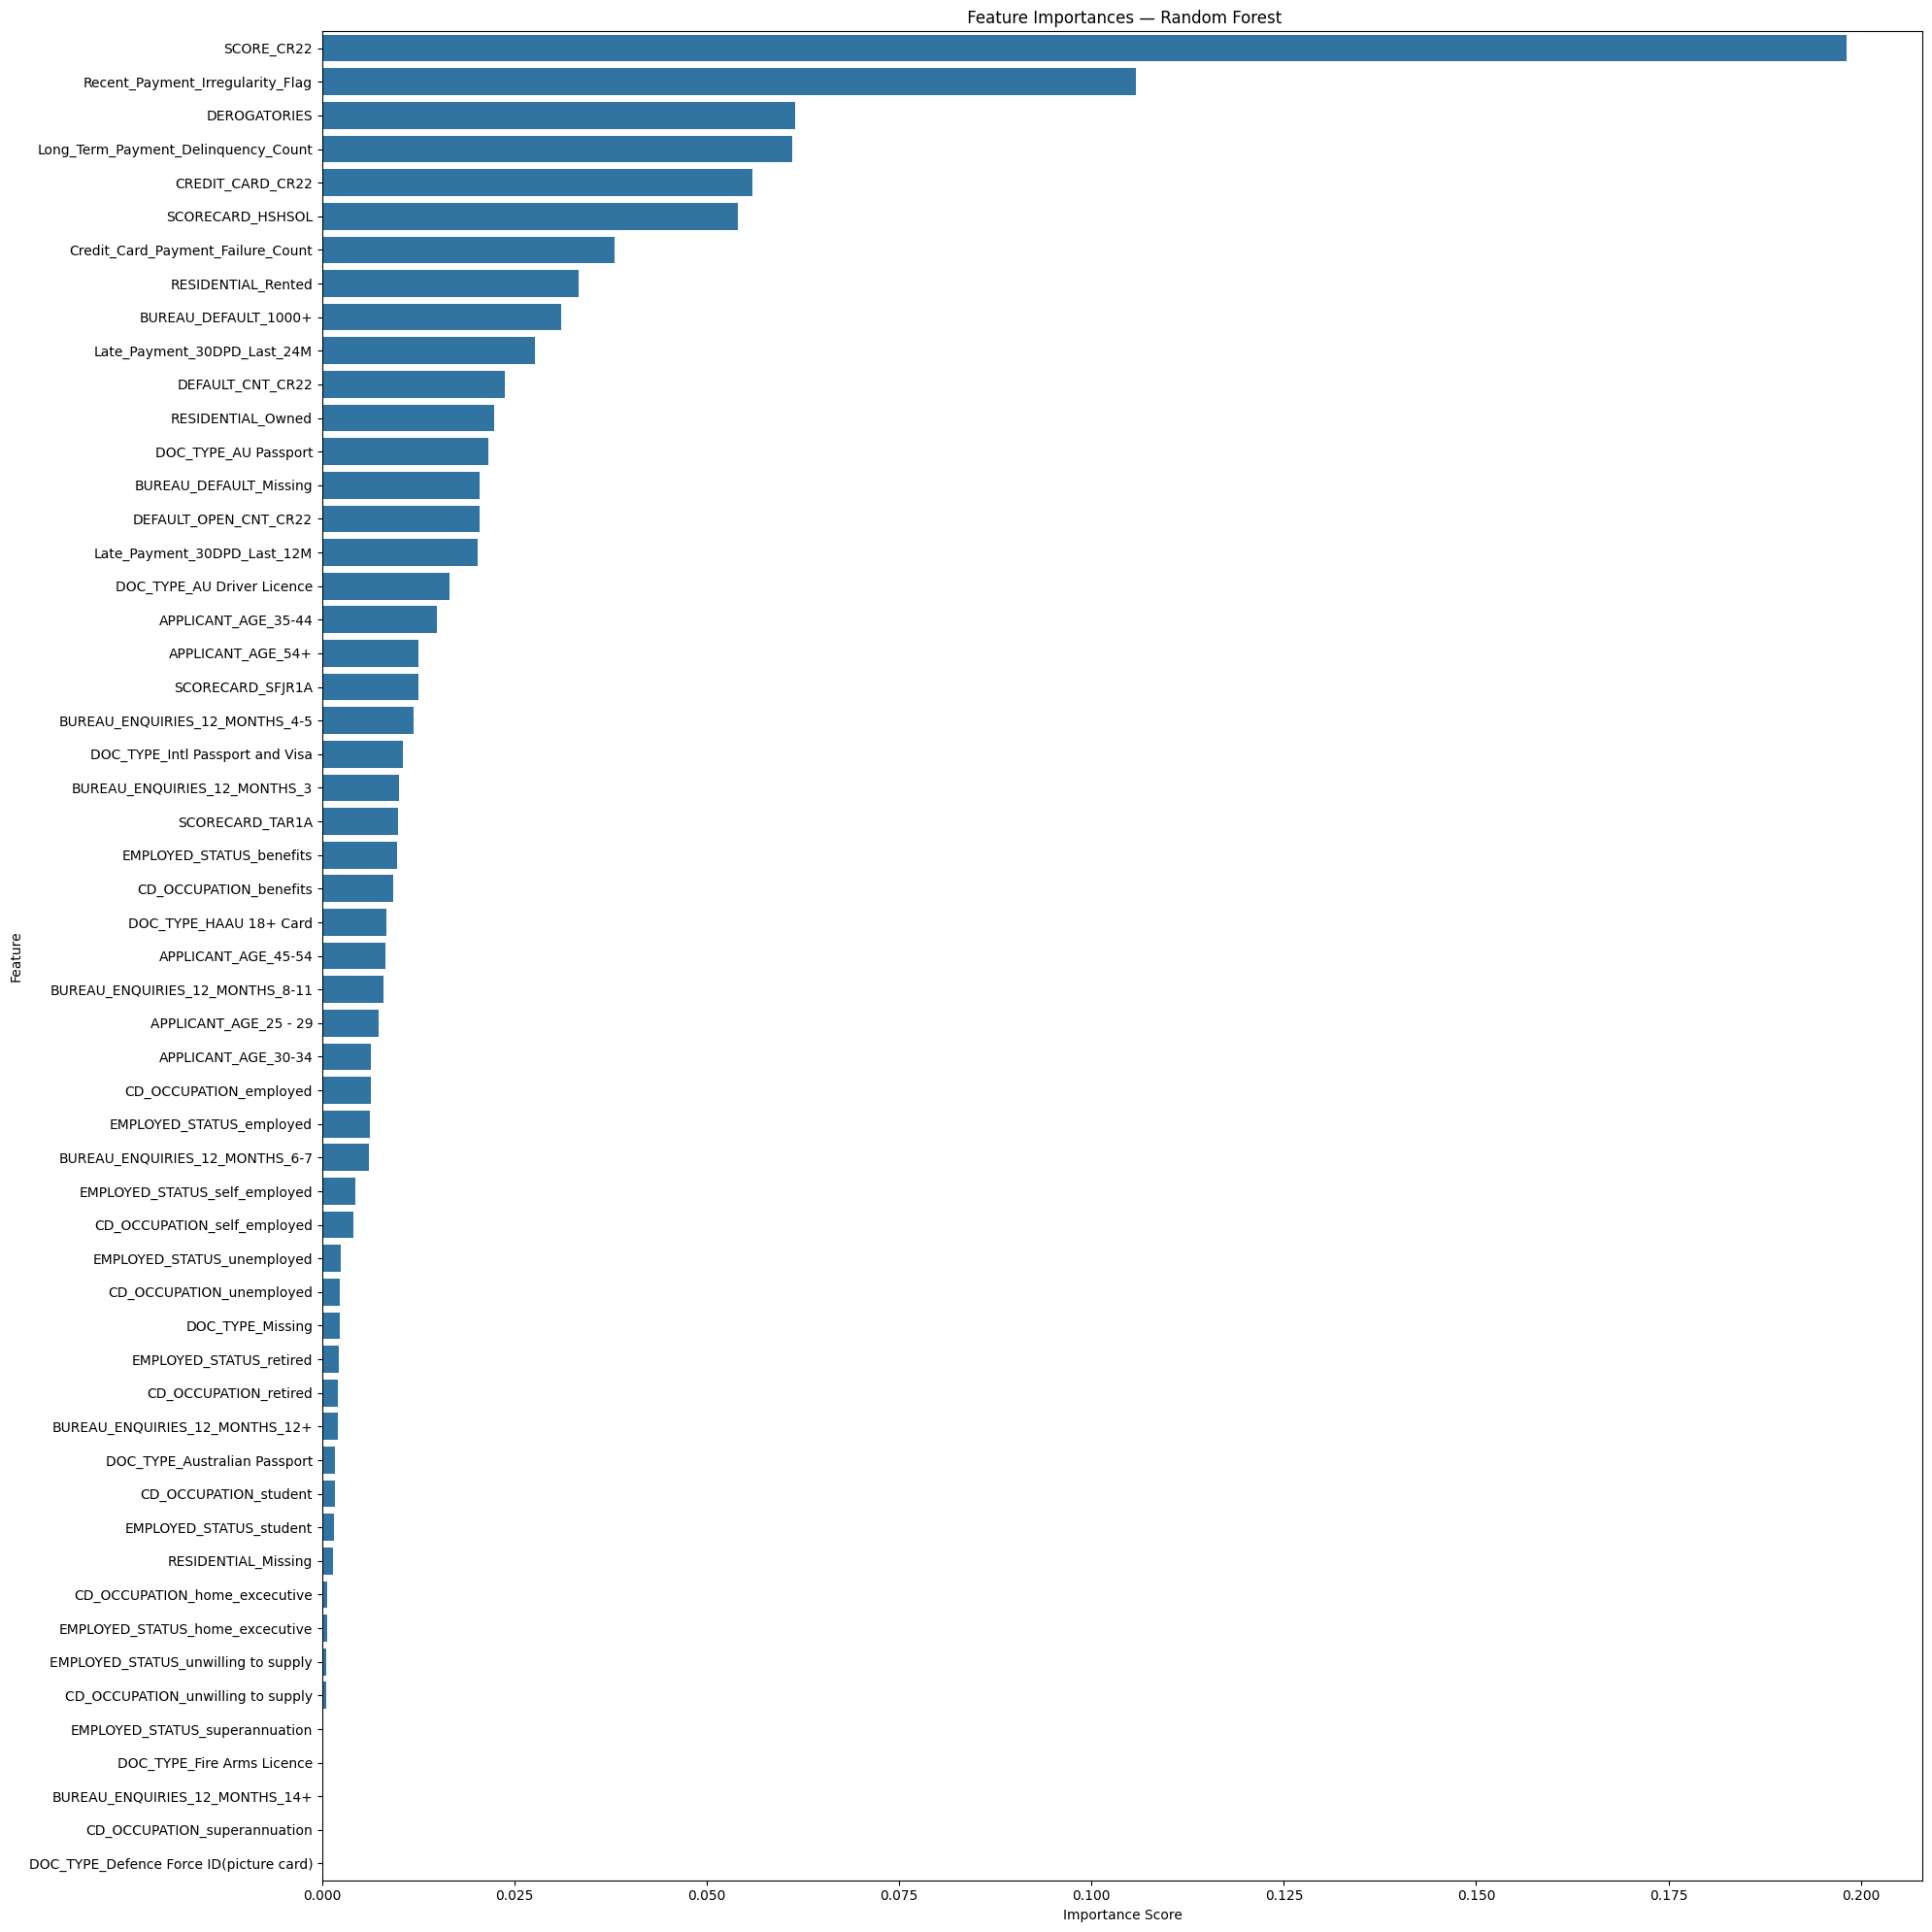

In [461]:


plt.figure(figsize=(20,20))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title(" Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


<div style="text-align:center;">
  <span style="color:Green; font-size:30px; font-weight:bold;">
   Model Evaluation
  </span>
</div>

In [462]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import auc
import matplotlib.pyplot as plt

# Probability for positive class (BAD = 1)
y_test_prob = rf_model_over.predict_proba(X_test_encoded)[:, 1]


In [463]:
train_probs = rf_model_over.predict_proba(X_train_st)[:,1]
test_probs  = rf_model_over.predict_proba(X_test_encoded)[:,1]


In [464]:
train_probs 

array([0.11286233, 0.44179998, 0.15960105, ..., 0.47709592, 0.73717179,
       0.45052646])

In [465]:
test_probs

array([0.22565972, 0.09947303, 0.06271837, ..., 0.14104803, 0.4668    ,
       0.32123938])

In [466]:
len(train_probs)

111500

In [467]:
df_csv = pd.DataFrame(train_probs)
df_csv.to_csv("train_probs.csv", index=False)

In [470]:
len(X_train_st)

111500

In [471]:
X_train_st.head()

,DEROGATORIES,SCORE_CR22,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Long_Term_Payment_Delinquency_Count,CREDIT_CARD_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,RESIDENTIAL_Missing,RESIDENTIAL_Owned,RESIDENTIAL_Rented,CD_OCCUPATION_benefits,CD_OCCUPATION_employed,CD_OCCUPATION_home_excecutive,CD_OCCUPATION_retired,CD_OCCUPATION_self_employed,CD_OCCUPATION_student,CD_OCCUPATION_superannuation,CD_OCCUPATION_unemployed,CD_OCCUPATION_unwilling to supply,DOC_TYPE_AU Driver Licence,DOC_TYPE_AU Passport,DOC_TYPE_Australian Passport,DOC_TYPE_Defence Force ID(picture card),DOC_TYPE_Fire Arms Licence,DOC_TYPE_HAAU 18+ Card,DOC_TYPE_Intl Passport and Visa,DOC_TYPE_Missing,EMPLOYED_STATUS_benefits,EMPLOYED_STATUS_employed,EMPLOYED_STATUS_home_excecutive,EMPLOYED_STATUS_retired,EMPLOYED_STATUS_self_employed,EMPLOYED_STATUS_student,EMPLOYED_STATUS_superannuation,EMPLOYED_STATUS_unemployed,EMPLOYED_STATUS_unwilling to supply,APPLICANT_AGE_25 - 29,APPLICANT_AGE_30-34,APPLICANT_AGE_35-44,APPLICANT_AGE_45-54,APPLICANT_AGE_54+,BUREAU_DEFAULT_1000+,BUREAU_DEFAULT_Missing,SCORECARD_HSHSOL,SCORECARD_SFJR1A,SCORECARD_TAR1A,BUREAU_ENQUIRIES_12_MONTHS_12+,BUREAU_ENQUIRIES_12_MONTHS_14+,BUREAU_ENQUIRIES_12_MONTHS_3,BUREAU_ENQUIRIES_12_MONTHS_4-5,BUREAU_ENQUIRIES_12_MONTHS_6-7,BUREAU_ENQUIRIES_12_MONTHS_8-11
0,-0.212,1.252,-0.164,0.750,1.253,-0.187,1.697,0.926,-0.191,-0.155,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False
1,-0.212,0.307,-0.164,-0.474,-0.888,-0.187,-0.632,-0.518,-0.191,-0.155,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False
2,-0.212,0.723,-0.164,0.750,1.253,-0.187,1.697,0.926,-0.191,-0.155,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
3,-0.212,1.748,-0.164,0.750,1.253,-0.187,1.697,0.926,-0.191,-0.155,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False
4,-0.212,-0.136,-0.164,-0.474,-0.888,-0.187,-0.632,-0.518,-0.191,-0.155,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False


In [472]:
len(test_probs)

20960

In [474]:
df_csv = pd.DataFrame(test_probs)
df_csv.to_csv("test_probs.csv", index=False)

In [164]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)


In [165]:
fpr, tpr, thresholds

(array([0.        , 0.00005175, 0.00005175, ..., 0.99958601, 0.99974125,
        1.        ]),
 array([0.        , 0.        , 0.00061125, ..., 1.        , 1.        ,
        1.        ]),
 array([       inf, 0.96040605, 0.9575899 , ..., 0.01586414, 0.0158626 ,
        0.01122908]))

In [166]:
tpr

array([0.        , 0.        , 0.00061125, ..., 1.        , 1.        ,
       1.        ])

In [149]:
thresholds

array([       inf, 0.96040605, 0.9575899 , ..., 0.01586414, 0.0158626 ,
       0.01122908])

In [150]:
area = auc(fpr, tpr)
area 

0.7400349888581234

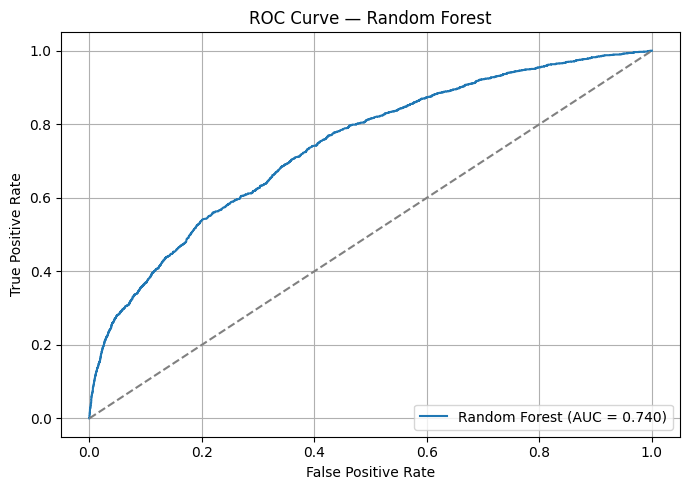

In [151]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

# Diagonal reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


### **Rank Ordering and KS statistics**


Reference : 

[https://towardsdatascience.com/kolmogorov-smirnov-statistic-explained-measuring-model-power-in-credit-risk-modeling/]

[https://medium.com/@kstarun/k-s-score-for-model-evaluation-5339f0a5c705]

Rank ordering means sorting customers from highest to lowest default risk based on the model’s score or probability, so risky borrowers appear at the top.

KS statistic measures the maximum separation between good and bad customers after rank ordering, showing how well the model distinguishes defaulters from non-defaulters.

| KS (%)       | Interpretation                |
| ------------ | ----------------------------- |
| **< 20%**    | Bad                           |
| **20 – 30%** | Acceptable                    |
| **30 – 40%** | **Good**                      |
| **> 40%**    | Very Good (check overfitting) |


In [152]:
scores = rf_model_over.predict_proba(X_test_encoded)[:, 1]
scores 

array([0.22565972, 0.09947303, 0.06271837, ..., 0.14104803, 0.4668    ,
       0.32123938])

In [153]:


# Probability of BAD = 1
scores = rf_model_over.predict_proba(X_test_encoded)[:, 1]

df = pd.DataFrame({
    "probability": scores,
    "actual": y_test.values   # 1 = Bad, 0 = Good
})

# Sort by risk (High → Low)
df = df.sort_values("probability", ascending=False).reset_index(drop=True)




- A **decile** divides data into **10 equal groups** after sorting by a score or value.

- In risk or ML models, customers are ranked by **predicted probability** and split into deciles from **lowest to highest risk**.

- Each decile contains roughly **10% of the population**.

- Deciles help evaluate whether the model **correctly orders risk** from safe to risky.

- They are widely used to define **business cut-offs** and explain model performance clearly.


In [ ]:
df["Decile"] = pd.qcut(
    df.index,
    10,
    labels=False
)

df["Decile"] = df["Decile"].max() - df["Decile"]


In [ ]:
df.head()

,probability,actual,Decile
0,0.960,0,9
1,0.958,1,9
2,0.957,0,9
3,0.954,1,9
4,0.945,1,9


In [ ]:
df.describe()

,probability,actual,Decile
count,20960.000,20960.000,20960.000
mean,0.385,0.078,4.500
std,0.185,0.268,2.872
min,0.011,0.000,0.000
25%,0.224,0.000,2.000
50%,0.420,0.000,4.500
75%,0.517,0.000,7.000
max,0.960,1.000,9.000


In [ ]:
decile_table = df.groupby("Decile").agg(
    Minimum_Probability=("probability", "min"),
    Maximum_Probability=("probability", "max"),
    Events=("actual", "sum"),
    Total=("actual", "count")
).reset_index()

decile_table["Non-events"] = decile_table["Total"] - decile_table["Events"]

# Rates
decile_table["Event Rate"] = (decile_table["Events"] / decile_table["Total"]) * 100
decile_table["Non-event Rate"] = (decile_table["Non-events"] / decile_table["Total"]) * 100


In [ ]:
decile_table["Cum Events"] = decile_table["Events"].cumsum()
decile_table["Cum Non-events"] = decile_table["Non-events"].cumsum()

decile_table["Cum Event Rate"] = (
    decile_table["Cum Events"] / decile_table["Events"].sum()
) * 100

decile_table["Cum Non-event Rate"] = (
    decile_table["Cum Non-events"] / decile_table["Non-events"].sum()
) * 100


In [ ]:
import pandas as pd
import numpy as np

scores = rf_model_over.predict_proba(X_test_encoded)[:, 1]  # P(Bad)

df = pd.DataFrame({
    "Probability": scores,
    "Bad": y_test.values
})

df["Good"] = 1 - df["Bad"]

# Sort by risk (High → Low)
df = df.sort_values("Probability", ascending=False).reset_index(drop=True)


In [ ]:
df["Decile"] = pd.qcut(df.index, 10, labels=False)
df["Decile"] = df["Decile"].max() - df["Decile"]


In [ ]:
decile_table = df.groupby("Decile").agg(
    Minimum_Probability=("Probability", "min"),
    Maximum_Probability=("Probability", "max"),
    Bad=("Bad", "sum"),
    Good=("Good", "sum")
).reset_index()

decile_table["Total"] = decile_table["Bad"] + decile_table["Good"]

# Rates
decile_table["Bad Rate"] = (decile_table["Bad"] / decile_table["Total"]) * 100
decile_table["Good Rate"] = (decile_table["Good"] / decile_table["Total"]) * 100


In [ ]:
decile_table["Cum Bad"] = decile_table["Bad"].cumsum()
decile_table["Cum Good"] = decile_table["Good"].cumsum()

decile_table["Cum Bad Rate"] = (
    decile_table["Cum Bad"] / decile_table["Bad"].sum()
) * 100

decile_table["Cum Good Rate"] = (
    decile_table["Cum Good"] / decile_table["Good"].sum()
) * 100


In [ ]:
decile_table["KS"] = abs(
    decile_table["Cum Bad Rate"] - decile_table["Cum Good Rate"]
)

ks_value = decile_table["KS"].max()
print("KS Statistic:", round(ks_value, 2), "%")


KS Statistic: 33.92 %


In [ ]:
final_table = decile_table[[
    "Decile",
    "Minimum_Probability",
    "Maximum_Probability",
    "Bad",
    "Good",
    "Bad Rate",
    "Good Rate",
    "Cum Bad",
    "Cum Good",
    "Cum Bad Rate",
    "Cum Good Rate",
    "KS"
]]

final_table

,Decile,Minimum_Probability,Maximum_Probability,Bad,Good,Bad Rate,Good Rate,Cum Bad,Cum Good,Cum Bad Rate,Cum Good Rate,KS
0,0,0.011,0.123,30,2066,1.431,98.569,30,2066,1.834,10.691,8.858
1,1,0.123,0.184,51,2045,2.433,97.567,81,4111,4.951,21.274,16.323
2,2,0.184,0.267,64,2032,3.053,96.947,145,6143,8.863,31.789,22.926
3,3,0.267,0.355,84,2012,4.008,95.992,229,8155,13.998,42.201,28.204
4,4,0.355,0.420,98,1998,4.676,95.324,327,10153,19.988,52.541,32.553
5,5,0.420,0.455,143,1953,6.823,93.177,470,12106,28.729,62.647,33.919
6,6,0.455,0.499,174,1922,8.302,91.698,644,14028,39.364,72.594,33.229
7,7,0.499,0.531,189,1907,9.017,90.983,833,15935,50.917,82.462,31.545
8,8,0.531,0.600,255,1841,12.166,87.834,1088,17776,66.504,91.989,25.486
9,9,0.600,0.960,548,1548,26.145,73.855,1636,19324,100.000,100.000,0.000


### **Gini Coefficient** 

Gini coefficient measures the overall discriminatory power of the model, indicating how much better it ranks bad customers ahead of good customers compared to random guessing.

| Gini            | Interpretation                 |
| --------------- | ------------------------------ |
| **< 0.20**      | Bad                            |
| **0.20 – 0.30** | Acceptable                     |
| **0.30 – 0.40** | Good                           |
| **0.40 – 0.50** | **Very Good**                  |
| **> 0.50**      | Excellent (validate stability) |


Reference: 

**[https://towardsdatascience.com/beyond-roc-auc-and-ks-gini-coefficient-explained-simply/]**

In [ ]:
area = roc_auc_score(y_test, scores)
gini_coefficient = 2 * area - 1

gini_coefficient = 2 * area - 1


df["cum_population"] = np.arange(1, len(df) + 1) / len(df)


print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.7400349888581234
Gini Coefficient: 0.4800699777162467


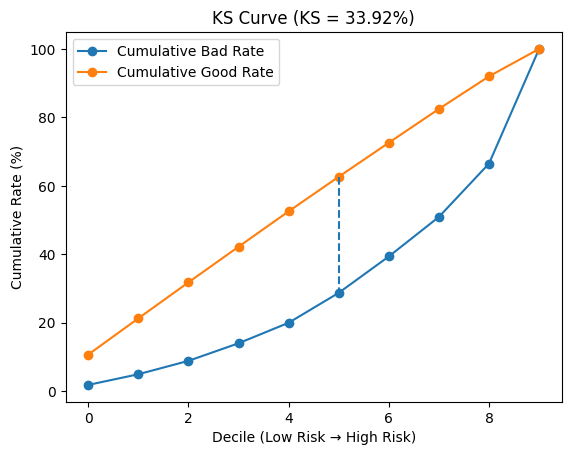

In [ ]:
plot_df = decile_table.sort_values("Decile")

# Find KS peak
ks_value = plot_df["KS"].max()
ks_decile = plot_df.loc[plot_df["KS"].idxmax(), "Decile"]
ks_bad_rate = plot_df.loc[plot_df["KS"].idxmax(), "Cum Bad Rate"]
ks_good_rate = plot_df.loc[plot_df["KS"].idxmax(), "Cum Good Rate"]

# Plot KS Curve
plt.figure()
plt.plot(plot_df["Decile"], plot_df["Cum Bad Rate"], marker='o', label="Cumulative Bad Rate")
plt.plot(plot_df["Decile"], plot_df["Cum Good Rate"], marker='o', label="Cumulative Good Rate")

# KS vertical line
plt.vlines(
    x=ks_decile,
    ymin=ks_good_rate,
    ymax=ks_bad_rate,
    linestyles="dashed"
)

# Labels & title
plt.xlabel("Decile (Low Risk → High Risk)")
plt.ylabel("Cumulative Rate (%)")
plt.title(f"KS Curve (KS = {ks_value:.2f}%)")
plt.legend()

plt.show()

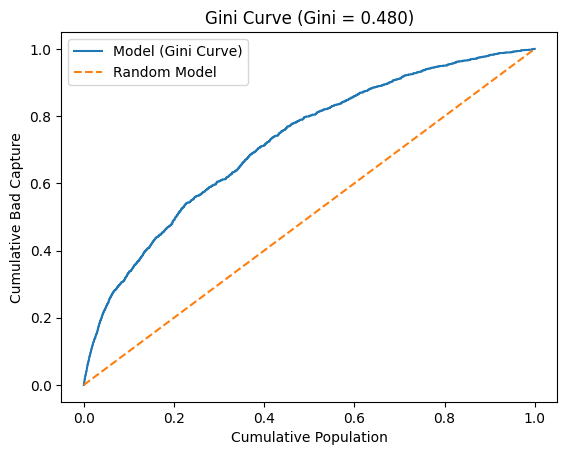

In [ ]:
# Create cumulative bad capture
df["cum_bad"] = df["Bad"].cumsum()
df["cum_bad_rate"] = df["cum_bad"] / df["Bad"].sum()

# Plot Gini (Lorenz) Curve
plt.figure()
plt.plot(
    df["cum_population"],
    df["cum_bad_rate"],
    label="Model (Gini Curve)"
)

# Random model baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="dashed",
    label="Random Model"
)

plt.xlabel("Cumulative Population")
plt.ylabel("Cumulative Bad Capture")
plt.title(f"Gini Curve (Gini = {gini_coefficient:.3f})")
plt.legend()
plt.show()



<div style="text-align:center;">
  <span style="color:Green; font-size:30px; font-weight:bold;">
    Saving Model
  </span>
</div>

In [154]:
final_model = rf_model_over

In [ ]:
X_test_encoded.head()

,DEROGATORIES,SCORE_CR22,Late_Payment_30DPD_Last_12M,Credit_Card_Payment_Failure_Count,Recent_Payment_Irregularity_Flag,Late_Payment_30DPD_Last_24M,Long_Term_Payment_Delinquency_Count,CREDIT_CARD_CR22,DEFAULT_CNT_CR22,DEFAULT_OPEN_CNT_CR22,RESIDENTIAL_Missing,RESIDENTIAL_Owned,RESIDENTIAL_Rented,CD_OCCUPATION_benefits,CD_OCCUPATION_employed,CD_OCCUPATION_home_excecutive,CD_OCCUPATION_retired,CD_OCCUPATION_self_employed,CD_OCCUPATION_student,CD_OCCUPATION_superannuation,CD_OCCUPATION_unemployed,CD_OCCUPATION_unwilling to supply,DOC_TYPE_AU Driver Licence,DOC_TYPE_AU Passport,DOC_TYPE_Australian Passport,DOC_TYPE_Defence Force ID(picture card),DOC_TYPE_Fire Arms Licence,DOC_TYPE_HAAU 18+ Card,DOC_TYPE_Intl Passport and Visa,DOC_TYPE_Missing,EMPLOYED_STATUS_benefits,EMPLOYED_STATUS_employed,EMPLOYED_STATUS_home_excecutive,EMPLOYED_STATUS_retired,EMPLOYED_STATUS_self_employed,EMPLOYED_STATUS_student,EMPLOYED_STATUS_superannuation,EMPLOYED_STATUS_unemployed,EMPLOYED_STATUS_unwilling to supply,APPLICANT_AGE_25 - 29,APPLICANT_AGE_30-34,APPLICANT_AGE_35-44,APPLICANT_AGE_45-54,APPLICANT_AGE_54+,BUREAU_DEFAULT_1000+,BUREAU_DEFAULT_Missing,SCORECARD_HSHSOL,SCORECARD_SFJR1A,SCORECARD_TAR1A,BUREAU_ENQUIRIES_12_MONTHS_12+,BUREAU_ENQUIRIES_12_MONTHS_14+,BUREAU_ENQUIRIES_12_MONTHS_3,BUREAU_ENQUIRIES_12_MONTHS_4-5,BUREAU_ENQUIRIES_12_MONTHS_6-7,BUREAU_ENQUIRIES_12_MONTHS_8-11
90333,-0.212,1.332,-0.164,-0.474,0.718,-0.187,-0.632,-0.518,-0.191,-0.155,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False
45438,-0.212,1.988,-0.164,0.750,1.253,-0.187,1.697,0.926,-0.191,-0.155,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False
55978,-0.212,1.663,-0.164,0.750,1.253,-0.187,1.697,0.926,-0.191,-0.155,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,True,False
13304,-0.212,0.013,-0.164,-0.474,-0.174,-0.187,-0.632,-0.518,-0.191,-0.155,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False
61402,-0.212,-0.515,-0.164,-0.474,-0.888,-0.187,-0.632,-0.518,-0.191,-0.155,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False


In [ ]:
X_test_encoded.columns

Index(['DEROGATORIES', 'SCORE_CR22', 'Late_Payment_30DPD_Last_12M',
       'Credit_Card_Payment_Failure_Count', 'Recent_Payment_Irregularity_Flag',
       'Late_Payment_30DPD_Last_24M', 'Long_Term_Payment_Delinquency_Count',
       'CREDIT_CARD_CR22', 'DEFAULT_CNT_CR22', 'DEFAULT_OPEN_CNT_CR22',
       'RESIDENTIAL_Missing', 'RESIDENTIAL_Owned', 'RESIDENTIAL_Rented',
       'CD_OCCUPATION_benefits', 'CD_OCCUPATION_employed',
       'CD_OCCUPATION_home_excecutive', 'CD_OCCUPATION_retired',
       'CD_OCCUPATION_self_employed', 'CD_OCCUPATION_student',
       'CD_OCCUPATION_superannuation', 'CD_OCCUPATION_unemployed',
       'CD_OCCUPATION_unwilling to supply', 'DOC_TYPE_AU Driver Licence',
       'DOC_TYPE_AU Passport', 'DOC_TYPE_Australian Passport',
       'DOC_TYPE_Defence Force ID(picture card)', 'DOC_TYPE_Fire Arms Licence',
       'DOC_TYPE_HAAU 18+ Card', 'DOC_TYPE_Intl Passport and Visa',
       'DOC_TYPE_Missing', 'EMPLOYED_STATUS_benefits',
       'EMPLOYED_STATUS_employed', '

In [ ]:
remove = ['HAD_SERVICES', 'RISK_SCORE', 'DEFAULT_AMT', 'RISK_RELATIVE_CR21', 'Cumulative_Delinquency_Exposure', 'ENQUIRY_CNT_CR22', 'ENQUIRY_CNT_1M_CR22', 'ENQUIRY_CNT_3M_CR22', 'ENQUIRY_CNT_6M_CR22', 'ENQUIRY_CNT_12M_CR22', 'ENQUIRY_MAX_AMT_1M', 'ENQUIRY_MAX_AMT_3M', 'ENQUIRY_MAX_AMT_6M', 'ENQUIRY_MAX_AMT_12M', 'OPEN_ACCT_CR22', 'CLOSED_ACCT_CR22', 'TELCO_CR22', 'UTILITIES_CR22', 'OVERDRAFT_CR22', 'PERSONAL_LOAN_CR22', 'AUTO_LOAN_CR22', 'OVERDRAFT_AMT_CR22', 'PERSONAL_LOAN_AMT_CR22', 'AUTO_LOAN_AMT_CR22', 'DEFAULT_CNT_3M_CR22', 'DEFAULT_CNT_6M_CR22', 'DEFAULT_CNT_12M_CR22', 'DEFAULT_UNPAID_AMT_CR22', 'LIFE_INSTABILITY_FLAG']

In [ ]:
columns = [
    'HAD_SERVICES',
    'RISK_SCORE',
    'DEFAULT_AMT',
    'RISK_RELATIVE_CR21',
    'Cumulative_Delinquency_Exposure',
    'ENQUIRY_CNT_CR22',
    'ENQUIRY_CNT_1M_CR22',
    'ENQUIRY_CNT_3M_CR22',
    'ENQUIRY_CNT_6M_CR22',
    'ENQUIRY_CNT_12M_CR22',
    'ENQUIRY_MAX_AMT_1M',
    'ENQUIRY_MAX_AMT_3M',
    'ENQUIRY_MAX_AMT_6M',
    'ENQUIRY_MAX_AMT_12M',   
    'OPEN_ACCT_CR22',
    'CLOSED_ACCT_CR22',
    'TELCO_CR22',
    'UTILITIES_CR22',  
    'OVERDRAFT_CR22', 
    'PERSONAL_LOAN_CR22',
    'AUTO_LOAN_CR22',
    'OVERDRAFT_AMT_CR22',
    'PERSONAL_LOAN_AMT_CR22',
    'AUTO_LOAN_AMT_CR22',
    'DEFAULT_CNT_3M_CR22',
    'DEFAULT_CNT_6M_CR22',
    'DEFAULT_CNT_12M_CR22',
    'DEFAULT_UNPAID_AMT_CR22',
    'LIFE_INSTABILITY_FLAG'
]





In [ ]:
cols_to_scale = [c for c in cols_to_scale if c not in columns]
cols_to_scale

['DEROGATORIES',
 'SCORE_CR22',
 'Late_Payment_30DPD_Last_12M',
 'Credit_Card_Payment_Failure_Count',
 'Recent_Payment_Irregularity_Flag',
 'Late_Payment_30DPD_Last_24M',
 'Long_Term_Payment_Delinquency_Count',
 'CREDIT_CARD_CR22',
 'DEFAULT_CNT_CR22',
 'DEFAULT_OPEN_CNT_CR22']

In [ ]:
X_train_encoded.columns

Index(['DEROGATORIES', 'SCORE_CR22', 'Late_Payment_30DPD_Last_12M',
       'Credit_Card_Payment_Failure_Count', 'Recent_Payment_Irregularity_Flag',
       'Late_Payment_30DPD_Last_24M', 'Long_Term_Payment_Delinquency_Count',
       'CREDIT_CARD_CR22', 'DEFAULT_CNT_CR22', 'DEFAULT_OPEN_CNT_CR22',
       'RESIDENTIAL_Missing', 'RESIDENTIAL_Owned', 'RESIDENTIAL_Rented',
       'CD_OCCUPATION_benefits', 'CD_OCCUPATION_employed',
       'CD_OCCUPATION_home_excecutive', 'CD_OCCUPATION_retired',
       'CD_OCCUPATION_self_employed', 'CD_OCCUPATION_student',
       'CD_OCCUPATION_superannuation', 'CD_OCCUPATION_unemployed',
       'CD_OCCUPATION_unwilling to supply', 'DOC_TYPE_AU Driver Licence',
       'DOC_TYPE_AU Passport', 'DOC_TYPE_Australian Passport',
       'DOC_TYPE_Defence Force ID(picture card)', 'DOC_TYPE_Fire Arms Licence',
       'DOC_TYPE_HAAU 18+ Card', 'DOC_TYPE_Intl Passport and Visa',
       'DOC_TYPE_Missing', 'EMPLOYED_STATUS_benefits',
       'EMPLOYED_STATUS_employed', '

In [ ]:
import os
from joblib import dump

In [ ]:
# Create folder if it doesn't exist
os.makedirs('sreevarshan', exist_ok=True)

model_data_final = {
    'model': final_model,
    'features': X_train_encoded.columns,
    'scaler': scaler,
    'cols_to_scale': cols_to_scale,
}

# Now dump safely
dump(model_data_final, 'sreevarshan/model_data_final.joblib')

['sreevarshan/model_data_final.joblib']